In [1]:
# Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
# Load the CSV file into a pandas dataframe
df_raw=pd.read_csv(r"C:\Users\DELL\OneDrive\Documents\AshmaGurung_ DataScience\Final Project\diabetes_risk.csv")

In [3]:
df_raw.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [4]:
df_raw.tail()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
14995,14996,47,Male,Mumbai,37.7,No,Sedentary,Non-Vegetarian,Never,Never,6.8,7,213,8.1,150,100,141.7,High,High
14996,14997,48,Female,Mumbai,20.6,No,Moderate,Non-Vegetarian,Never,NaN,6.0,8,162,6.5,132,80,91.0,NaN,Low
14997,14998,34,Female,Nagpur,17.9,No,Active,Vegetarian,Never,Never,7.0,6,137,6.5,136,90,88.8,Low,Low
14998,14999,56,Male,Ahmedabad,20.7,Yes,Active,Vegetarian,Never,Never,6.0,5,163,6.9,140,87,94.8,Low,Low
14999,15000,54,Male,Surat,34.5,No,Moderate,Vegetarian,Never,Never,7.4,2,186,7.2,150,88,130.4,Middle,Moderate


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [6]:
# Check the shape of the data
# This tells us how many rows and columns we have
print("Number of rows   :", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])

Number of rows   : 15000
Number of columns: 19


In [7]:
df_raw.shape

(15000, 19)

In [8]:
# Count how many missing values are in each column
missing_count = df_raw.isnull().sum()

# Calculate the percentage of missing values in each column
length_of_missing_count= len(df_raw)
missing_percent = (missing_count / length_of_missing_count) * 100

# Combine both into one table for easy viewing
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent (%)": missing_percent.round(2)
})

# Sort by missing percentage from highest to lowest
missing_summary = missing_summary.sort_values("Missing Percent (%)", ascending=False)

# Show only columns that have at least 1 missing value
missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing Percent (%)
alcohol_consumption,3788,25.25
smoking_status,472,3.15
income_bracket,463,3.09


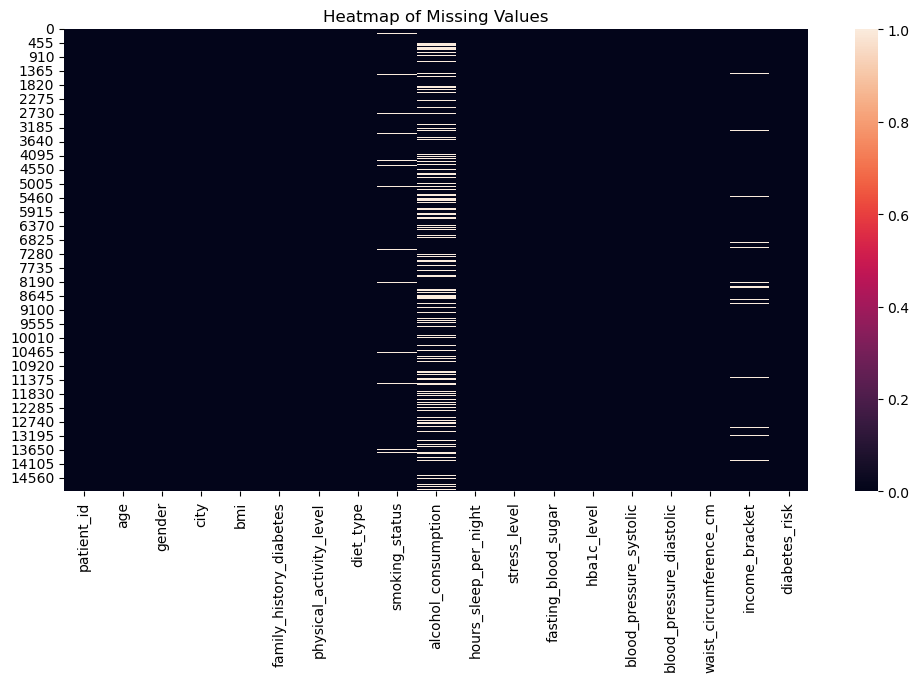

In [9]:
# heatmap of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df_raw.isnull())
plt.title("Heatmap of Missing Values")
plt.show()

In [10]:
# Now lets make a copy of the original dataframe
# We will clean the new dataframe df_clean and keep the original dataframe df_raw untouched
df_clean = df_raw.copy()

print("Original dataframe shape :", df_raw.shape)
print("Copy dataframe shape      :", df_clean.shape)
print()
print("These should be equal. We are working on df_clean now.")

Original dataframe shape : (15000, 19)
Copy dataframe shape      : (15000, 19)

These should be equal. We are working on df_clean now.


We can remove Columns with more than 80% missing values as they are not useful. Since all the columns with missing values do not exceed 80% we will not drop them from the dataset.

In [11]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [12]:
df_clean.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [13]:
missing_count_clean = df_clean.isnull().sum()

# Calculate the percentage of missing values in each column
missing_percent_clean = (missing_count_clean / len(df_clean)) * 100
missing_percent_clean

patient_id                   0.000000
age                          0.000000
gender                       0.000000
city                         0.000000
bmi                          0.000000
family_history_diabetes      0.000000
physical_activity_level      0.000000
diet_type                    0.000000
smoking_status               3.146667
alcohol_consumption         25.253333
hours_sleep_per_night        0.000000
stress_level                 0.000000
fasting_blood_sugar          0.000000
hba1c_level                  0.000000
blood_pressure_systolic      0.000000
blood_pressure_diastolic     0.000000
waist_circumference_cm       0.000000
income_bracket               3.086667
diabetes_risk                0.000000
dtype: float64

Fill with Mode

Use mode for text or category columns. Mode means the most common value in that column.
Here columns: smoking_status and income_bracket have small missing values. 
Filling with the most common value keeps the data balanced. 

In [14]:
# Fill smoking_status with mode
print("Missing in smoking_status before:", df_clean["smoking_status"].isnull().sum())

# mode() returns a series, we take the first value [0]
mode_smoking_status = df_clean["smoking_status"].mode()[0]
print("Most common smoking status:", mode_smoking_status)

df_clean["smoking_status"] = df_clean["smoking_status"].fillna(mode_smoking_status)

print("Missing in smoking_status after :", df_clean["smoking_status"].isnull().sum())

Missing in smoking_status before: 472
Most common smoking status: Never
Missing in smoking_status after : 0


In [15]:
# Fill income_bracket with mode
print("Missing in income_bracket before:", df_clean["income_bracket"].isnull().sum())

# mode() returns a series, we take the first value [0]
mode_income_bracket = df_clean["income_bracket"].mode()[0]
print("Most common income bracket:", mode_income_bracket)

df_clean["income_bracket"] = df_clean["income_bracket"].fillna(mode_smoking_status)

print("Missing in income_bracket after :", df_clean["income_bracket"].isnull().sum())

Missing in income_bracket before: 463
Most common income bracket: Middle
Missing in income_bracket after : 0


For alcohol_consumption, the missing values are 25%. Filling in with a guess(mode), is not suitable as it can distort the results. Instead, treat missing values as their own category as "Unknown".

In [16]:
#Fill alcohol_consumption with "Unknown"
print("Missing in alcohol_consumption before:", df_clean["alcohol_consumption"].isnull().sum())

df_clean['alcohol_consumption'] = df_clean['alcohol_consumption'].fillna('Unknown')

print("Missing in alcohol_consumption after :", df_clean["alcohol_consumption"].isnull().sum())

Missing in alcohol_consumption before: 3788
Missing in alcohol_consumption after : 0


In [17]:
# Check if there are any missing values left
total_missing = df_clean.isnull().sum()
print("Total missing values remaining in df_clean:", total_missing)

Total missing values remaining in df_clean: patient_id                  0
age                         0
gender                      0
city                        0
bmi                         0
family_history_diabetes     0
physical_activity_level     0
diet_type                   0
smoking_status              0
alcohol_consumption         0
hours_sleep_per_night       0
stress_level                0
fasting_blood_sugar         0
hba1c_level                 0
blood_pressure_systolic     0
blood_pressure_diastolic    0
waist_circumference_cm      0
income_bracket              0
diabetes_risk               0
dtype: int64


In [18]:
# Compare original and cleaned dataframe
print("Original data shape :", df_raw.shape)
print("Cleaned data shape  :", df_clean.shape)
print()
print("Original missing values total :", df_raw.isnull().sum().sum())
print("Cleaned missing values total  :", df_clean.isnull().sum().sum())

Original data shape : (15000, 19)
Cleaned data shape  : (15000, 19)

Original missing values total : 4723
Cleaned missing values total  : 0


In [19]:
# Save the cleaned dataframe to a new CSV file
df_clean.to_csv("diabetes_cleaned.csv", index=False)

print("Cleaned data saved as: diabetes_cleaned.csv")
print("Shape of saved file  :", df_clean.shape)

Cleaned data saved as: diabetes_cleaned.csv
Shape of saved file  : (15000, 19)


In [2]:
df=pd.read_csv(r"C:\Users\DELL\OneDrive\Documents\AshmaGurung_ DataScience\Final Project\diabetes_cleaned.csv")

In [21]:
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [22]:
df.tail()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
14995,14996,47,Male,Mumbai,37.7,No,Sedentary,Non-Vegetarian,Never,Never,6.8,7,213,8.1,150,100,141.7,High,High
14996,14997,48,Female,Mumbai,20.6,No,Moderate,Non-Vegetarian,Never,Unknown,6.0,8,162,6.5,132,80,91.0,Never,Low
14997,14998,34,Female,Nagpur,17.9,No,Active,Vegetarian,Never,Never,7.0,6,137,6.5,136,90,88.8,Low,Low
14998,14999,56,Male,Ahmedabad,20.7,Yes,Active,Vegetarian,Never,Never,6.0,5,163,6.9,140,87,94.8,Low,Low
14999,15000,54,Male,Surat,34.5,No,Moderate,Vegetarian,Never,Never,7.4,2,186,7.2,150,88,130.4,Middle,Moderate


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [42]:
df["patient_id"].value_counts().sort_index()

patient_id
1        1
2        1
3        1
4        1
5        1
        ..
14996    1
14997    1
14998    1
14999    1
15000    1
Name: count, Length: 15000, dtype: int64

In [41]:
df["age"].value_counts().sort_index()

age
18    234
19     40
20     55
21     68
22     72
23     92
24     94
25    116
26    137
27    122
28    142
29    192
30    203
31    235
32    276
33    235
34    294
35    340
36    366
37    390
38    359
39    465
40    461
41    473
42    507
43    563
44    571
45    588
46    599
47    626
48    595
49    547
50    564
51    485
52    499
53    478
54    460
55    401
56    346
57    334
58    283
59    229
60    197
61    157
62    120
63    108
64     72
65     70
66     50
67     33
68     20
69      8
70     10
71      9
72      4
73      3
75      2
80      1
Name: count, dtype: int64

In [40]:
df["gender"].value_counts().sort_index()

gender
Female    7183
Male      7664
Other      153
Name: count, dtype: int64

In [39]:
df["city"].value_counts().sort_index()

city
Ahmedabad        1039
Bengaluru        1535
Bhopal            399
Chennai           933
Delhi            1737
Hyderabad        1227
Indore            458
Jaipur            627
Kanpur            475
Kolkata           872
Lucknow           457
Mumbai           2243
Nagpur            462
Patna             288
Pune              756
Surat             734
Thane             451
Visakhapatnam     307
Name: count, dtype: int64

In [38]:
df["bmi"].value_counts().sort_index()

bmi
15.0    127
15.1     11
15.2     14
15.3     26
15.4     26
       ... 
39.2      1
39.6      1
39.8      1
40.0      1
40.8      1
Name: count, Length: 239, dtype: int64

In [37]:
df["family_history_diabetes"].value_counts().sort_index()

family_history_diabetes
No     9756
Yes    5244
Name: count, dtype: int64

In [36]:
df["physical_activity_level"].value_counts().sort_index()

physical_activity_level
Active       5100
Moderate     4950
Sedentary    4950
Name: count, dtype: int64

In [35]:
df["diet_type"].value_counts().sort_index()

diet_type
Non-Vegetarian    8195
Pescatarian        445
Vegan              286
Vegetarian        6074
Name: count, dtype: int64

In [34]:
df["smoking_status"].value_counts().sort_index()

smoking_status
Current     2946
Former      1463
Never      10591
Name: count, dtype: int64

In [33]:
df["alcohol_consumption"].value_counts().sort_index()

alcohol_consumption
Never         5616
Occasional    4483
Regular       1113
Unknown       3788
Name: count, dtype: int64

In [32]:
df["hours_sleep_per_night"].value_counts().sort_index()

hours_sleep_per_night
3.0      2
3.3      1
4.0     52
4.1      1
4.2      2
        ..
10.6     1
10.7     1
10.8     1
11.0    16
12.0     1
Name: count, Length: 73, dtype: int64

In [31]:
df["stress_level"].value_counts().sort_index()

stress_level
1      351
2      534
3     1120
4     1802
5     2454
6     2665
7     2445
8     1725
9     1084
10     820
Name: count, dtype: int64

In [30]:
df["fasting_blood_sugar"].value_counts().sort_index()

fasting_blood_sugar
72     1
76     3
78     1
79     1
80     3
      ..
372    1
374    1
395    1
398    1
400    6
Name: count, Length: 273, dtype: int64

In [29]:
df["hba1c_level"].value_counts().sort_index()

hba1c_level
4.8      1
4.9      2
5.0      8
5.1     28
5.2     56
        ..
11.8     1
12.0     1
12.1     2
12.4     1
13.4     1
Name: count, Length: 71, dtype: int64

In [28]:
df["blood_pressure_systolic"].value_counts().sort_index()

blood_pressure_systolic
80      1
90      1
94      1
96      1
98      2
       ..
180    15
182     1
184     1
190     1
200     1
Name: count, Length: 89, dtype: int64

In [27]:
df["blood_pressure_diastolic"].value_counts().sort_index()

blood_pressure_diastolic
50        1
58        1
59        1
60       44
61        3
62        5
63        2
64       14
65        6
66       15
67        7
68       80
69        6
70      548
71       24
72      176
73       41
74      118
75       54
76      352
77       86
78      217
79       93
80     3499
81      130
82      318
83      148
84      820
85      147
86      368
87      171
88      763
89      160
90     3171
91      126
92      612
93       92
94      246
95       81
96      415
97       71
98      132
99       36
100    1290
101      18
102      53
103      12
104      74
105      11
106      27
107       4
108      20
109       6
110      75
111       3
112       2
113       1
120       4
Name: count, dtype: int64

In [26]:
df["waist_circumference_cm"].value_counts().sort_index()

waist_circumference_cm
73.2     1
73.8     1
74.3     1
74.4     2
74.8     3
        ..
143.1    1
145.4    1
146.8    1
147.4    1
148.2    1
Name: count, Length: 614, dtype: int64

In [25]:
df["income_bracket"].value_counts().sort_index()

income_bracket
High      3844
Low       3388
Middle    7305
Never      463
Name: count, dtype: int64

In [24]:
df["diabetes_risk"].value_counts().sort_index()

diabetes_risk
High        2250
Low         9000
Moderate    3750
Name: count, dtype: int64

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

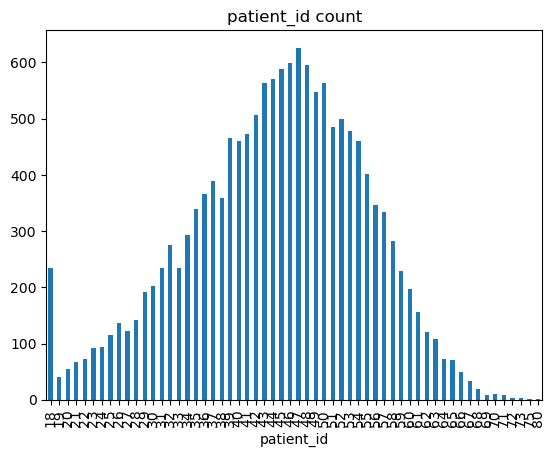

In [65]:
patient_id_count=df["patient_id"].value_counts().sort_index()
age_count.plot(kind="bar")
plt.title("patient_id count")
plt.xlabel("patient_id")
plt.show()

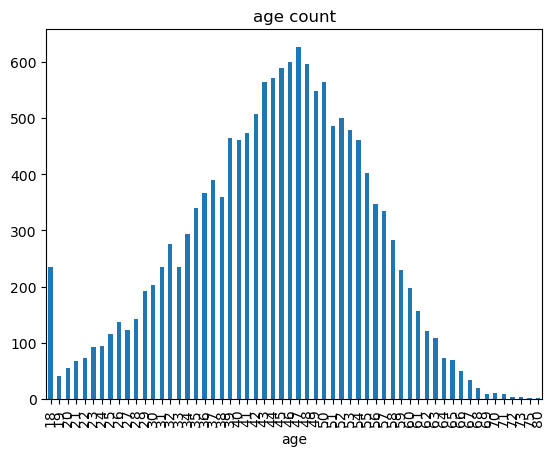

In [61]:
age_count=df["age"].value_counts().sort_index()
age_count.plot(kind="bar")
plt.title("age count")
plt.xlabel("age")
plt.show()

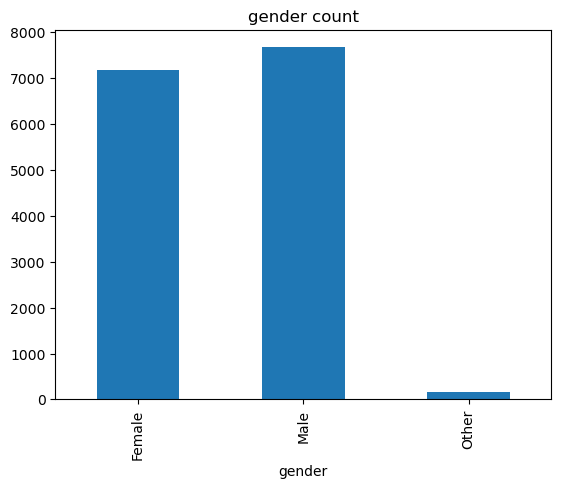

In [62]:
gender_count=df["gender"].value_counts().sort_index()
gender_count.plot(kind="bar")
plt.title("gender count")
plt.xlabel("gender")
plt.show()

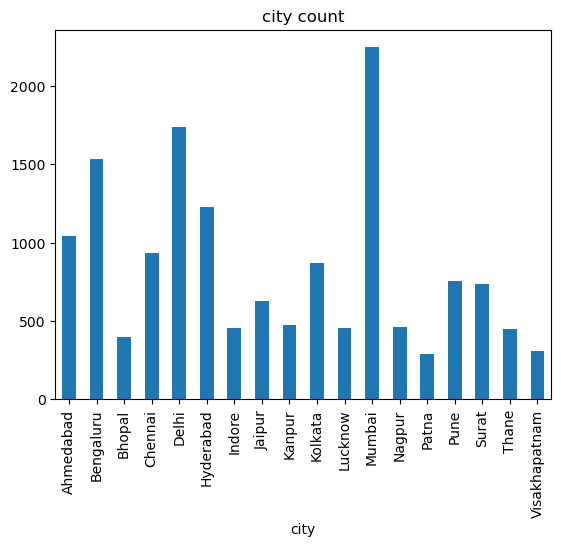

In [63]:
city_count=df["city"].value_counts().sort_index()
city_count.plot(kind="bar")
plt.title("city count")
plt.xlabel("city")
plt.show()

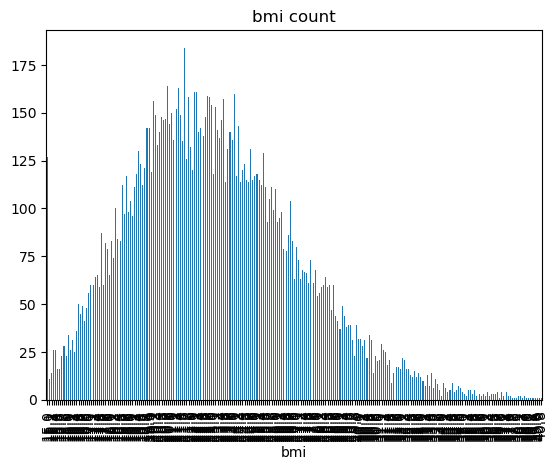

In [64]:
bmi_count=df["bmi"].value_counts().sort_index()
bmi_count.plot(kind="bar")
plt.title("bmi count")
plt.xlabel("bmi")
plt.show()

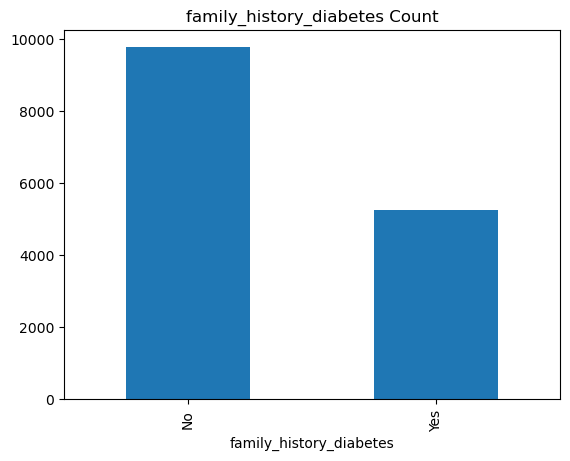

In [57]:
family_history_diabetes_count=df["family_history_diabetes"].value_counts().sort_index()
family_history_diabetes_count.plot(kind="bar")
plt.title("family_history_diabetes Count")
plt.xlabel("family_history_diabetes")
plt.show()

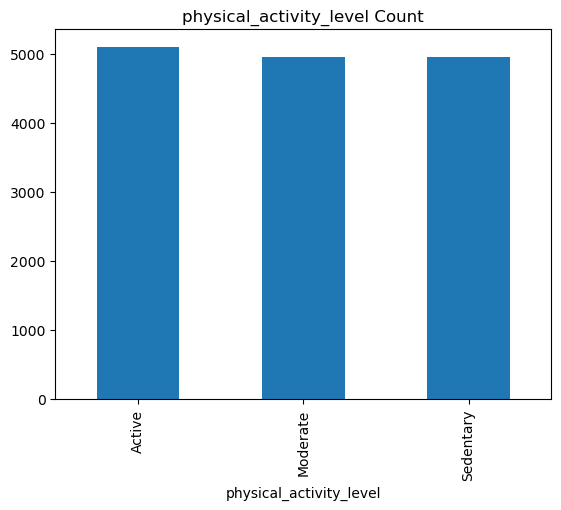

In [56]:
physical_activity_level_count=df["physical_activity_level"].value_counts().sort_index()
physical_activity_level_count.plot(kind="bar")
plt.title("physical_activity_level Count")
plt.xlabel("physical_activity_level")
plt.show()

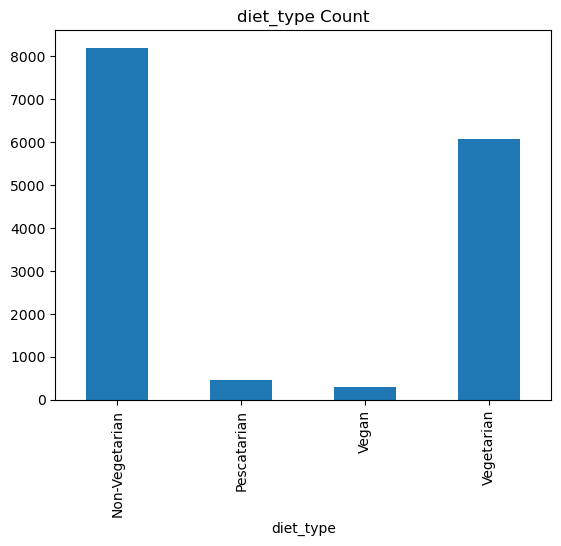

In [55]:
diet_type_count=df["diet_type"].value_counts().sort_index()
diet_type_count.plot(kind="bar")
plt.title("diet_type Count")
plt.xlabel("diet_type")
plt.show()

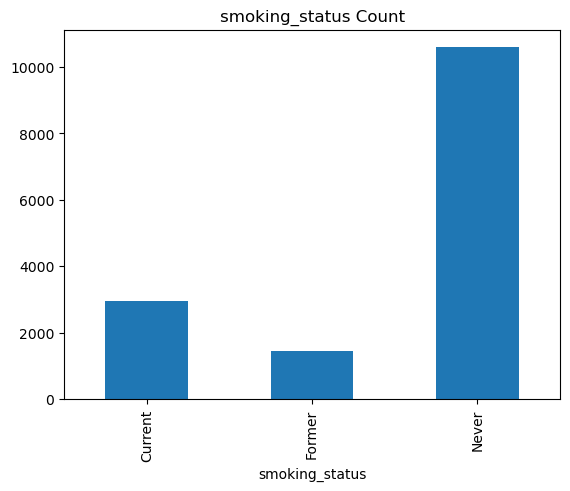

In [54]:
smoking_status_count=df["smoking_status"].value_counts().sort_index()
smoking_status_count.plot(kind="bar")
plt.title("smoking_status Count")
plt.xlabel("smoking_status")
plt.show()

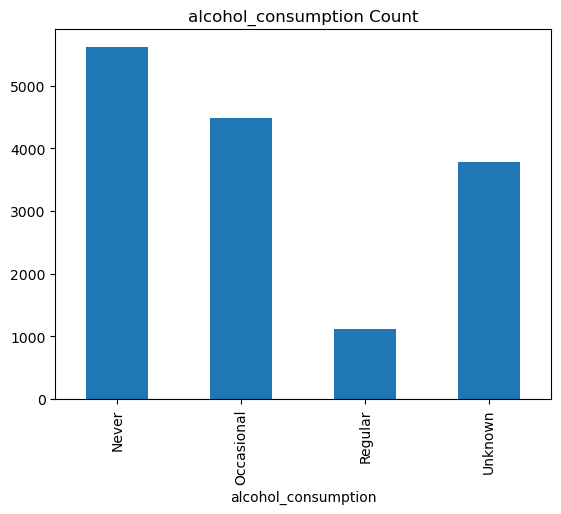

In [53]:
alcohol_consumption_count=df["alcohol_consumption"].value_counts().sort_index()
alcohol_consumption_count.plot(kind="bar")
plt.title("alcohol_consumption Count")
plt.xlabel("alcohol_consumption")
plt.show()

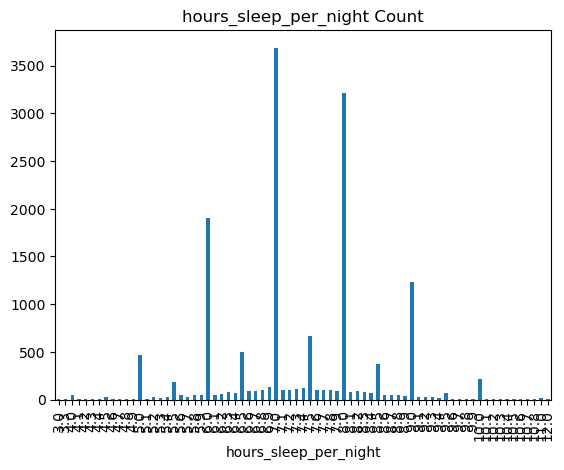

In [52]:
hours_sleep_per_night_count=df["hours_sleep_per_night"].value_counts().sort_index()
hours_sleep_per_night_count.plot(kind="bar")
plt.title("hours_sleep_per_night Count")
plt.xlabel("hours_sleep_per_night")
plt.show()

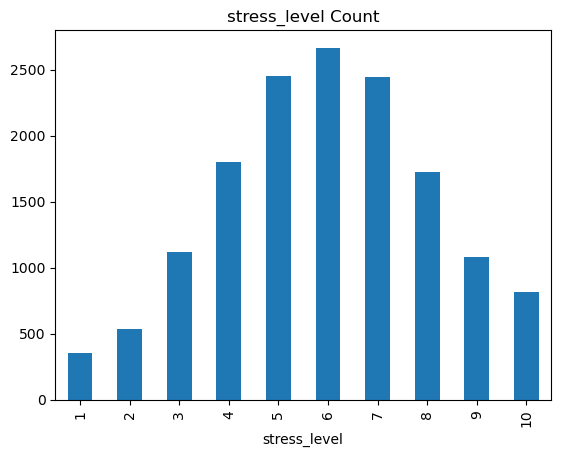

In [51]:
stress_level_count=df["stress_level"].value_counts().sort_index()
stress_level_count.plot(kind="bar")
plt.title("stress_level Count")
plt.xlabel("stress_level")
plt.show()

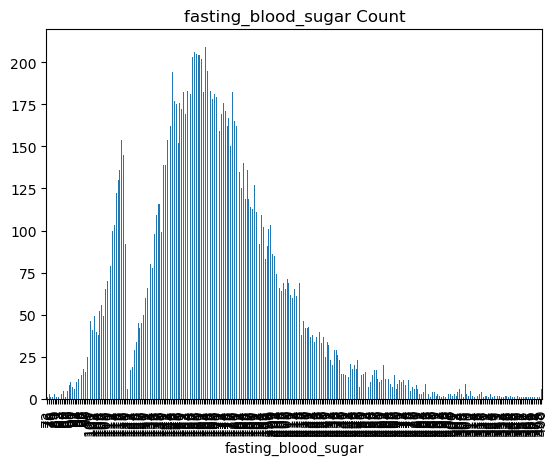

In [50]:
fasting_blood_sugar_count=df["fasting_blood_sugar"].value_counts().sort_index()
fasting_blood_sugar_count.plot(kind="bar")
plt.title("fasting_blood_sugar Count")
plt.xlabel("fasting_blood_sugar")
plt.show()

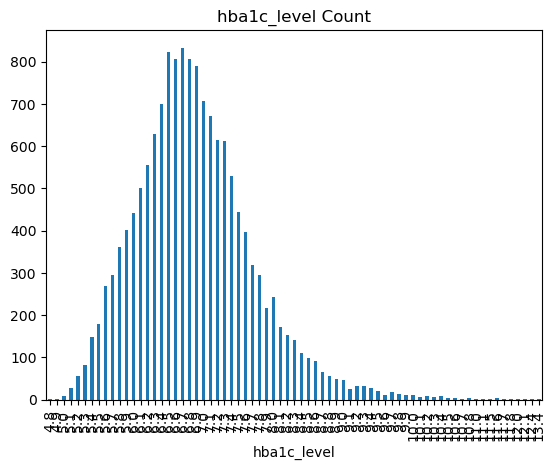

In [49]:
hba1c_level_count=df["hba1c_level"].value_counts().sort_index()
hba1c_level_count.plot(kind="bar")
plt.title("hba1c_level Count")
plt.xlabel("hba1c_level")
plt.show()

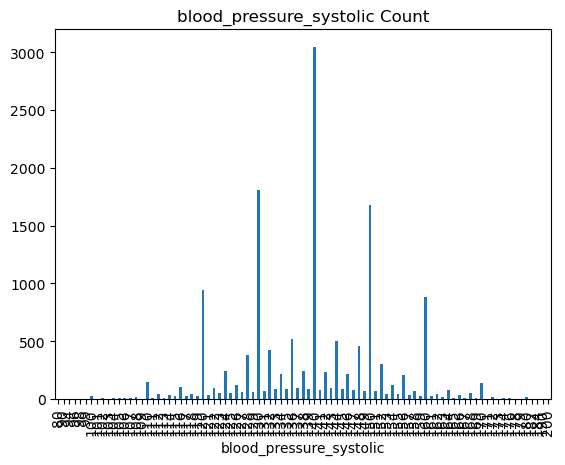

In [48]:
blood_pressure_systolic_count=df["blood_pressure_systolic"].value_counts().sort_index()
blood_pressure_systolic_count.plot(kind="bar")
plt.title("blood_pressure_systolic Count")
plt.xlabel("blood_pressure_systolic")
plt.show()

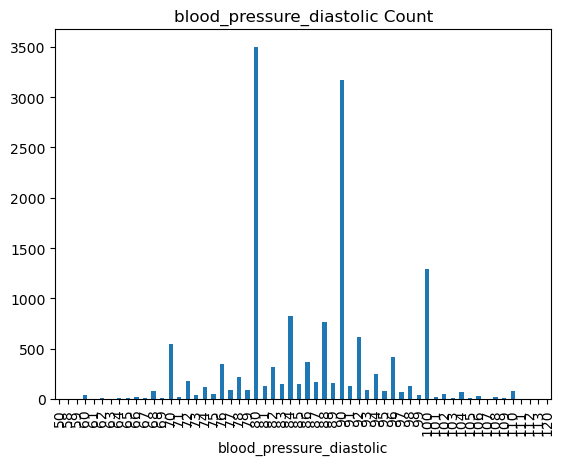

In [47]:
blood_pressure_diastolic_count=df["blood_pressure_diastolic"].value_counts().sort_index()
blood_pressure_diastolic_count.plot(kind="bar")
plt.title("blood_pressure_diastolic Count")
plt.xlabel("blood_pressure_diastolic")
plt.show()

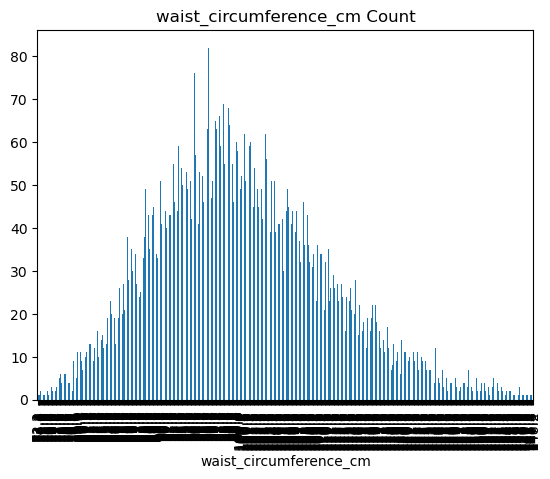

In [46]:
waist_circumference_cm_count=df["waist_circumference_cm"].value_counts().sort_index()
waist_circumference_cm_count.plot(kind="bar")
plt.title("waist_circumference_cm Count")
plt.xlabel("waist_circumference_cm")
plt.show()

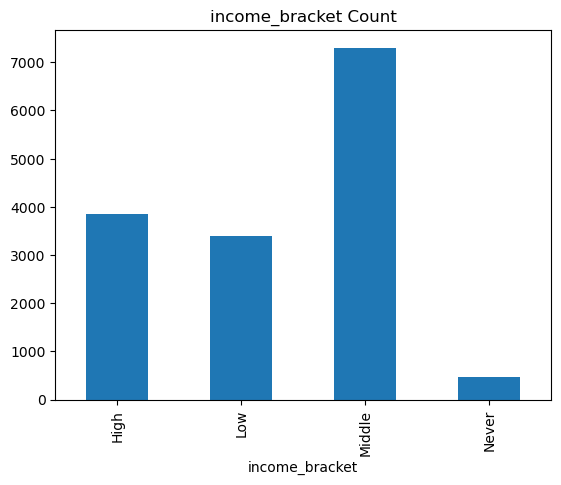

In [45]:
income_bracket_count=df["income_bracket"].value_counts().sort_index()
income_bracket_count.plot(kind="bar")
plt.title("income_bracket Count")
plt.xlabel("income_bracket")
plt.show()

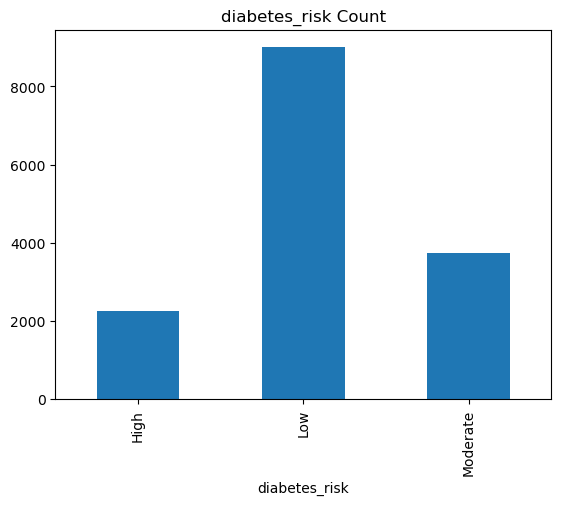

In [44]:
diabetes_risk_count=df["diabetes_risk"].value_counts().sort_index()
diabetes_risk_count.plot(kind="bar")
plt.title("diabetes_risk Count")
plt.xlabel("diabetes_risk")
plt.show()

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

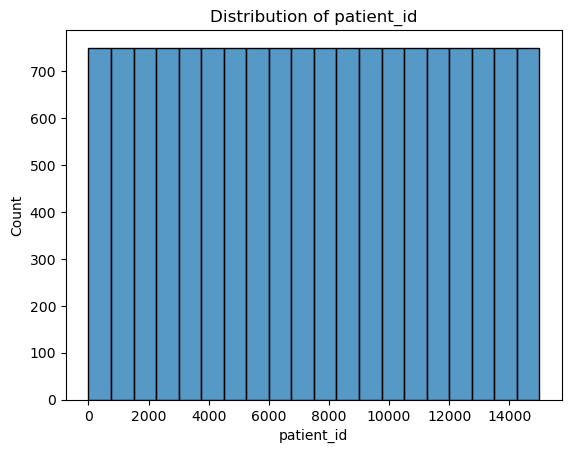

In [87]:
sns.histplot(df['patient_id'], bins=20)
plt.title('Distribution of patient_id')
plt.show()

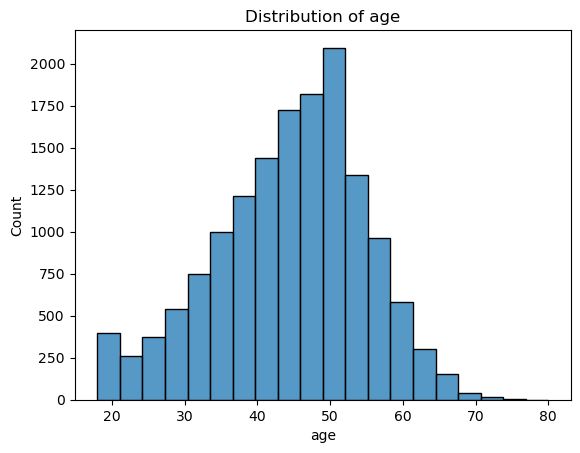

In [86]:
sns.histplot(df['age'], bins=20)
plt.title('Distribution of age')
plt.show()

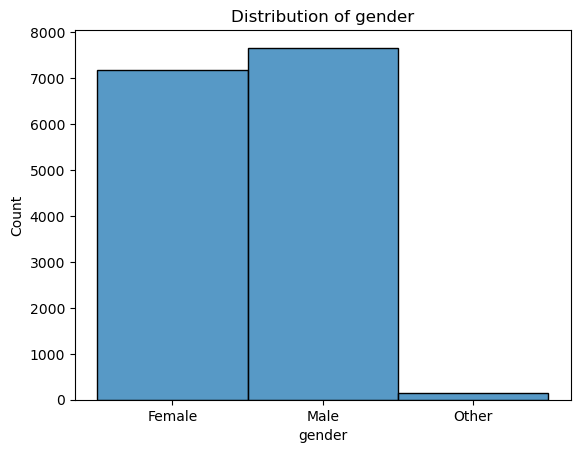

In [85]:
sns.histplot(df['gender'], bins=20)
plt.title('Distribution of gender')
plt.show()

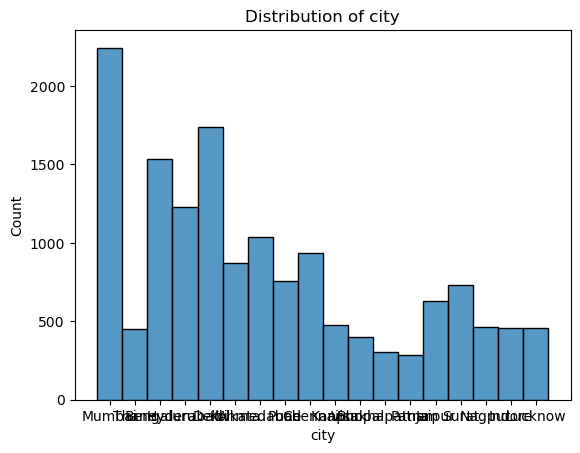

In [84]:
sns.histplot(df['city'], bins=20)
plt.title('Distribution of city')
plt.show()

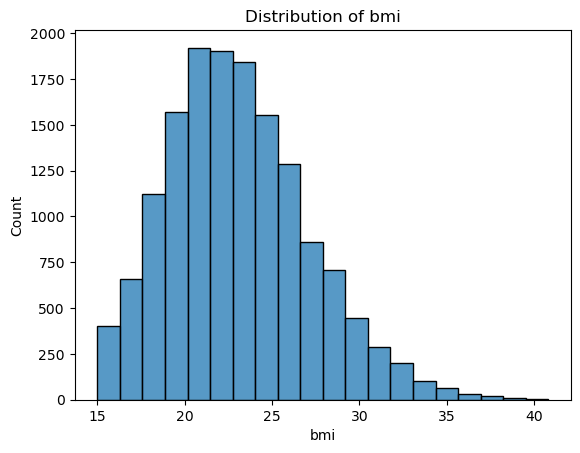

In [83]:
sns.histplot(df['bmi'], bins=20)
plt.title('Distribution of bmi')
plt.show()

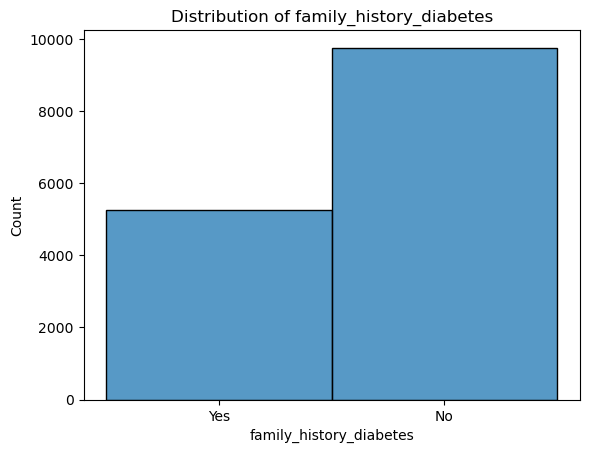

In [82]:
sns.histplot(df['family_history_diabetes'], bins=20)
plt.title('Distribution of family_history_diabetes')
plt.show()

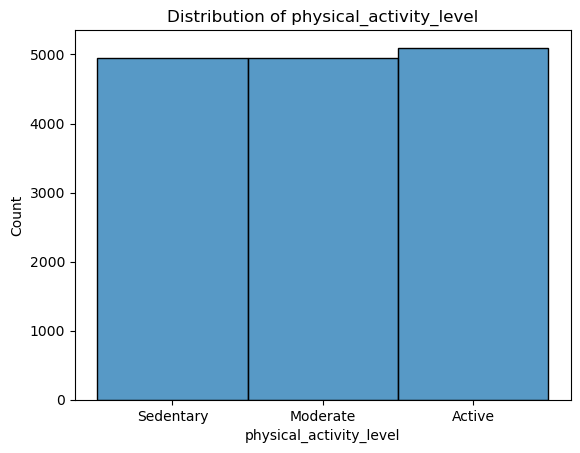

In [81]:
sns.histplot(df['physical_activity_level'], bins=20)
plt.title('Distribution of physical_activity_level')
plt.show()

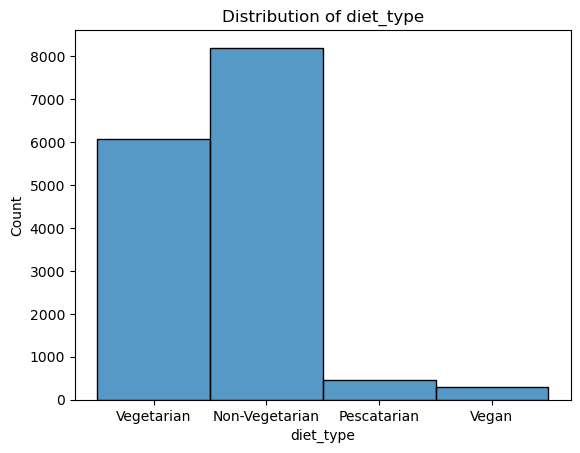

In [80]:
sns.histplot(df['diet_type'], bins=20)
plt.title('Distribution of diet_type')
plt.show()

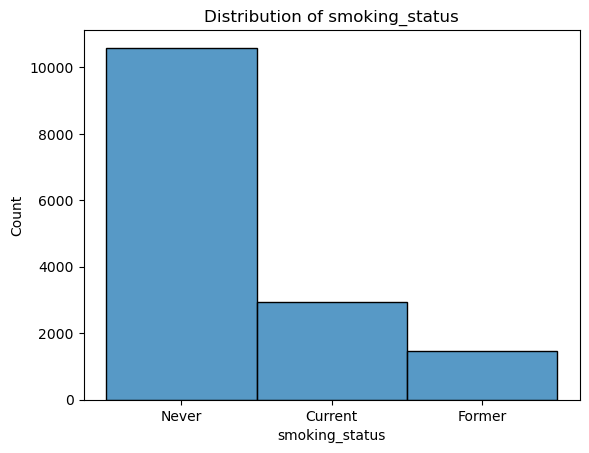

In [79]:
sns.histplot(df['smoking_status'], bins=20)
plt.title('Distribution of smoking_status')
plt.show()

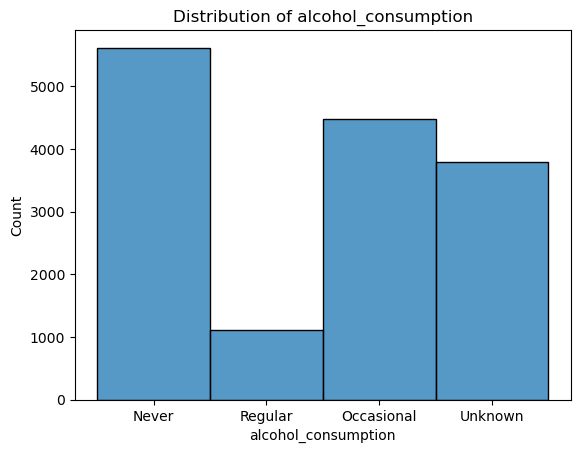

In [78]:
sns.histplot(df['alcohol_consumption'], bins=20)
plt.title('Distribution of alcohol_consumption')
plt.show()

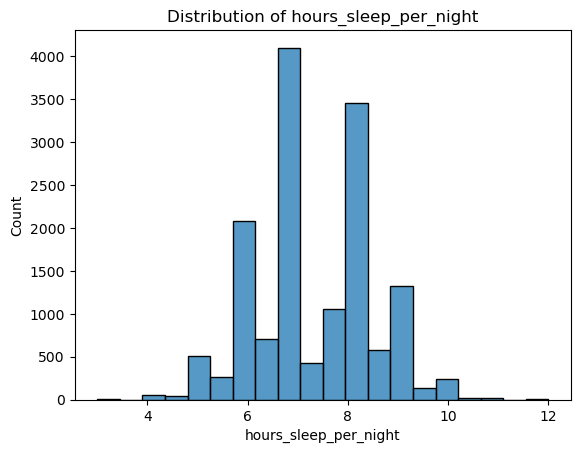

In [77]:
sns.histplot(df['hours_sleep_per_night'], bins=20)
plt.title('Distribution of hours_sleep_per_night')
plt.show()

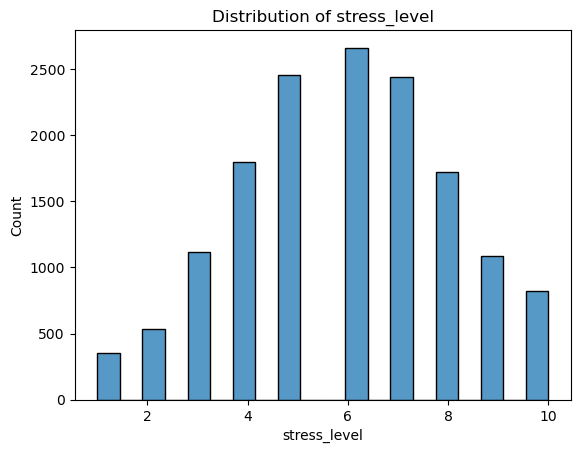

In [76]:
sns.histplot(df['stress_level'], bins=20)
plt.title('Distribution of stress_level')
plt.show()

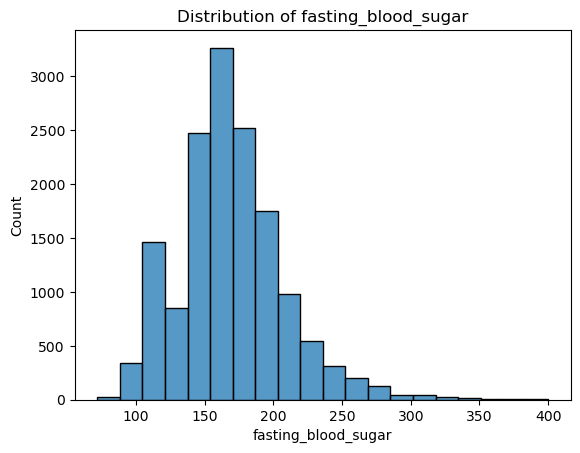

In [75]:
sns.histplot(df['fasting_blood_sugar'], bins=20)
plt.title('Distribution of fasting_blood_sugar')
plt.show()

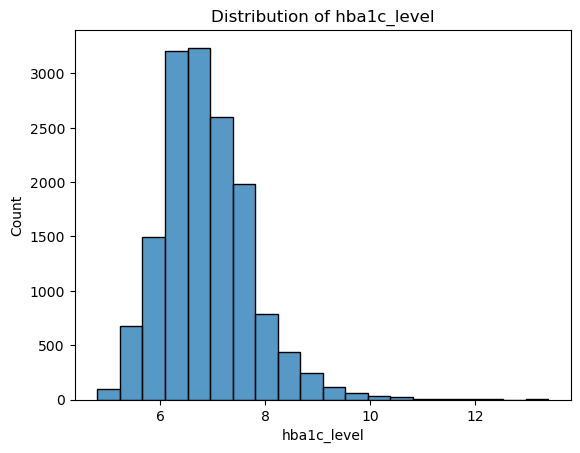

In [74]:
sns.histplot(df['hba1c_level'], bins=20)
plt.title('Distribution of hba1c_level')
plt.show()

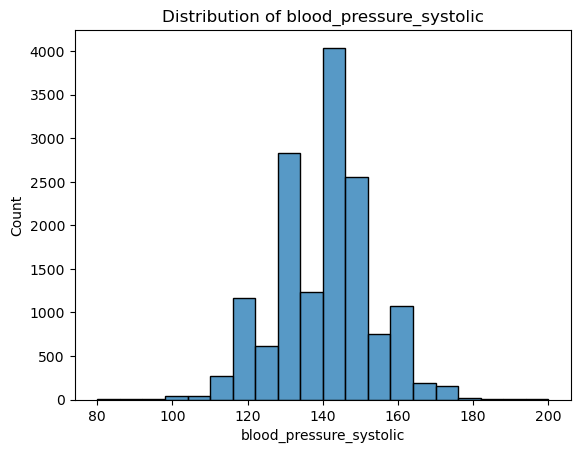

In [ ]:
sns.histplot(df['blood_pressure_systolic'], bins=20)
plt.title('Distribution of blood_pressure_systolic')
plt.show()

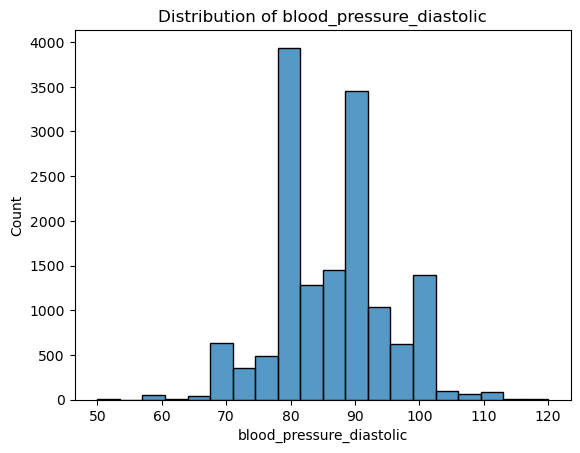

In [72]:
sns.histplot(df['blood_pressure_diastolic'], bins=20)
plt.title('Distribution of blood_pressure_diastolic')
plt.show()

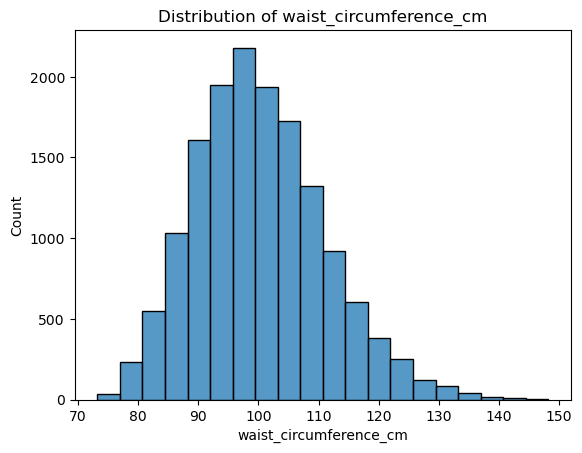

In [71]:
sns.histplot(df['waist_circumference_cm'], bins=20)
plt.title('Distribution of waist_circumference_cm')
plt.show()

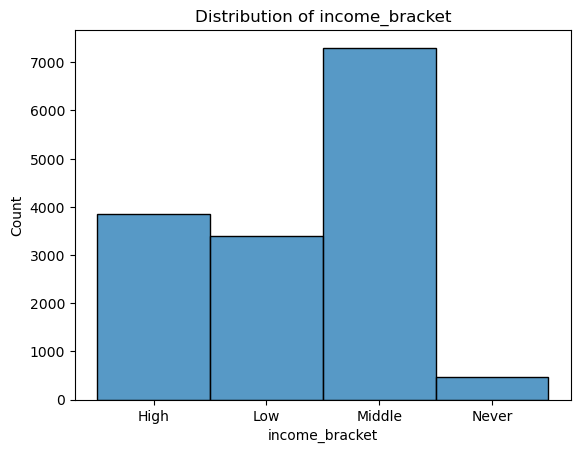

In [70]:
sns.histplot(df['income_bracket'], bins=20)
plt.title('Distribution of income_bracket')
plt.show()

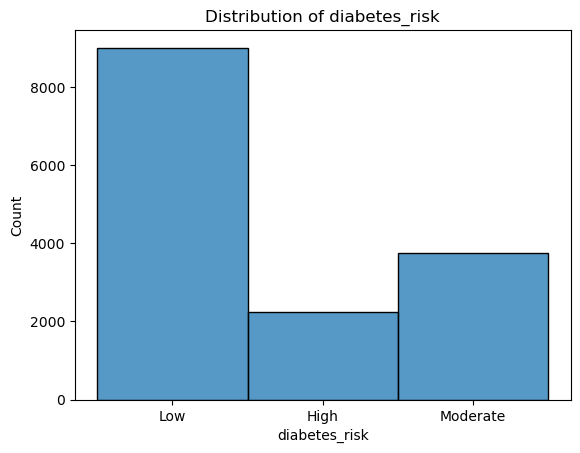

In [69]:
sns.histplot(df['diabetes_risk'], bins=20)
plt.title('Distribution of diabetes_risk')
plt.show()

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

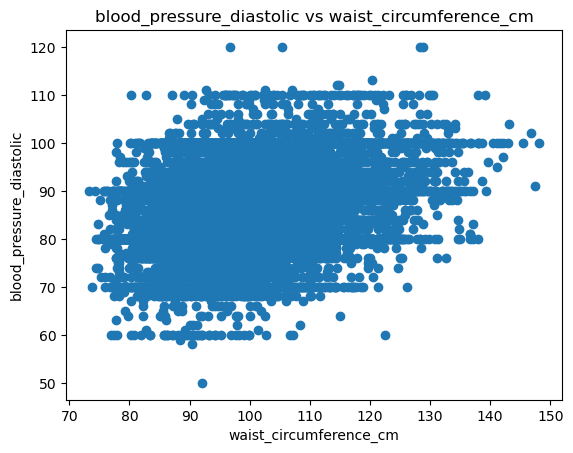

In [160]:
plt.scatter(df["waist_circumference_cm"], df["blood_pressure_diastolic"])
plt.xlabel("waist_circumference_cm")
plt.ylabel("blood_pressure_diastolic")
plt.title("blood_pressure_diastolic vs waist_circumference_cm")
plt.show()

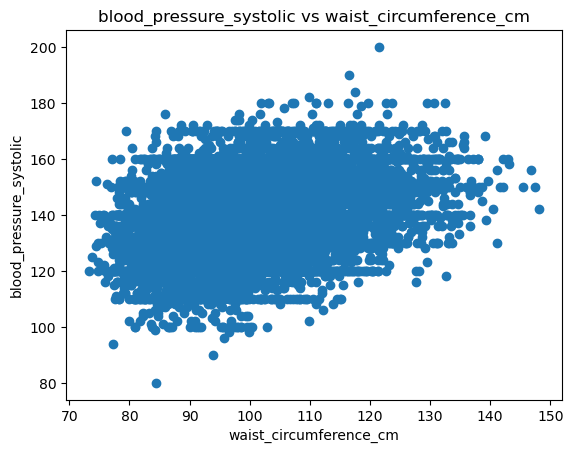

In [159]:
plt.scatter(df["waist_circumference_cm"], df["blood_pressure_systolic"])
plt.xlabel("waist_circumference_cm")
plt.ylabel("blood_pressure_systolic")
plt.title("blood_pressure_systolic vs waist_circumference_cm")
plt.show()

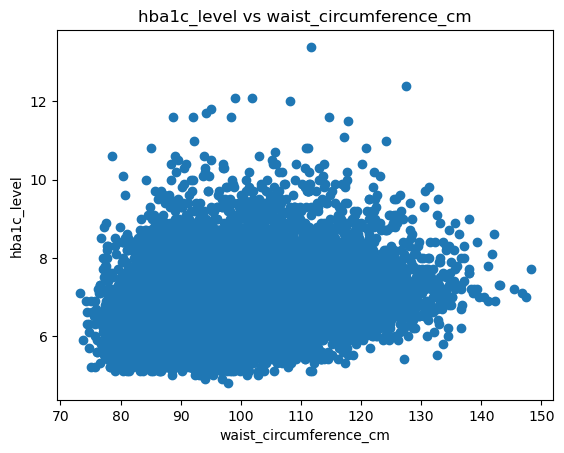

In [158]:
plt.scatter(df["waist_circumference_cm"], df["hba1c_level"])
plt.xlabel("waist_circumference_cm")
plt.ylabel("hba1c_level")
plt.title("hba1c_level vs waist_circumference_cm")
plt.show()

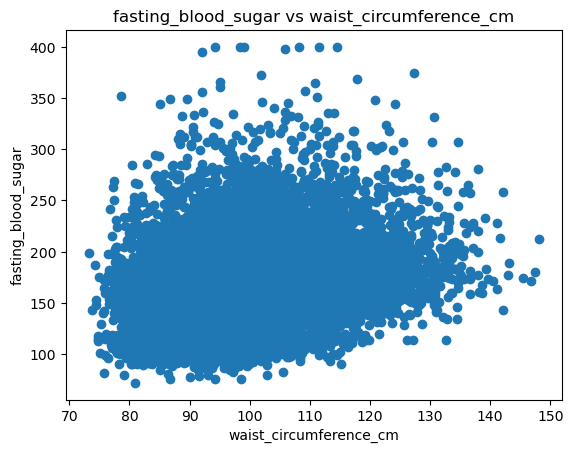

In [157]:
plt.scatter(df["waist_circumference_cm"], df["fasting_blood_sugar"])
plt.xlabel("waist_circumference_cm")
plt.ylabel("fasting_blood_sugar")
plt.title("fasting_blood_sugar vs waist_circumference_cm")
plt.show()

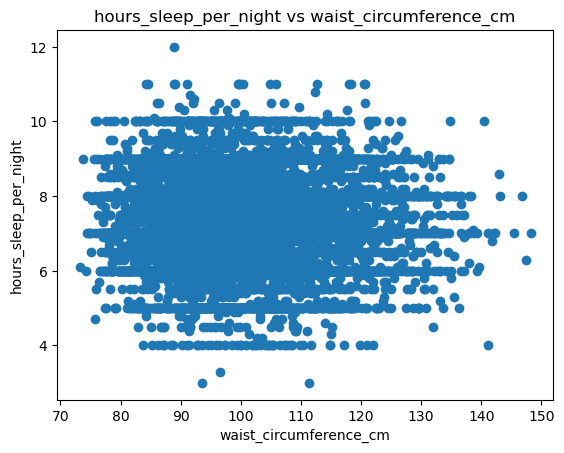

In [155]:
plt.scatter(df["waist_circumference_cm"], df["hours_sleep_per_night"])
plt.xlabel("waist_circumference_cm")
plt.ylabel("hours_sleep_per_night")
plt.title("hours_sleep_per_night vs waist_circumference_cm")
plt.show()

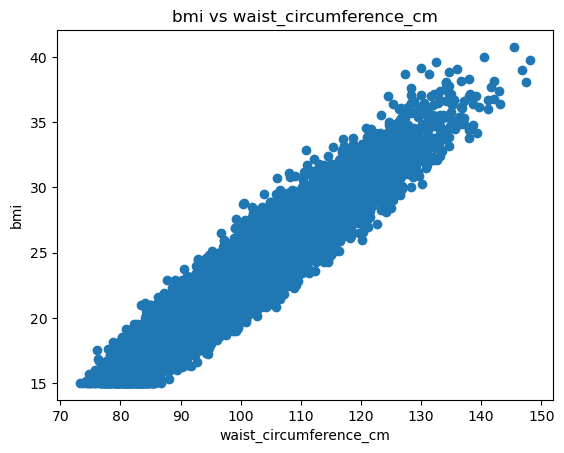

In [154]:
plt.scatter(df["waist_circumference_cm"], df["bmi"])
plt.xlabel("waist_circumference_cm")
plt.ylabel("bmi")
plt.title("bmi vs waist_circumference_cm")
plt.show()

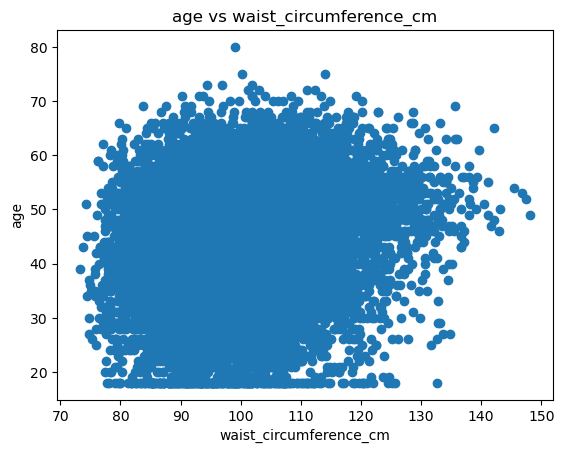

In [153]:
plt.scatter(df["waist_circumference_cm"], df["age"])
plt.xlabel("waist_circumference_cm")
plt.ylabel("age")
plt.title("age vs waist_circumference_cm")
plt.show()

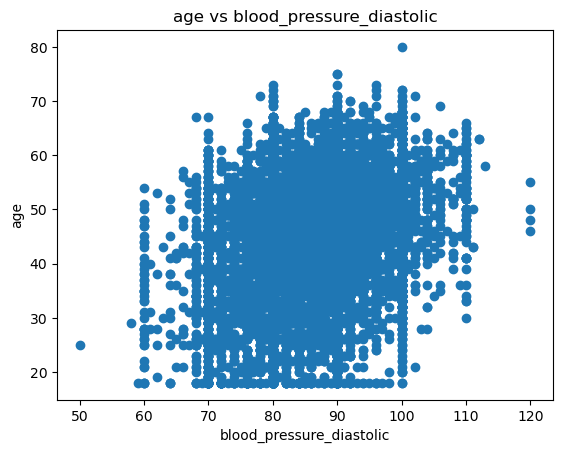

In [152]:
plt.scatter(df["blood_pressure_diastolic"], df["age"])
plt.xlabel("blood_pressure_diastolic")
plt.ylabel("age")
plt.title("age vs blood_pressure_diastolic")
plt.show()

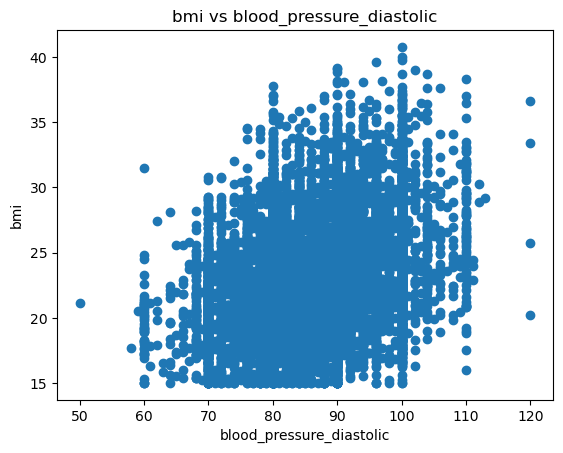

In [151]:
plt.scatter(df["blood_pressure_diastolic"], df["bmi"])
plt.xlabel("blood_pressure_diastolic")
plt.ylabel("bmi")
plt.title("bmi vs blood_pressure_diastolic")
plt.show()

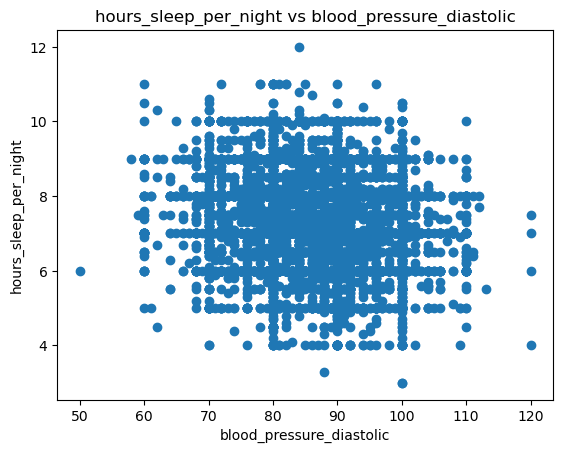

In [150]:
plt.scatter(df["blood_pressure_diastolic"], df["hours_sleep_per_night"])
plt.xlabel("blood_pressure_diastolic")
plt.ylabel("hours_sleep_per_night")
plt.title("hours_sleep_per_night vs blood_pressure_diastolic")
plt.show()

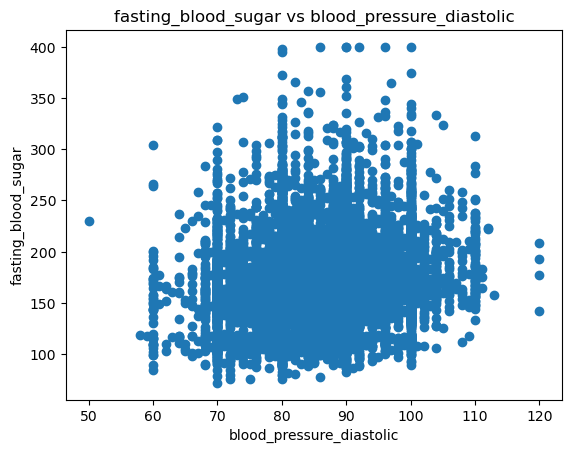

In [148]:
plt.scatter(df["blood_pressure_diastolic"], df["fasting_blood_sugar"])
plt.xlabel("blood_pressure_diastolic")
plt.ylabel("fasting_blood_sugar")
plt.title("fasting_blood_sugar vs blood_pressure_diastolic")
plt.show()

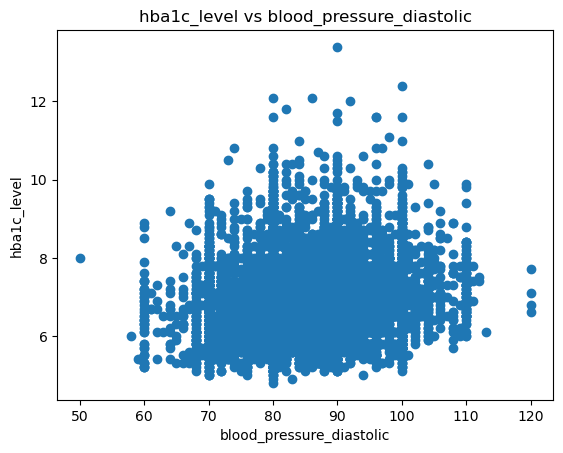

In [147]:
plt.scatter(df["blood_pressure_diastolic"], df["hba1c_level"])
plt.xlabel("blood_pressure_diastolic")
plt.ylabel("hba1c_level")
plt.title("hba1c_level vs blood_pressure_diastolic")
plt.show()

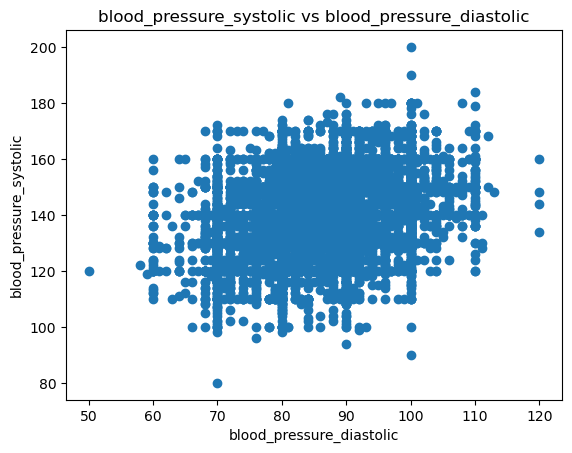

In [146]:
plt.scatter(df["blood_pressure_diastolic"], df["blood_pressure_systolic"])
plt.xlabel("blood_pressure_diastolic")
plt.ylabel("blood_pressure_systolic")
plt.title("blood_pressure_systolic vs blood_pressure_diastolic")
plt.show()

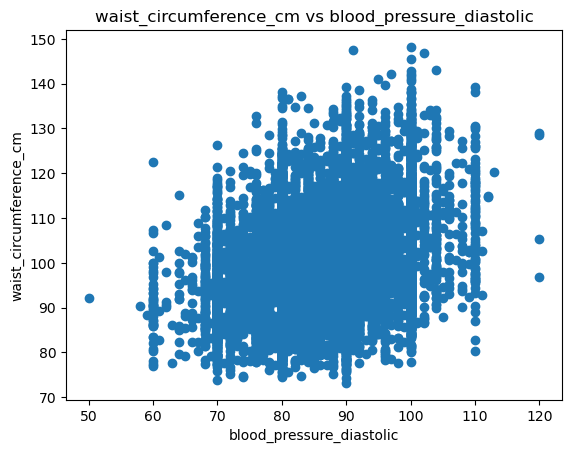

In [145]:
plt.scatter(df["blood_pressure_diastolic"], df["waist_circumference_cm"])
plt.xlabel("blood_pressure_diastolic")
plt.ylabel("waist_circumference_cm")
plt.title("waist_circumference_cm vs blood_pressure_diastolic")
plt.show()

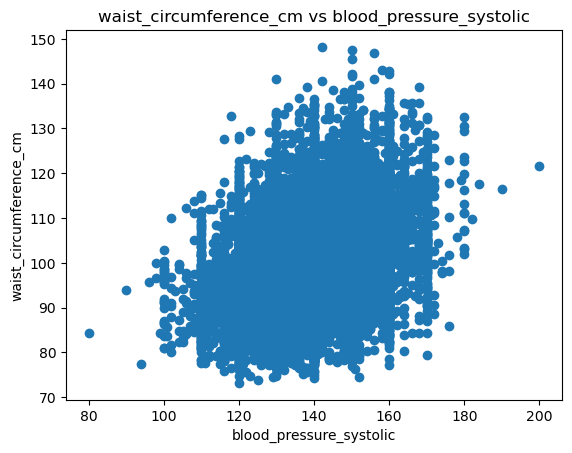

In [144]:
plt.scatter(df["blood_pressure_systolic"], df["waist_circumference_cm"])
plt.xlabel("blood_pressure_systolic")
plt.ylabel("waist_circumference_cm")
plt.title("waist_circumference_cm vs blood_pressure_systolic")
plt.show()

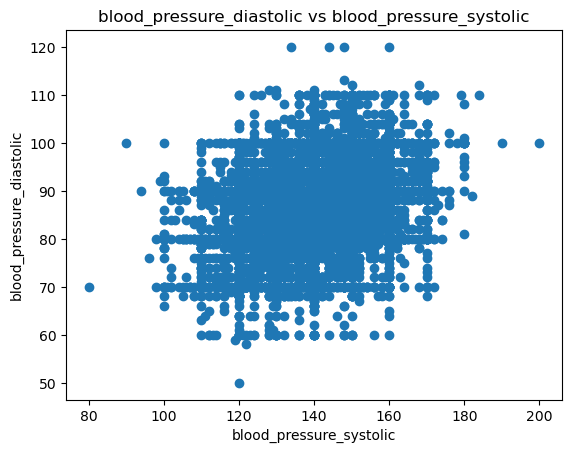

In [143]:
plt.scatter(df["blood_pressure_systolic"], df["blood_pressure_diastolic"])
plt.xlabel("blood_pressure_systolic")
plt.ylabel("blood_pressure_diastolic")
plt.title("blood_pressure_diastolic vs blood_pressure_systolic")
plt.show()

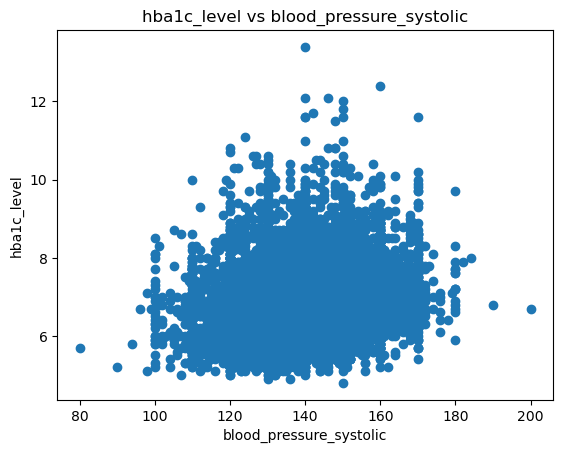

In [142]:
plt.scatter(df["blood_pressure_systolic"], df["hba1c_level"])
plt.xlabel("blood_pressure_systolic")
plt.ylabel("hba1c_level")
plt.title("hba1c_level vs blood_pressure_systolic")
plt.show()

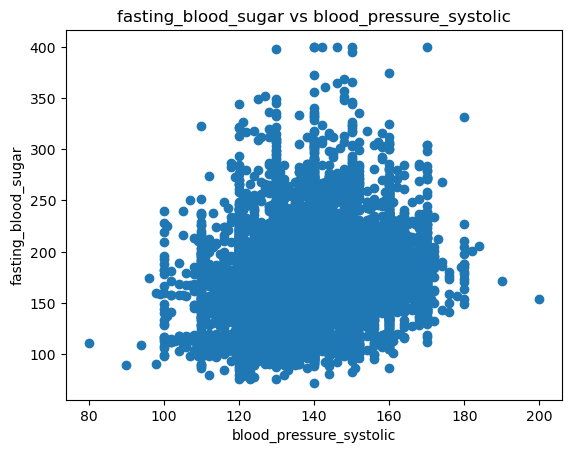

In [141]:
plt.scatter(df["blood_pressure_systolic"], df["fasting_blood_sugar"])
plt.xlabel("blood_pressure_systolic")
plt.ylabel("fasting_blood_sugar")
plt.title("fasting_blood_sugar vs blood_pressure_systolic")
plt.show()

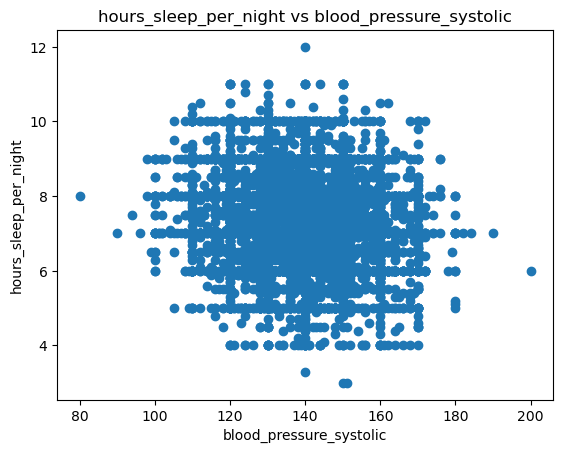

In [139]:
plt.scatter(df["blood_pressure_systolic"], df["hours_sleep_per_night"])
plt.xlabel("blood_pressure_systolic")
plt.ylabel("hours_sleep_per_night")
plt.title("hours_sleep_per_night vs blood_pressure_systolic")
plt.show()

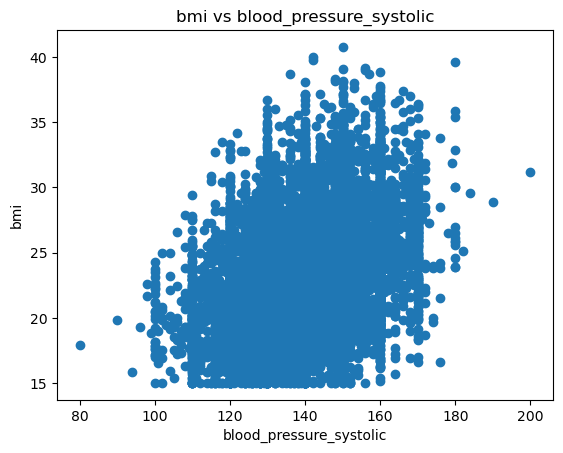

In [138]:
plt.scatter(df["blood_pressure_systolic"], df["bmi"])
plt.xlabel("blood_pressure_systolic")
plt.ylabel("bmi")
plt.title("bmi vs blood_pressure_systolic")
plt.show()

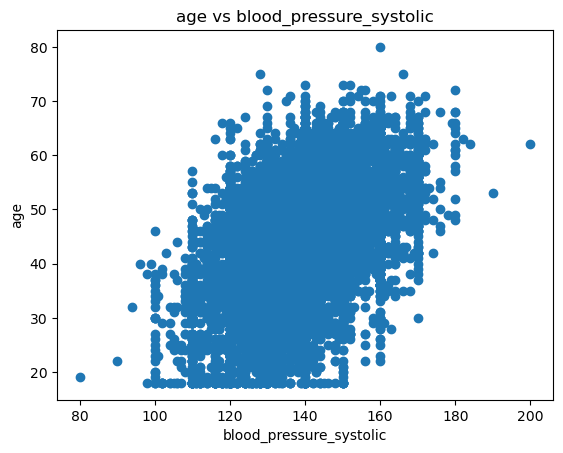

In [137]:
plt.scatter(df["blood_pressure_systolic"], df["age"])
plt.xlabel("blood_pressure_systolic")
plt.ylabel("age")
plt.title("age vs blood_pressure_systolic")
plt.show()

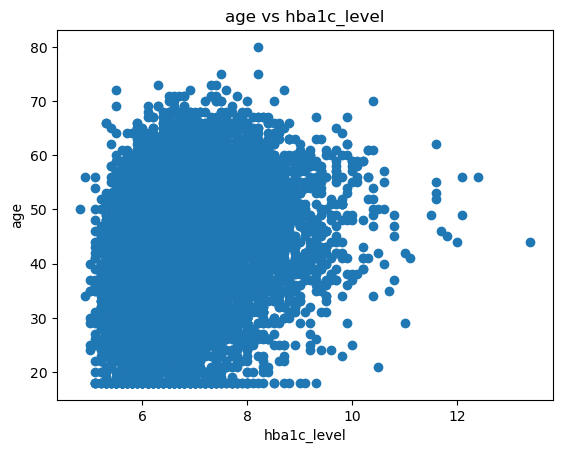

In [136]:
plt.scatter(df["hba1c_level"], df["age"])
plt.xlabel("hba1c_level")
plt.ylabel("age")
plt.title("age vs hba1c_level")
plt.show()

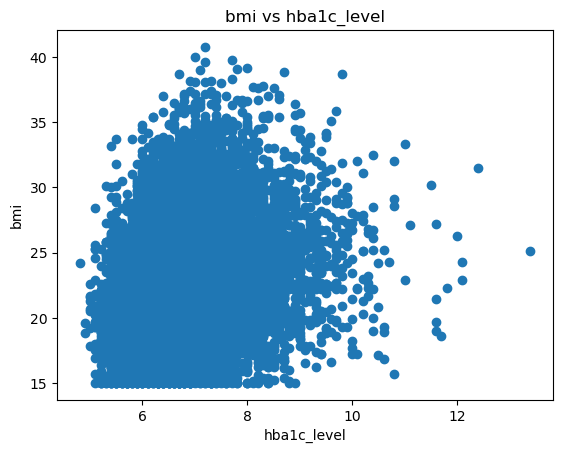

In [135]:
plt.scatter(df["hba1c_level"], df["bmi"])
plt.xlabel("hba1c_level")
plt.ylabel("bmi")
plt.title("bmi vs hba1c_level")
plt.show()

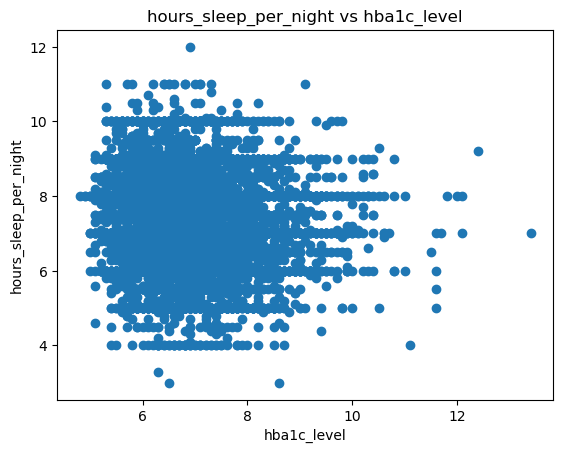

In [134]:
plt.scatter(df["hba1c_level"], df["hours_sleep_per_night"])
plt.xlabel("hba1c_level")
plt.ylabel("hours_sleep_per_night")
plt.title("hours_sleep_per_night vs hba1c_level")
plt.show()

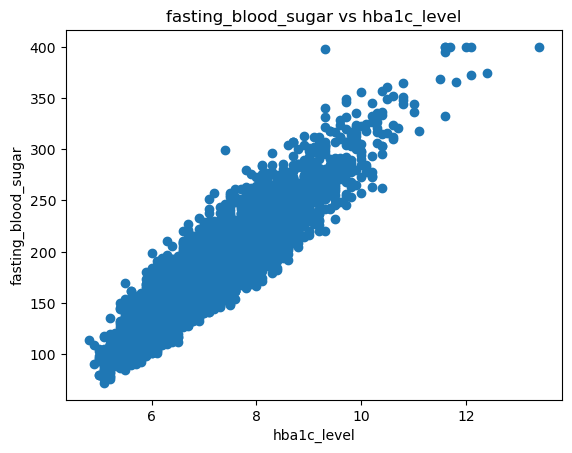

In [133]:
plt.scatter(df["hba1c_level"], df["fasting_blood_sugar"])
plt.xlabel("hba1c_level")
plt.ylabel("fasting_blood_sugar")
plt.title("fasting_blood_sugar vs hba1c_level")
plt.show()

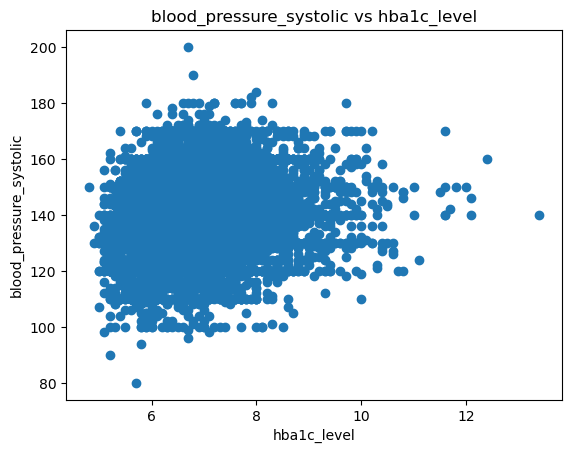

In [132]:
plt.scatter(df["hba1c_level"], df["blood_pressure_systolic"])
plt.xlabel("hba1c_level")
plt.ylabel("blood_pressure_systolic")
plt.title("blood_pressure_systolic vs hba1c_level")
plt.show()

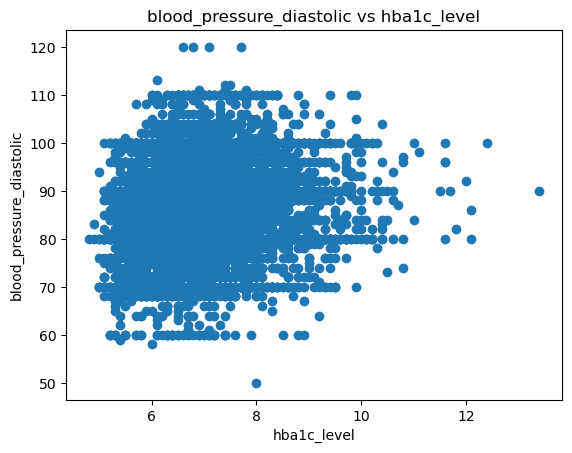

In [131]:
plt.scatter(df["hba1c_level"], df["blood_pressure_diastolic"])
plt.xlabel("hba1c_level")
plt.ylabel("blood_pressure_diastolic")
plt.title("blood_pressure_diastolic vs hba1c_level")
plt.show()

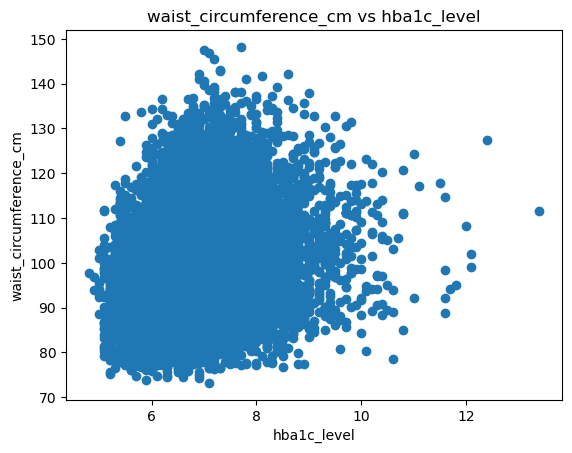

In [130]:
plt.scatter(df["hba1c_level"], df["waist_circumference_cm"])
plt.xlabel("hba1c_level")
plt.ylabel("waist_circumference_cm")
plt.title("waist_circumference_cm vs hba1c_level")
plt.show()

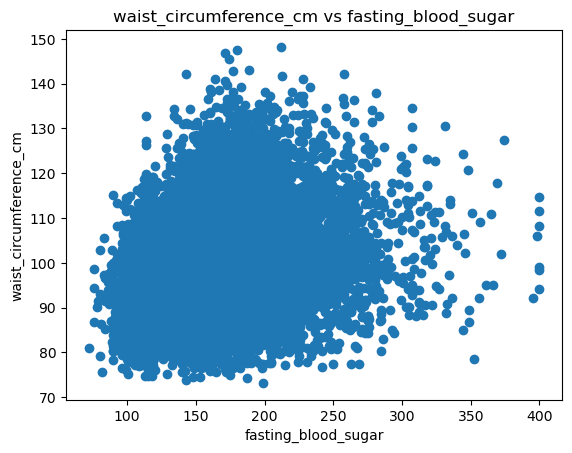

In [129]:
plt.scatter(df["fasting_blood_sugar"], df["waist_circumference_cm"])
plt.xlabel("fasting_blood_sugar")
plt.ylabel("waist_circumference_cm")
plt.title("waist_circumference_cm vs fasting_blood_sugar")
plt.show()

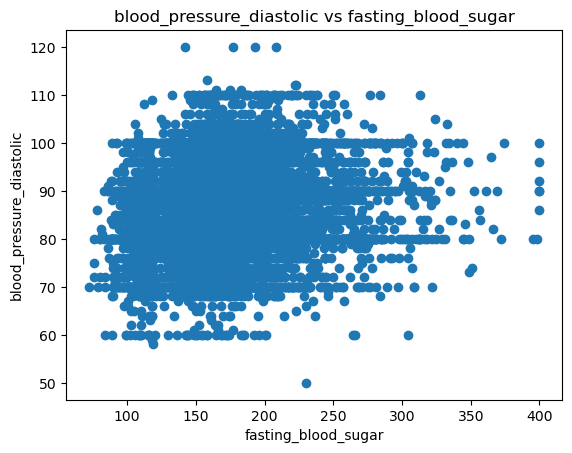

In [128]:
plt.scatter(df["fasting_blood_sugar"], df["blood_pressure_diastolic"])
plt.xlabel("fasting_blood_sugar")
plt.ylabel("blood_pressure_diastolic")
plt.title("blood_pressure_diastolic vs fasting_blood_sugar")
plt.show()

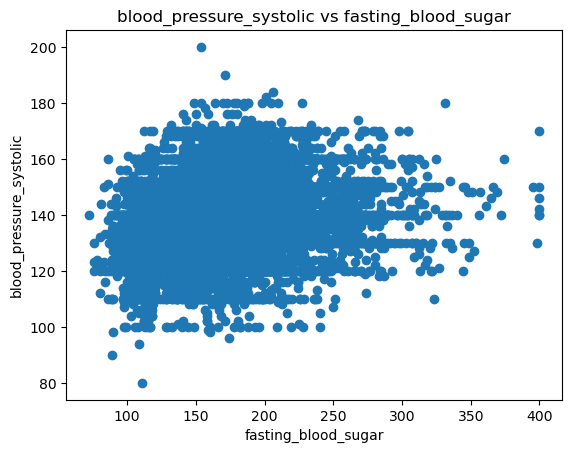

In [127]:
plt.scatter(df["fasting_blood_sugar"], df["blood_pressure_systolic"])
plt.xlabel("fasting_blood_sugar")
plt.ylabel("blood_pressure_systolic")
plt.title("blood_pressure_systolic vs fasting_blood_sugar")
plt.show()

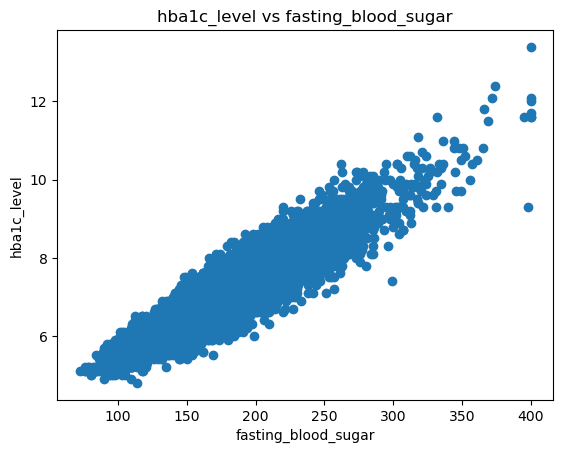

In [126]:
plt.scatter(df["fasting_blood_sugar"], df["hba1c_level"])
plt.xlabel("fasting_blood_sugar")
plt.ylabel("hba1c_level")
plt.title("hba1c_level vs fasting_blood_sugar")
plt.show()

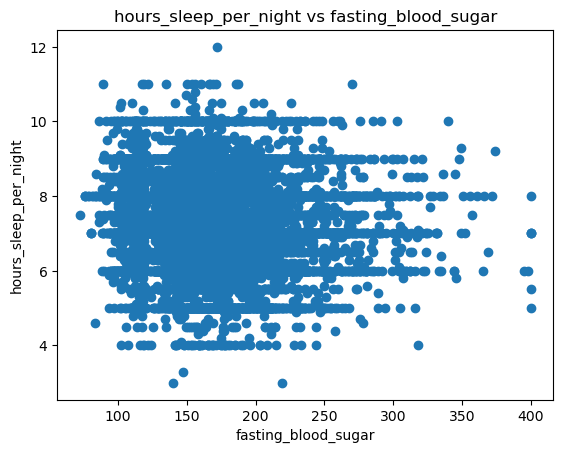

In [124]:
plt.scatter(df["fasting_blood_sugar"], df["hours_sleep_per_night"])
plt.xlabel("fasting_blood_sugar")
plt.ylabel("hours_sleep_per_night")
plt.title("hours_sleep_per_night vs fasting_blood_sugar")
plt.show()

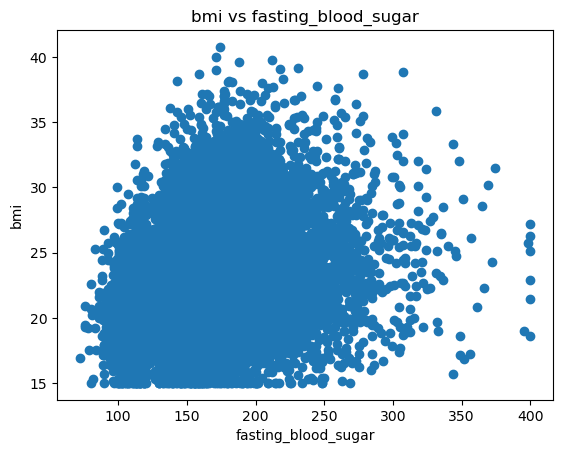

In [123]:
plt.scatter(df["fasting_blood_sugar"], df["bmi"])
plt.xlabel("fasting_blood_sugar")
plt.ylabel("bmi")
plt.title("bmi vs fasting_blood_sugar")
plt.show()

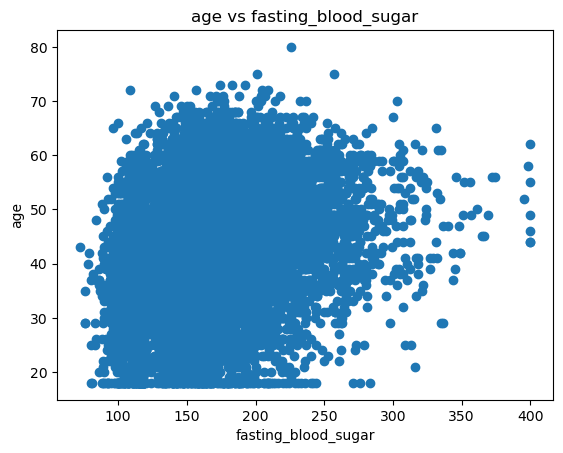

In [122]:
plt.scatter(df["fasting_blood_sugar"], df["age"])
plt.xlabel("fasting_blood_sugar")
plt.ylabel("age")
plt.title("age vs fasting_blood_sugar")
plt.show()

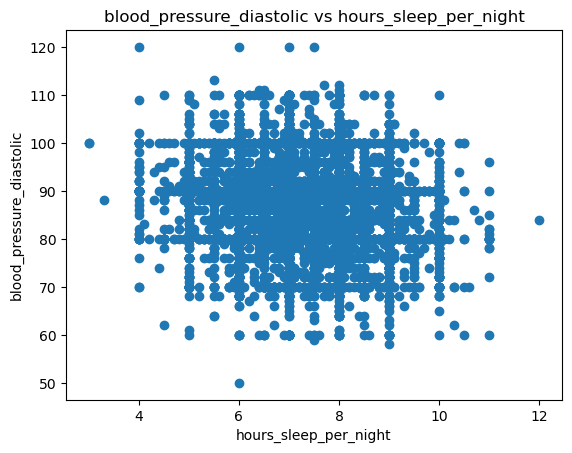

In [112]:
plt.scatter(df["hours_sleep_per_night"], df["blood_pressure_diastolic"])
plt.xlabel("hours_sleep_per_night")
plt.ylabel("blood_pressure_diastolic")
plt.title("blood_pressure_diastolic vs hours_sleep_per_night")
plt.show()

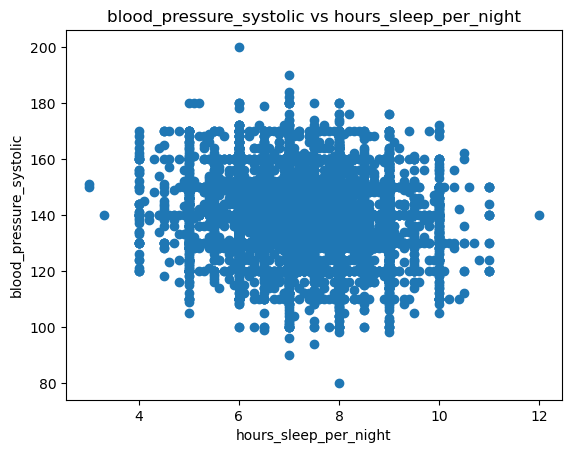

In [111]:
plt.scatter(df["hours_sleep_per_night"], df["blood_pressure_systolic"])
plt.xlabel("hours_sleep_per_night")
plt.ylabel("blood_pressure_systolic")
plt.title("blood_pressure_systolic vs hours_sleep_per_night")
plt.show()

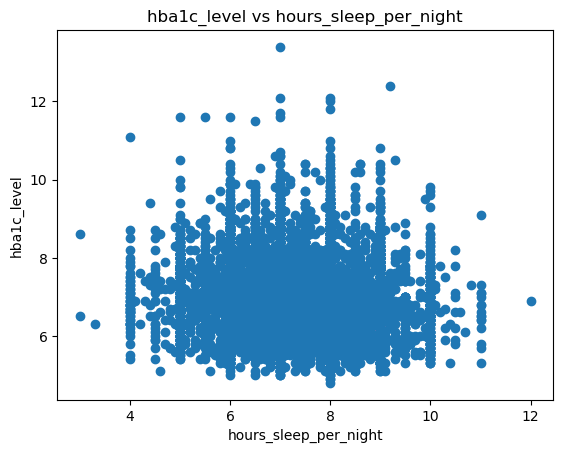

In [110]:
plt.scatter(df["hours_sleep_per_night"], df["hba1c_level"])
plt.xlabel("hours_sleep_per_night")
plt.ylabel("hba1c_level")
plt.title("hba1c_level vs hours_sleep_per_night")
plt.show()

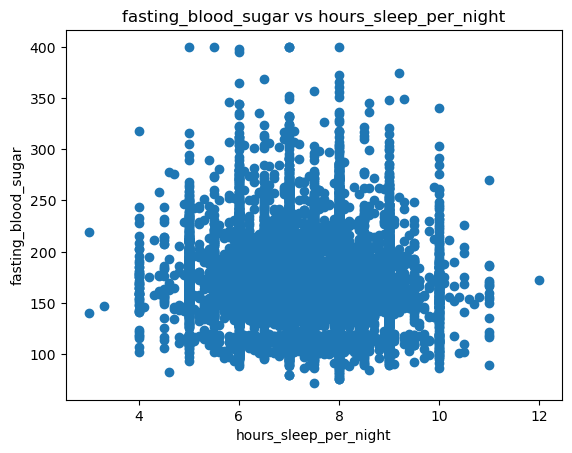

In [109]:
plt.scatter(df["hours_sleep_per_night"], df["fasting_blood_sugar"])
plt.xlabel("hours_sleep_per_night")
plt.ylabel("fasting_blood_sugar")
plt.title("fasting_blood_sugar vs hours_sleep_per_night")
plt.show()

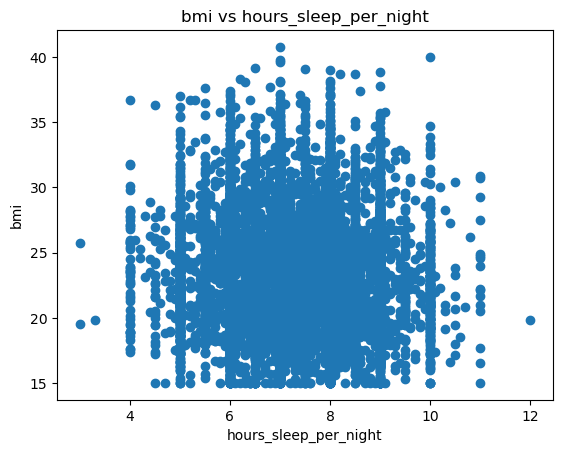

In [107]:
plt.scatter(df["hours_sleep_per_night"], df["bmi"])
plt.xlabel("hours_sleep_per_night")
plt.ylabel("bmi")
plt.title("bmi vs hours_sleep_per_night")
plt.show()

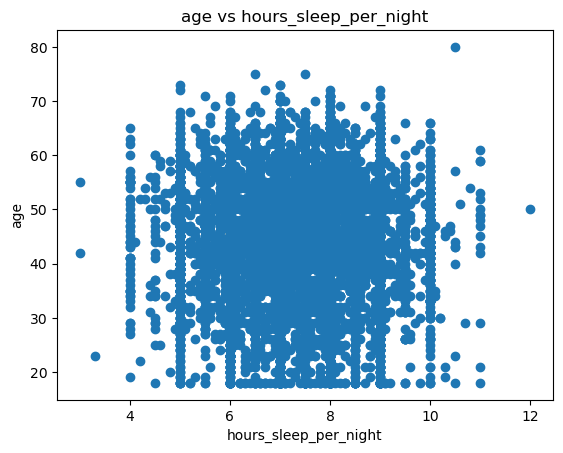

In [106]:
plt.scatter(df["hours_sleep_per_night"], df["age"])
plt.xlabel("hours_sleep_per_night")
plt.ylabel("age")
plt.title("age vs hours_sleep_per_night")
plt.show()

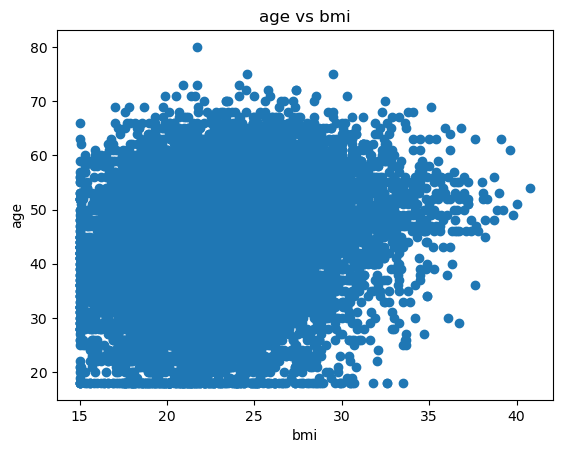

In [105]:
plt.scatter(df["bmi"], df["age"])
plt.xlabel("bmi")
plt.ylabel("age")
plt.title("age vs bmi")
plt.show()

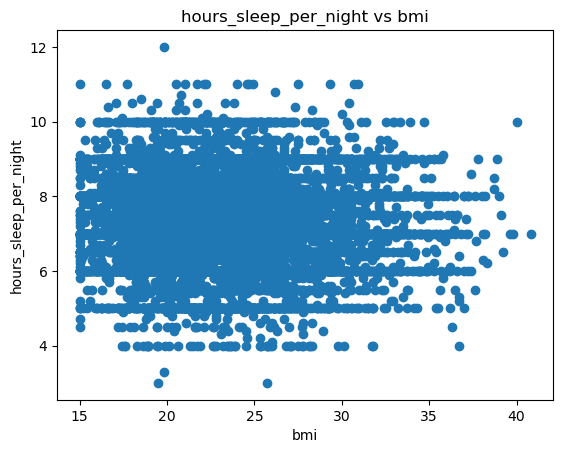

In [104]:
plt.scatter(df["bmi"], df["hours_sleep_per_night"])
plt.xlabel("bmi")
plt.ylabel("hours_sleep_per_night")
plt.title("hours_sleep_per_night vs bmi")
plt.show()

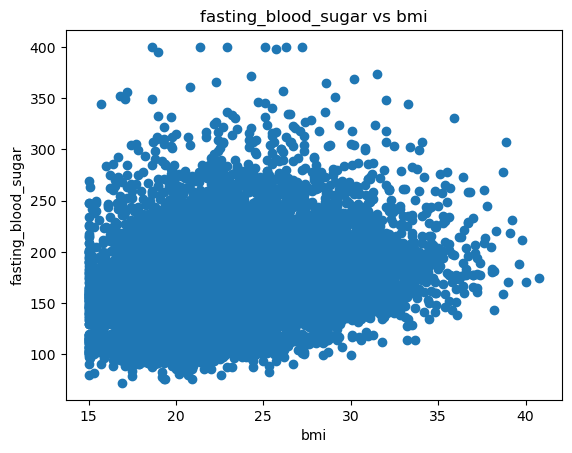

In [102]:
plt.scatter(df["bmi"], df["fasting_blood_sugar"])
plt.xlabel("bmi")
plt.ylabel("fasting_blood_sugar")
plt.title("fasting_blood_sugar vs bmi")
plt.show()

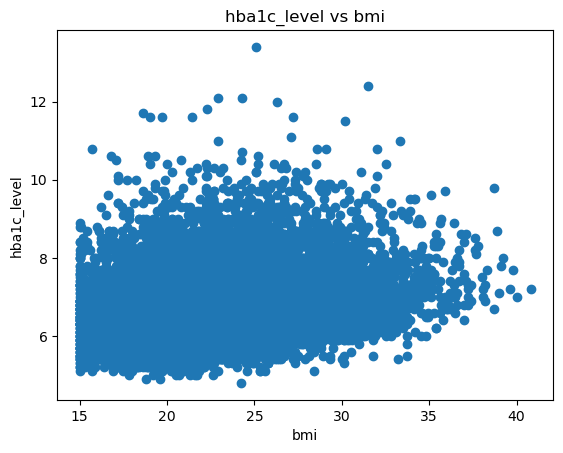

In [101]:
plt.scatter(df["bmi"], df["hba1c_level"])
plt.xlabel("bmi")
plt.ylabel("hba1c_level")
plt.title("hba1c_level vs bmi")
plt.show()

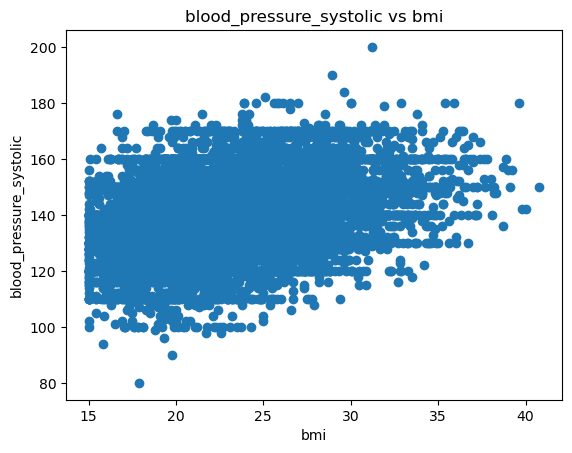

In [100]:
plt.scatter(df["bmi"], df["blood_pressure_systolic"])
plt.xlabel("bmi")
plt.ylabel("blood_pressure_systolic")
plt.title("blood_pressure_systolic vs bmi")
plt.show()

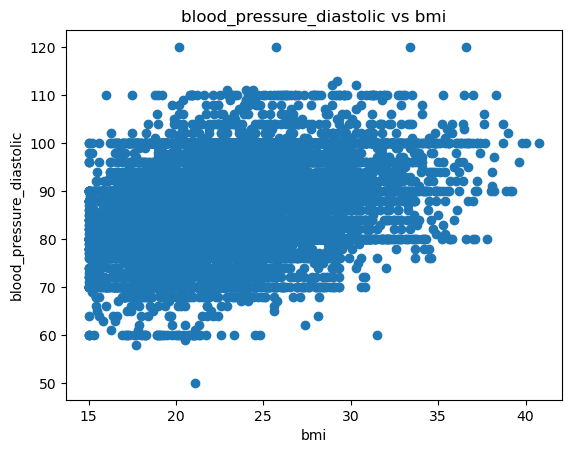

In [99]:
plt.scatter(df["bmi"], df["blood_pressure_diastolic"])
plt.xlabel("bmi")
plt.ylabel("blood_pressure_diastolic")
plt.title("blood_pressure_diastolic vs bmi")
plt.show()

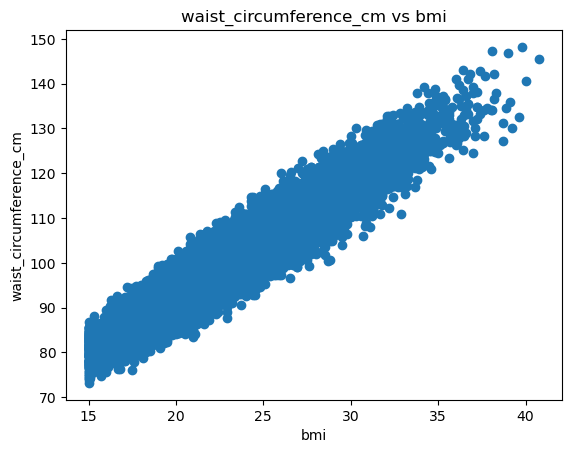

In [98]:
plt.scatter(df["bmi"], df["waist_circumference_cm"])
plt.xlabel("bmi")
plt.ylabel("waist_circumference_cm")
plt.title("waist_circumference_cm vs bmi")
plt.show()

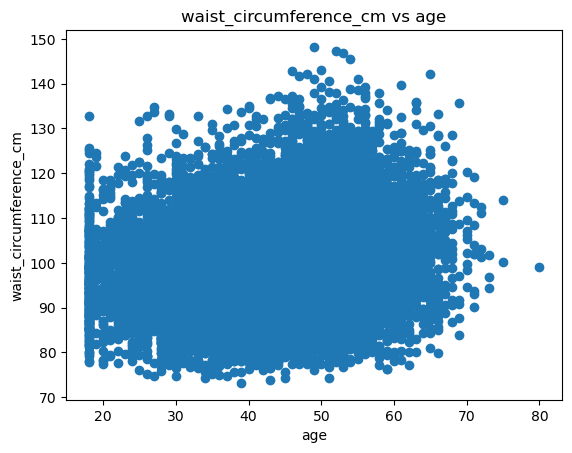

In [97]:
plt.scatter(df["age"], df["waist_circumference_cm"])
plt.xlabel("age")
plt.ylabel("waist_circumference_cm")
plt.title("waist_circumference_cm vs age")
plt.show()

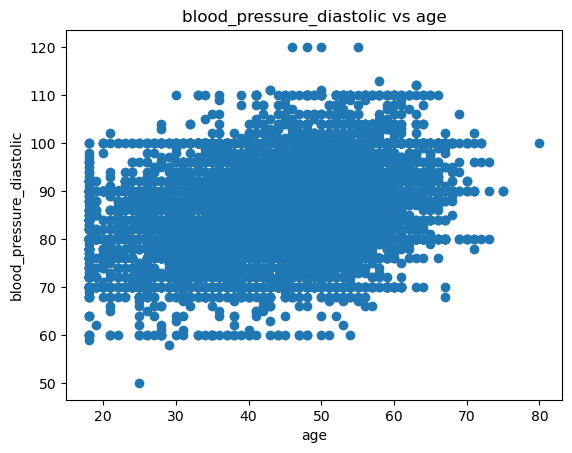

In [96]:
plt.scatter(df["age"], df["blood_pressure_diastolic"])
plt.xlabel("age")
plt.ylabel("blood_pressure_diastolic")
plt.title("blood_pressure_diastolic vs age")
plt.show()

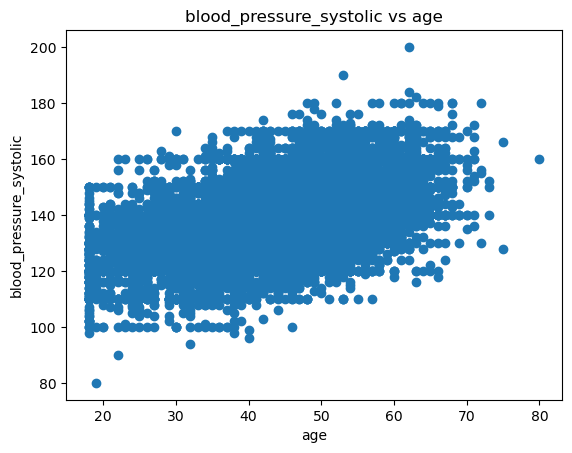

In [95]:
plt.scatter(df["age"], df["blood_pressure_systolic"])
plt.xlabel("age")
plt.ylabel("blood_pressure_systolic")
plt.title("blood_pressure_systolic vs age")
plt.show()

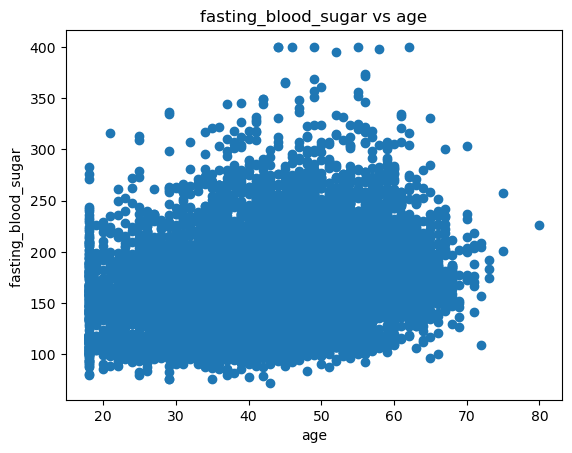

In [ ]:
plt.scatter(df["age"], df["fasting_blood_sugar"])
plt.xlabel("age")
plt.ylabel("fasting_blood_sugar ")
plt.title("fasting_blood_sugar vs age")
plt.show()

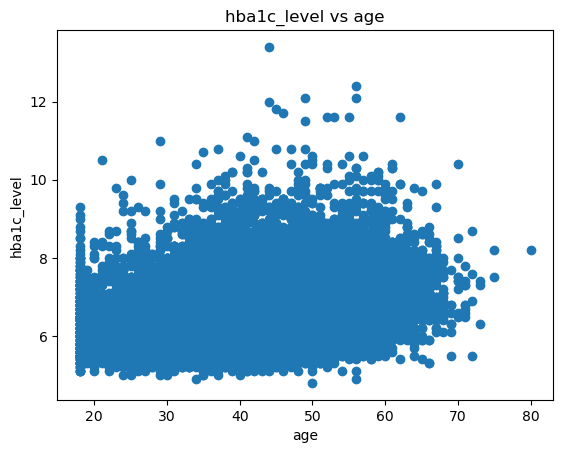

In [92]:
plt.scatter(df["age"], df["hba1c_level"])
plt.xlabel("age")
plt.ylabel("hba1c_level")
plt.title("hba1c_level vs age")
plt.show()

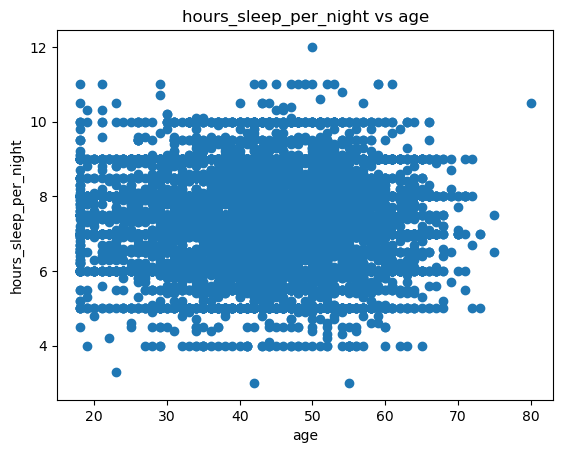

In [91]:
plt.scatter(df["age"], df["hours_sleep_per_night"])
plt.xlabel("age")
plt.ylabel("hours_sleep_per_night")
plt.title("hours_sleep_per_night vs age")
plt.show()

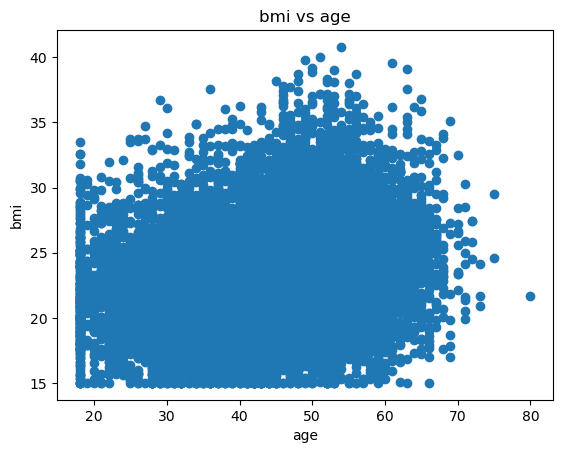

In [90]:
plt.scatter(df["age"], df["bmi"])
plt.xlabel("age")
plt.ylabel("bmi")
plt.title("bmi vs age")
plt.show()

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [243]:
gender_age = df.groupby('gender') ['age'].mean()
print(gender_age)

gender
Female    44.329946
Male      44.304410
Other     45.973856
Name: age, dtype: float64


In [242]:
gender_bmi = df.groupby('gender') ['bmi'].mean()
print(gender_bmi)

gender
Female    23.049380
Male      23.075731
Other     22.992157
Name: bmi, dtype: float64


In [241]:
gender_hours_sleep_per_night = df.groupby('gender') ['hours_sleep_per_night'].mean()
print(gender_hours_sleep_per_night)

gender
Female    7.325922
Male      7.297547
Other     7.172549
Name: hours_sleep_per_night, dtype: float64


In [240]:
gender_stress_level = df.groupby('gender') ['stress_level'].mean()
print(gender_stress_level)

gender
Female    5.935403
Male      5.940110
Other     6.267974
Name: stress_level, dtype: float64


In [239]:
gender_fasting_blood_sugar = df.groupby('gender') ['fasting_blood_sugar'].mean()
print(gender_fasting_blood_sugar)

gender
Female    168.881526
Male      168.637265
Other     172.137255
Name: fasting_blood_sugar, dtype: float64


In [238]:
gender_hba1c_level = df.groupby('gender') ['hba1c_level'].mean()
print(gender_hba1c_level)

gender
Female    6.882152
Male      6.872860
Other     6.978431
Name: hba1c_level, dtype: float64


In [237]:
gender_blood_pressure_systolic = df.groupby('gender') ['blood_pressure_systolic'].mean()
print(gender_blood_pressure_systolic)

gender
Female    139.329250
Male      139.615475
Other     141.359477
Name: blood_pressure_systolic, dtype: float64


In [236]:
gender_blood_pressure_diastolic = df.groupby('gender') ['blood_pressure_diastolic'].mean()
print(gender_blood_pressure_diastolic)

gender
Female    86.256856
Male      86.253132
Other     86.450980
Name: blood_pressure_diastolic, dtype: float64


In [235]:
gender_waist_circumference_cm = df.groupby('gender') ['waist_circumference_cm'].mean()
print(gender_waist_circumference_cm)

gender
Female     97.617597
Male      102.692732
Other      97.350980
Name: waist_circumference_cm, dtype: float64


In [234]:
city_waist_circumference_cm = df.groupby('city') ['waist_circumference_cm'].mean()
print(city_waist_circumference_cm)

city
Ahmedabad         99.895380
Bengaluru        100.170423
Bhopal           100.629323
Chennai          100.265488
Delhi            100.930915
Hyderabad         99.952323
Indore           101.229039
Jaipur           100.094418
Kanpur           100.302947
Kolkata          100.388532
Lucknow          100.321007
Mumbai           100.178689
Nagpur            99.930519
Patna             99.157292
Pune              99.698280
Surat             99.787193
Thane             99.827938
Visakhapatnam     99.977850
Name: waist_circumference_cm, dtype: float64


In [233]:
city_blood_pressure_diastolic = df.groupby('city') ['blood_pressure_diastolic'].mean()
print(city_blood_pressure_diastolic)

city
Ahmedabad        85.131858
Bengaluru        87.270358
Bhopal           85.937343
Chennai          86.888532
Delhi            86.805412
Hyderabad        86.944580
Indore           86.157205
Jaipur           85.730463
Kanpur           85.778947
Kolkata          85.481651
Lucknow          85.205689
Mumbai           86.805617
Nagpur           85.209957
Patna            85.607639
Pune             86.284392
Surat            85.358311
Thane            85.303769
Visakhapatnam    85.029316
Name: blood_pressure_diastolic, dtype: float64


In [232]:
city_blood_pressure_systolic = df.groupby('city') ['blood_pressure_systolic'].mean()
print(city_blood_pressure_systolic)

city
Ahmedabad        138.251203
Bengaluru        140.550489
Bhopal           137.907268
Chennai          140.896034
Delhi            140.670121
Hyderabad        141.502037
Indore           138.233624
Jaipur           138.940989
Kanpur           137.852632
Kolkata          137.729358
Lucknow          138.297593
Mumbai           140.563085
Nagpur           137.690476
Patna            137.572917
Pune             139.833333
Surat            137.869210
Thane            136.940133
Visakhapatnam    137.495114
Name: blood_pressure_systolic, dtype: float64


In [231]:
city_hba1c_level = df.groupby('city') ['hba1c_level'].mean()
print(city_hba1c_level)

city
Ahmedabad        6.829740
Bengaluru        6.867557
Bhopal           6.916792
Chennai          6.916292
Delhi            6.958031
Hyderabad        6.942054
Indore           6.786026
Jaipur           6.874960
Kanpur           6.817053
Kolkata          6.797362
Lucknow          6.819475
Mumbai           6.891841
Nagpur           6.800433
Patna            6.843403
Pune             6.939153
Surat            6.811717
Thane            6.883814
Visakhapatnam    6.838111
Name: hba1c_level, dtype: float64


In [230]:
city_fasting_blood_sugar = df.groupby('city') ['fasting_blood_sugar'].mean()
print(city_fasting_blood_sugar)

city
Ahmedabad        166.304139
Bengaluru        169.003257
Bhopal           170.568922
Chennai          170.804930
Delhi            172.634427
Hyderabad        171.785656
Indore           164.272926
Jaipur           169.513557
Kanpur           166.570526
Kolkata          164.544725
Lucknow          166.295405
Mumbai           169.223807
Nagpur           164.582251
Patna            164.690972
Pune             171.164021
Surat            165.874659
Thane            168.629712
Visakhapatnam    166.807818
Name: fasting_blood_sugar, dtype: float64


In [229]:
city_stress_level = df.groupby('city') ['stress_level'].mean()
print(city_stress_level)

city
Ahmedabad        5.050048
Bengaluru        6.710749
Bhopal           5.182957
Chennai          6.585209
Delhi            6.646517
Hyderabad        6.656072
Indore           4.947598
Jaipur           5.141946
Kanpur           5.058947
Kolkata          4.932339
Lucknow          5.030635
Mumbai           6.667856
Nagpur           5.090909
Patna            4.913194
Pune             6.593915
Surat            4.955041
Thane            5.115299
Visakhapatnam    4.889251
Name: stress_level, dtype: float64


In [228]:
city_hours_sleep_per_night = df.groupby('city') ['hours_sleep_per_night'].mean()
print(city_hours_sleep_per_night)

city
Ahmedabad        7.521752
Bengaluru        7.141629
Bhopal           7.522556
Chennai          7.209218
Delhi            7.204088
Hyderabad        7.141402
Indore           7.474891
Jaipur           7.434928
Kanpur           7.443368
Kolkata          7.553211
Lucknow          7.477024
Mumbai           7.142131
Nagpur           7.480519
Patna            7.489583
Pune             7.210185
Surat            7.489646
Thane            7.498448
Visakhapatnam    7.425407
Name: hours_sleep_per_night, dtype: float64


In [227]:
city_bmi = df.groupby('city') ['bmi'].mean()
print(city_bmi)

city
Ahmedabad        22.944562
Bengaluru        22.974397
Bhopal           23.344862
Chennai          23.046838
Delhi            23.337306
Hyderabad        22.993969
Indore           23.420087
Jaipur           23.062520
Kanpur           23.150947
Kolkata          23.175573
Lucknow          23.141575
Mumbai           23.050691
Nagpur           23.004978
Patna            22.682292
Pune             22.784259
Surat            22.868120
Thane            23.052106
Visakhapatnam    22.875570
Name: bmi, dtype: float64


In [226]:
city_age = df.groupby('city') ['age'].mean()
print(city_age)

city
Ahmedabad        44.610202
Bengaluru        44.483388
Bhopal           43.924812
Chennai          44.255091
Delhi            44.610248
Hyderabad        44.574572
Indore           44.609170
Jaipur           44.342903
Kanpur           44.928421
Kolkata          43.994266
Lucknow          44.177243
Mumbai           44.061525
Nagpur           44.577922
Patna            44.694444
Pune             43.568783
Surat            44.256131
Thane            44.090909
Visakhapatnam    44.446254
Name: age, dtype: float64


In [225]:
family_history_age = df.groupby('family_history_diabetes') ['age'].mean()
print(family_history_age)

family_history_diabetes
No     44.310578
Yes    44.376621
Name: age, dtype: float64


In [224]:
family_history_bmi = df.groupby('family_history_diabetes') ['bmi'].mean()
print(family_history_bmi)

family_history_diabetes
No     23.020029
Yes    23.140828
Name: bmi, dtype: float64


In [223]:
family_history_hours_sleep_per_night = df.groupby('family_history_diabetes') ['hours_sleep_per_night'].mean()
print(family_history_hours_sleep_per_night)

family_history_diabetes
No     7.302757
Yes    7.323074
Name: hours_sleep_per_night, dtype: float64


In [222]:
family_history_diabetes_stress_level = df.groupby('family_history_diabetes') ['stress_level'].mean()
print(family_history_diabetes_stress_level)

family_history_diabetes
No     5.927429
Yes    5.966819
Name: stress_level, dtype: float64


In [221]:
family_history_diabetes_fasting_blood_sugar = df.groupby('family_history_diabetes') ['fasting_blood_sugar'].mean()
print(family_history_diabetes_fasting_blood_sugar)

family_history_diabetes
No     164.366954
Yes    177.018497
Name: fasting_blood_sugar, dtype: float64


In [220]:
family_history_diabetes_hba1c_level = df.groupby('family_history_diabetes') ['hba1c_level'].mean()
print(family_history_diabetes_hba1c_level)

family_history_diabetes
No     6.791738
Yes    7.039588
Name: hba1c_level, dtype: float64


In [219]:
family_history_diabetes_blood_pressure_systolic = df.groupby('family_history_diabetes') ['blood_pressure_systolic'].mean()
print(family_history_diabetes_blood_pressure_systolic)

family_history_diabetes
No     139.323903
Yes    139.816743
Name: blood_pressure_systolic, dtype: float64


In [218]:
family_history_diabetes_blood_pressure_diastolic = df.groupby('family_history_diabetes') ['blood_pressure_diastolic'].mean()
print(family_history_diabetes_blood_pressure_diastolic)

family_history_diabetes
No     86.235855
Yes    86.296148
Name: blood_pressure_diastolic, dtype: float64


In [217]:
family_history_diabetes_waist_circumference_cm = df.groupby('family_history_diabetes') ['waist_circumference_cm'].mean()
print(family_history_diabetes_waist_circumference_cm)

family_history_diabetes
No     100.120234
Yes    100.371091
Name: waist_circumference_cm, dtype: float64


In [216]:
physical_activity_level_waist_circumference_cm = df.groupby('physical_activity_level') ['waist_circumference_cm'].mean()
print(physical_activity_level_waist_circumference_cm)

physical_activity_level
Active        94.278608
Moderate     100.038788
Sedentary    106.486081
Name: waist_circumference_cm, dtype: float64


In [215]:
physical_activity_level_blood_pressure_diastolic = df.groupby('physical_activity_level') ['blood_pressure_diastolic'].mean()
print(physical_activity_level_blood_pressure_diastolic)

physical_activity_level
Active       84.178627
Moderate     86.494949
Sedentary    88.160202
Name: blood_pressure_diastolic, dtype: float64


In [214]:
physical_activity_level_blood_pressure_systolic = df.groupby('physical_activity_level') ['blood_pressure_systolic'].mean()
print(physical_activity_level_blood_pressure_systolic)

physical_activity_level
Active       135.758431
Moderate     139.806465
Sedentary    143.036970
Name: blood_pressure_systolic, dtype: float64


In [213]:
physical_activity_level_hba1c_level = df.groupby('physical_activity_level') ['hba1c_level'].mean()
print(physical_activity_level_hba1c_level)

physical_activity_level
Active       6.712000
Moderate     6.899495
Sedentary    7.028707
Name: hba1c_level, dtype: float64


In [212]:
physical_activity_level_fasting_blood_sugar = df.groupby('physical_activity_level') ['fasting_blood_sugar'].mean()
print(physical_activity_level_fasting_blood_sugar)

physical_activity_level
Active       160.618824
Moderate     170.016364
Sedentary    175.982222
Name: fasting_blood_sugar, dtype: float64


In [211]:
physical_activity_level_stress_level = df.groupby('physical_activity_level') ['stress_level'].mean()
print(physical_activity_level_stress_level)

physical_activity_level
Active       5.549608
Moderate     6.125859
Sedentary    6.160000
Name: stress_level, dtype: float64


In [210]:
physical_activity_level_hours_sleep_per_night = df.groupby('physical_activity_level') ['hours_sleep_per_night'].mean()
print(physical_activity_level_hours_sleep_per_night)

physical_activity_level
Active       7.395098
Moderate     7.274384
Sedentary    7.257515
Name: hours_sleep_per_night, dtype: float64


In [209]:
physical_activity_level_bmi = df.groupby('physical_activity_level') ['bmi'].mean()
print(physical_activity_level_bmi)

physical_activity_level
Active       20.718824
Moderate     22.947636
Sedentary    25.591333
Name: bmi, dtype: float64


In [208]:
physical_activity_level_age = df.groupby('physical_activity_level') ['age'].mean()
print(physical_activity_level_age)

physical_activity_level
Active       41.859020
Moderate     44.398182
Sedentary    46.818788
Name: age, dtype: float64


In [207]:
diet_type_age = df.groupby('diet_type') ['age'].mean()
print(diet_type_age)

diet_type
Non-Vegetarian    44.200488
Pescatarian       44.438202
Vegan             44.793706
Vegetarian        44.484030
Name: age, dtype: float64


In [206]:
diet_type_bmi = df.groupby('diet_type') ['bmi'].mean()
print(diet_type_bmi)

diet_type
Non-Vegetarian    23.000659
Pescatarian       23.032135
Vegan             23.104196
Vegetarian        23.145604
Name: bmi, dtype: float64


In [205]:
diet_type_hours_sleep_per_night = df.groupby('diet_type') ['hours_sleep_per_night'].mean()
print(diet_type_hours_sleep_per_night)

diet_type
Non-Vegetarian    7.322746
Pescatarian       7.302247
Vegan             7.353147
Vegetarian        7.290994
Name: hours_sleep_per_night, dtype: float64


In [204]:
diet_type_stress_level = df.groupby('diet_type') ['stress_level'].mean()
print(diet_type_stress_level)

diet_type
Non-Vegetarian    5.947529
Pescatarian       5.874157
Vegan             6.020979
Vegetarian        5.933816
Name: stress_level, dtype: float64


In [203]:
diet_type_fasting_blood_sugar = df.groupby('diet_type') ['fasting_blood_sugar'].mean()
print(diet_type_fasting_blood_sugar)

diet_type
Non-Vegetarian    168.454790
Pescatarian       169.049438
Vegan             174.412587
Vegetarian        168.958347
Name: fasting_blood_sugar, dtype: float64


In [202]:
diet_type_hba1c_level = df.groupby('diet_type') ['hba1c_level'].mean()
print(diet_type_hba1c_level)

diet_type
Non-Vegetarian    6.873435
Pescatarian       6.882022
Vegan             7.010839
Vegetarian        6.878564
Name: hba1c_level, dtype: float64


In [201]:
diet_type_blood_pressure_systolic = df.groupby('diet_type') ['blood_pressure_systolic'].mean()
print(diet_type_blood_pressure_systolic)

diet_type
Non-Vegetarian    139.294448
Pescatarian       139.712360
Vegan             139.059441
Vegetarian        139.773131
Name: blood_pressure_systolic, dtype: float64


In [200]:
diet_type_blood_pressure_diastolic = df.groupby('diet_type') ['blood_pressure_diastolic'].mean()
print(diet_type_blood_pressure_diastolic)

diet_type
Non-Vegetarian    86.184991
Pescatarian       86.316854
Vegan             86.846154
Vegetarian        86.321864
Name: blood_pressure_diastolic, dtype: float64


In [198]:
smoking_status_waist_circumference_cm = df.groupby('smoking_status') ['waist_circumference_cm'].mean()
print(smoking_status_waist_circumference_cm)

smoking_status
Current    100.317379
Former     100.384347
Never      100.153121
Name: waist_circumference_cm, dtype: float64


In [197]:
smoking_status_blood_pressure_diastolic = df.groupby('smoking_status') ['blood_pressure_diastolic'].mean()
print(smoking_status_blood_pressure_diastolic)

smoking_status
Current    86.271215
Former     86.401914
Never      86.232934
Name: blood_pressure_diastolic, dtype: float64


In [196]:
smoking_status_blood_pressure_systolic = df.groupby('smoking_status') ['blood_pressure_systolic'].mean()
print(smoking_status_blood_pressure_systolic)

smoking_status
Current    139.742702
Former     139.616541
Never      139.411009
Name: blood_pressure_systolic, dtype: float64


In [195]:
smoking_status_hba1c_level = df.groupby('smoking_status') ['hba1c_level'].mean()
print(smoking_status_hba1c_level)

smoking_status
Current    6.869314
Former     6.892481
Never      6.878963
Name: hba1c_level, dtype: float64


In [194]:
smoking_status_fasting_blood_sugar = df.groupby('smoking_status') ['fasting_blood_sugar'].mean()
print(smoking_status_fasting_blood_sugar)

smoking_status
Current    168.397488
Former     168.956254
Never      168.876121
Name: fasting_blood_sugar, dtype: float64


In [193]:
smoking_status_stress_level = df.groupby('smoking_status') ['stress_level'].mean()
print(smoking_status_stress_level)

smoking_status
Current    5.890699
Former     5.998633
Never      5.947314
Name: stress_level, dtype: float64


In [192]:
smoking_status_hours_sleep_per_night = df.groupby('smoking_status') ['hours_sleep_per_night'].mean()
print(smoking_status_hours_sleep_per_night)

smoking_status
Current    7.310862
Former     7.313055
Never      7.309140
Name: hours_sleep_per_night, dtype: float64


In [191]:
smoking_status_bmi = df.groupby('smoking_status') ['bmi'].mean()
print(smoking_status_bmi)

smoking_status
Current    23.137984
Former     23.166576
Never      23.026787
Name: bmi, dtype: float64


In [190]:
smoking_status_age = df.groupby('smoking_status') ['age'].mean()
print(smoking_status_age)

smoking_status
Current    44.400204
Former     44.496924
Never      44.292607
Name: age, dtype: float64


In [ ]:
alcohol_consumption_age = df.groupby('alcohol_consumption') ['age'].mean()
print(alcohol_consumption_age)

In [189]:
alcohol_consumption_age = df.groupby('alcohol_consumption') ['age'].mean()
print(alcohol_consumption_age)

alcohol_consumption
Never         44.129274
Occasional    44.113986
Regular       44.192273
Unknown       44.938226
Name: age, dtype: float64


In [188]:
alcohol_consumption_bmi = df.groupby('alcohol_consumption') ['bmi'].mean()
print(alcohol_consumption_bmi)

alcohol_consumption
Never         23.029968
Occasional    23.171135
Regular       22.929470
Unknown       23.020301
Name: bmi, dtype: float64


In [187]:
alcohol_consumption_hours_sleep_per_night = df.groupby('alcohol_consumption') ['hours_sleep_per_night'].mean()
print(alcohol_consumption_hours_sleep_per_night)

alcohol_consumption
Never         7.304131
Occasional    7.313272
Regular       7.314376
Unknown       7.312988
Name: hours_sleep_per_night, dtype: float64


In [186]:
alcohol_consumption_stress_level = df.groupby('alcohol_consumption') ['stress_level'].mean()
print(alcohol_consumption_stress_level)

alcohol_consumption
Never         5.967593
Occasional    5.900290
Regular       5.966757
Unknown       5.942978
Name: stress_level, dtype: float64


In [185]:
alcohol_consumption_fasting_blood_sugar = df.groupby('alcohol_consumption') ['fasting_blood_sugar'].mean()
print(alcohol_consumption_fasting_blood_sugar)

alcohol_consumption
Never         168.434829
Occasional    169.008700
Regular       169.568733
Unknown       168.828669
Name: fasting_blood_sugar, dtype: float64


In [184]:
alcohol_consumption_hba1c_level = df.groupby('alcohol_consumption') ['hba1c_level'].mean()
print(alcohol_consumption_hba1c_level)

alcohol_consumption
Never         6.867521
Occasional    6.889784
Regular       6.885085
Unknown       6.879039
Name: hba1c_level, dtype: float64


In [183]:
alcohol_consumption_blood_pressure_systolic = df.groupby('alcohol_consumption') ['blood_pressure_systolic'].mean()
print(alcohol_consumption_blood_pressure_systolic)

alcohol_consumption
Never         139.450499
Occasional    139.433638
Regular       139.114106
Unknown       139.750264
Name: blood_pressure_systolic, dtype: float64


In [182]:
alcohol_consumption_blood_pressure_diastolic = df.groupby('alcohol_consumption') ['blood_pressure_diastolic'].mean()
print(alcohol_consumption_blood_pressure_diastolic)

alcohol_consumption
Never         86.219907
Occasional    86.183582
Regular       86.326146
Unknown       86.378300
Name: blood_pressure_diastolic, dtype: float64


In [181]:
alcohol_consumption_waist_circumference_cm = df.groupby('alcohol_consumption') ['waist_circumference_cm'].mean()
print(alcohol_consumption_waist_circumference_cm)

alcohol_consumption
Never         100.601976
Occasional    101.065760
Regular       100.349236
Unknown        98.567001
Name: waist_circumference_cm, dtype: float64


In [180]:
income_bracket_waist_circumference_cm = df.groupby('income_bracket') ['waist_circumference_cm'].mean()
print(income_bracket_waist_circumference_cm)

income_bracket
High      101.023569
Low        99.641322
Middle    100.020616
Never     100.537797
Name: waist_circumference_cm, dtype: float64


In [179]:
income_bracket_blood_pressure_diastolic = df.groupby('income_bracket') ['blood_pressure_diastolic'].mean()
print(income_bracket_blood_pressure_diastolic)

income_bracket
High      87.329084
Low       85.792503
Middle    85.883094
Never     86.652268
Name: blood_pressure_diastolic, dtype: float64


In [178]:
income_bracket_blood_pressure_systolic = df.groupby('income_bracket') ['blood_pressure_systolic'].mean()
print(income_bracket_blood_pressure_systolic)

income_bracket
High      141.302549
Low       138.538076
Middle    138.998084
Never     139.369330
Name: blood_pressure_systolic, dtype: float64


In [177]:
income_bracket_hba1c_level = df.groupby('income_bracket') ['hba1c_level'].mean()
print(income_bracket_hba1c_level)

income_bracket
High      6.941025
Low       6.843388
Middle    6.858084
Never     6.934773
Name: hba1c_level, dtype: float64


In [176]:
income_bracket_fasting_blood_sugar = df.groupby('income_bracket') ['fasting_blood_sugar'].mean()
print(income_bracket_fasting_blood_sugar)

income_bracket
High      171.770552
Low       166.697757
Middle    168.015195
Never     171.576674
Name: fasting_blood_sugar, dtype: float64


In [175]:
income_bracket_stress_level = df.groupby('income_bracket') ['stress_level'].mean()
print(income_bracket_stress_level)

income_bracket
High      6.946150
Low       5.389315
Middle    5.670637
Never     5.904968
Name: stress_level, dtype: float64


In [174]:
income_bracket_hours_sleep_per_night = df.groupby('income_bracket') ['hours_sleep_per_night'].mean()
print(income_bracket_hours_sleep_per_night)

income_bracket
High      7.100390
Low       7.424941
Middle    7.367146
Never     7.303024
Name: hours_sleep_per_night, dtype: float64


In [173]:
income_bracket_bmi = df.groupby('income_bracket') ['bmi'].mean()
print(income_bracket_bmi)

income_bracket
High      23.390088
Low       22.842090
Middle    22.974880
Never     23.330238
Name: bmi, dtype: float64


In [172]:
income_bracket_age = df.groupby('income_bracket') ['age'].mean()
print(income_bracket_age)

income_bracket
High      44.293704
Low       44.077037
Middle    44.448734
Never     44.727862
Name: age, dtype: float64


In [171]:
diabetes_risk_age = df.groupby('diabetes_risk') ['age'].mean()
print(diabetes_risk_age)

diabetes_risk
High        49.169333
Low         41.872222
Moderate    47.339733
Name: age, dtype: float64


In [170]:
diabetes_risk_bmi = df.groupby('diabetes_risk') ['bmi'].mean()
print(diabetes_risk_bmi)

diabetes_risk
High        25.108533
Low         22.133200
Moderate    24.064240
Name: bmi, dtype: float64


In [169]:
diabetes_risk_hours_sleep_per_night = df.groupby('diabetes_risk') ['hours_sleep_per_night'].mean()
print(diabetes_risk_hours_sleep_per_night)

diabetes_risk
High        7.227200
Low         7.348433
Moderate    7.266880
Name: hours_sleep_per_night, dtype: float64


In [168]:
diabetes_risk_stress_level = df.groupby('diabetes_risk') ['stress_level'].mean()
print(diabetes_risk_stress_level)

diabetes_risk
High        6.267111
Low         5.758444
Moderate    6.184267
Name: stress_level, dtype: float64


In [167]:
diabetes_risk_fasting_blood_sugar = df.groupby('diabetes_risk') ['fasting_blood_sugar'].mean()
print(diabetes_risk_fasting_blood_sugar)

diabetes_risk
High        226.540444
Low         148.299444
Moderate    183.316800
Name: fasting_blood_sugar, dtype: float64


In [166]:
diabetes_risk_hba1c_level = df.groupby('diabetes_risk') ['hba1c_level'].mean()
print(diabetes_risk_hba1c_level)

diabetes_risk
High        8.136133
Low         6.429656
Moderate    7.200693
Name: hba1c_level, dtype: float64


In [165]:
diabetes_risk_blood_pressure_systolic = df.groupby('diabetes_risk') ['blood_pressure_systolic'].mean()
print(diabetes_risk_blood_pressure_systolic)

diabetes_risk
High        144.045778
Low         137.321778
Moderate    141.985067
Name: blood_pressure_systolic, dtype: float64


In [164]:
diabetes_risk_blood_pressure_diastolic = df.groupby('diabetes_risk') ['blood_pressure_diastolic'].mean()
print(diabetes_risk_blood_pressure_diastolic)

diabetes_risk
High        88.564444
Low         85.108889
Moderate    87.627733
Name: blood_pressure_diastolic, dtype: float64


In [163]:
diabetes_risk_waist_circumference_cm = df.groupby('diabetes_risk') ['waist_circumference_cm'].mean()
print(diabetes_risk_waist_circumference_cm)

diabetes_risk
High        105.246267
Low          97.916744
Moderate    102.683787
Name: waist_circumference_cm, dtype: float64


In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [248]:
diabetes_risk=df.groupby("diabetes_risk")[["age","bmi","hours_sleep_per_night","stress_level","fasting_blood_sugar","hba1c_level",
 "blood_pressure_systolic", "blood_pressure_diastolic","waist_circumference_cm"]].agg(["max","min","mean"])
diabetes_risk.T

diabetes_risk                        High         Low    Moderate
age                      max    80.000000   73.000000   73.000000
                         min    18.000000   18.000000   18.000000
                         mean   49.169333   41.872222   47.339733
bmi                      max    40.800000   40.000000   39.600000
                         min    15.000000   15.000000   15.000000
                         mean   25.108533   22.133200   24.064240
hours_sleep_per_night    max    11.000000   11.000000   12.000000
                         min     3.000000    3.000000    4.000000
                         mean    7.227200    7.348433    7.266880
stress_level             max    10.000000   10.000000   10.000000
                         min     1.000000    1.000000    1.000000
                         mean    6.267111    5.758444    6.184267
fasting_blood_sugar      max   400.000000  236.000000  258.000000
                         min   150.000000   72.000000  118.000000
                         mean  226.540444  148.299444  183.316800
hba1c_level              max    13.400000    8.600000    9.000000
                         min     6.400000    4.800000    5.800000
                         mean    8.136133    6.429656    7.200693
blood_pressure_systolic  max   184.000000  200.000000  182.000000
                         min   100.000000   80.000000  100.000000
                         mean  144.045778  137.321778  141.985067
blood_pressure_diastolic max   120.000000  120.000000  120.000000
                         min    60.000000   58.000000   50.000000
                         mean   88.564444   85.108889   87.627733
waist_circumference_cm   max   148.200000  142.200000  142.900000
                         min    76.700000   73.800000   73.200000
                         mean  105.246267   97.916744  102.683787

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

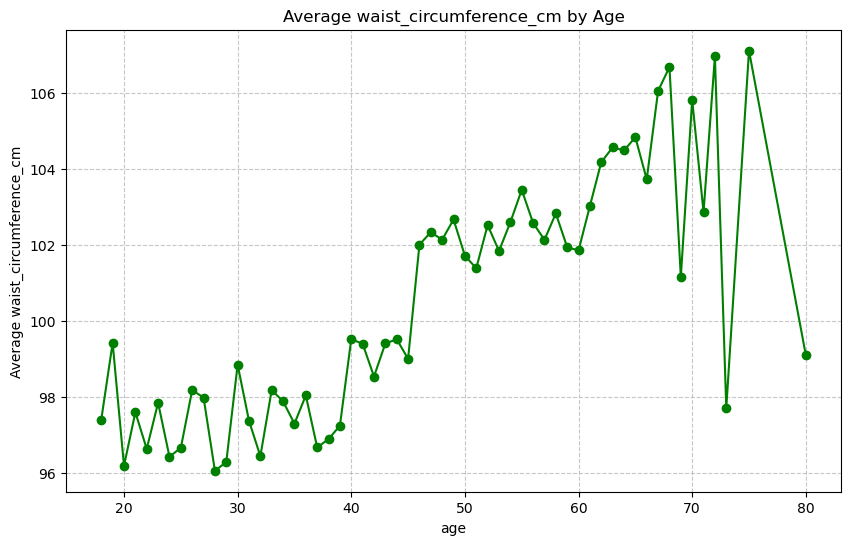

In [13]:
avg_waist_circumference_cm_by_age=df.groupby('age')['waist_circumference_cm'].mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_waist_circumference_cm_by_age.index, avg_waist_circumference_cm_by_age.values, marker='o', linestyle='-', color='green')
plt.title('Average waist_circumference_cm by Age')
plt.xlabel('age')
plt.ylabel('Average waist_circumference_cm')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

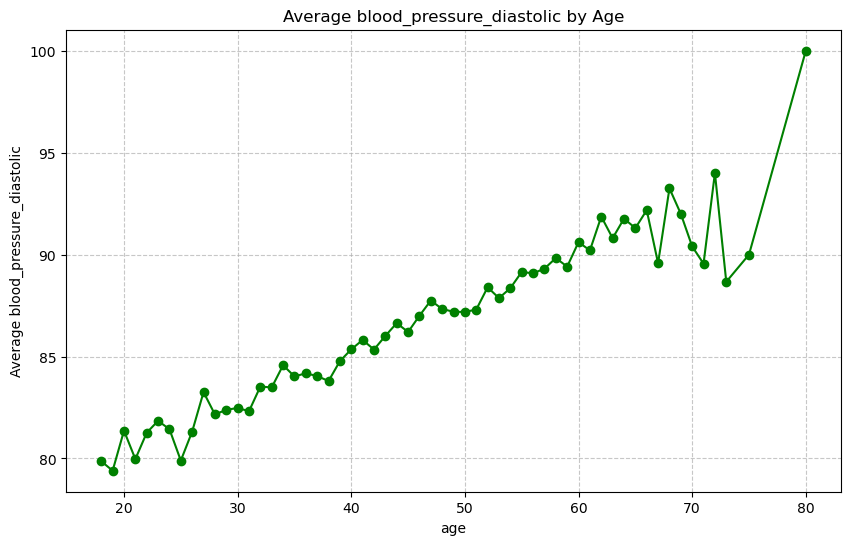

In [12]:
avg_blood_pressure_diastolic_by_age=df.groupby('age')['blood_pressure_diastolic'].mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_blood_pressure_diastolic_by_age.index, avg_blood_pressure_diastolic_by_age.values, marker='o', linestyle='-', color='green')
plt.title('Average blood_pressure_diastolic by Age')
plt.xlabel('age')
plt.ylabel('Average blood_pressure_diastolic')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

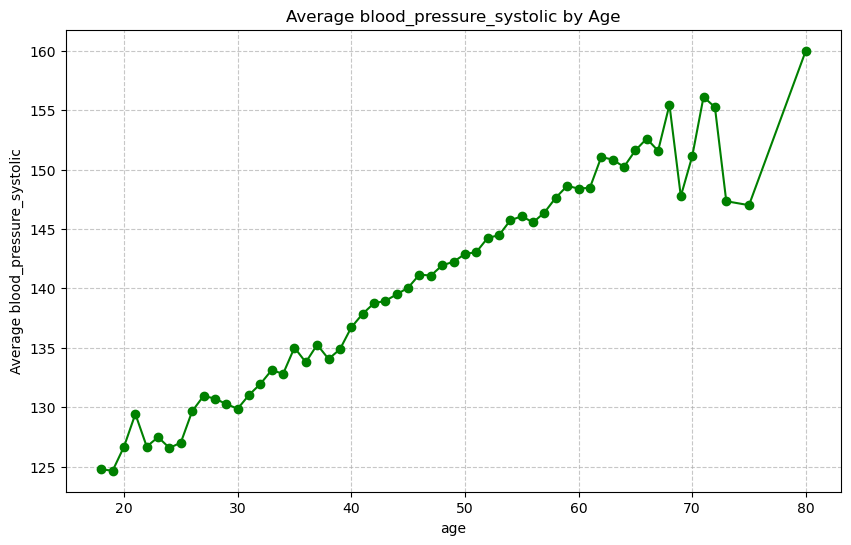

In [11]:
avg_blood_pressure_systolic_by_age=df.groupby('age')['blood_pressure_systolic'].mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_blood_pressure_systolic_by_age.index, avg_blood_pressure_systolic_by_age.values, marker='o', linestyle='-', color='green')
plt.title('Average blood_pressure_systolic by Age')
plt.xlabel('age')
plt.ylabel('Average blood_pressure_systolic')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

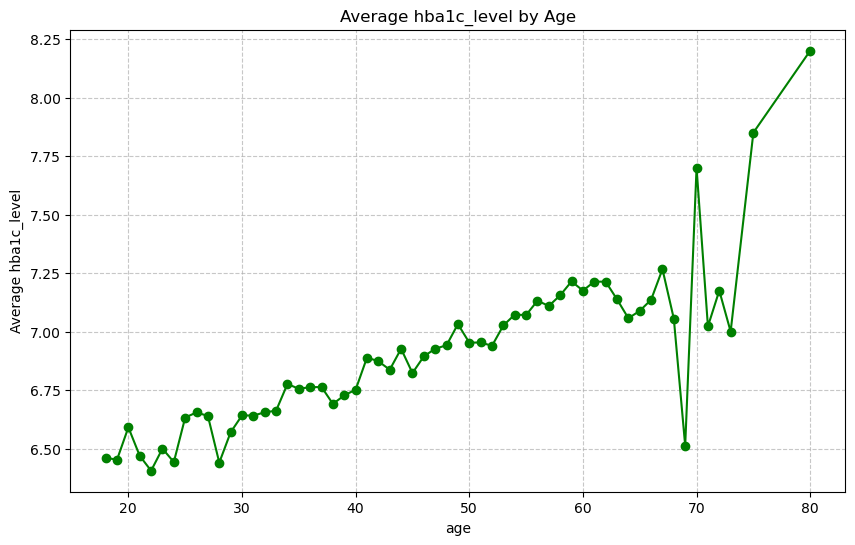

In [10]:
avg_hba1c_level_by_age=df.groupby('age')['hba1c_level'].mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_hba1c_level_by_age.index, avg_hba1c_level_by_age.values, marker='o', linestyle='-', color='green')
plt.title('Average hba1c_level by Age')
plt.xlabel('age')
plt.ylabel('Average hba1c_level')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

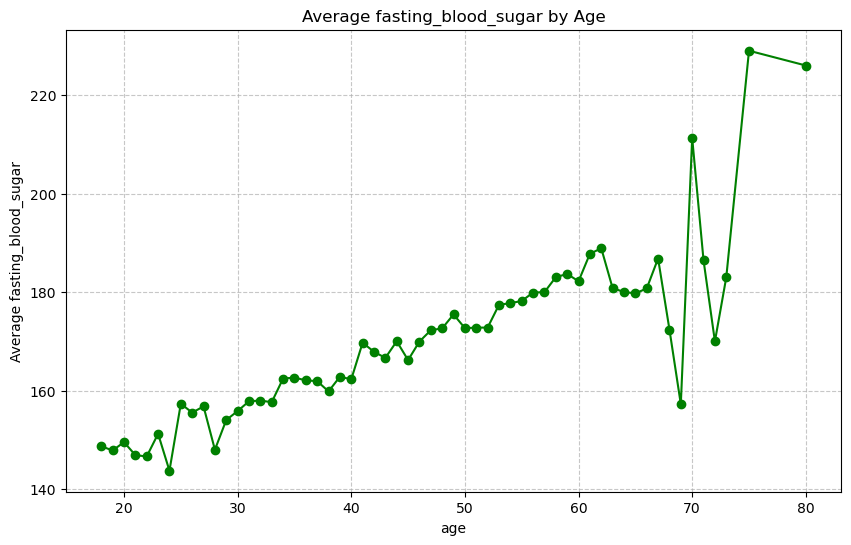

In [9]:
avg_fasting_blood_sugar_by_age=df.groupby('age')['fasting_blood_sugar'].mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_fasting_blood_sugar_by_age.index, avg_fasting_blood_sugar_by_age.values, marker='o', linestyle='-', color='green')
plt.title('Average fasting_blood_sugar by Age')
plt.xlabel('age')
plt.ylabel('Average fasting_blood_sugar')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

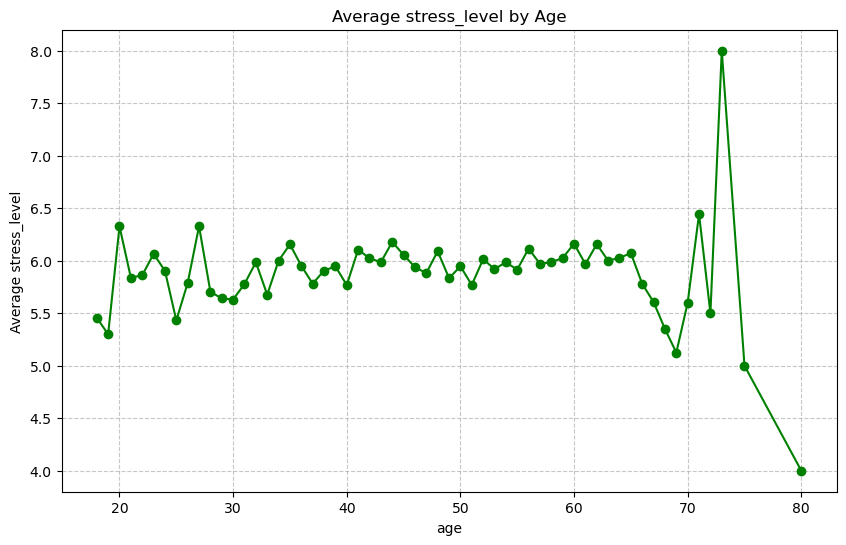

In [8]:
avg_stress_level_by_age=df.groupby('age')['stress_level'].mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_stress_level_by_age.index, avg_stress_level_by_age.values, marker='o', linestyle='-', color='green')
plt.title('Average stress_level by Age')
plt.xlabel('age')
plt.ylabel('Average stress_level')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

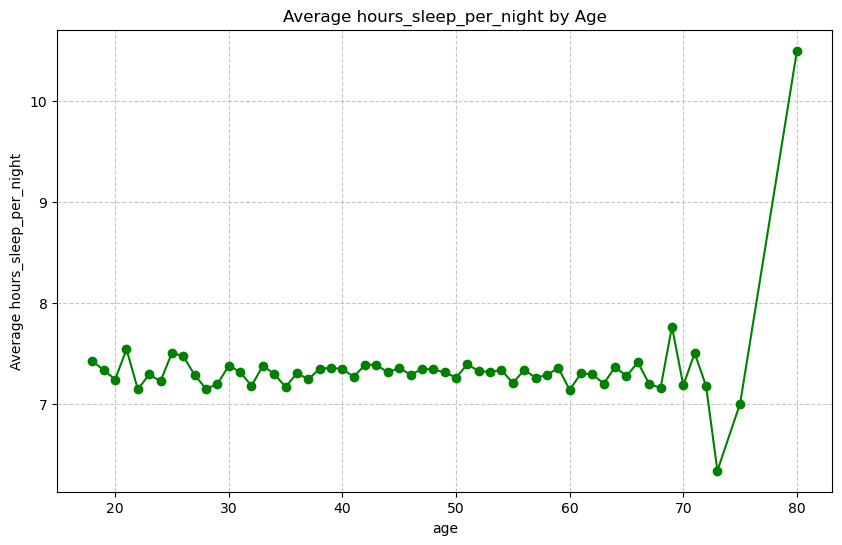

In [7]:
avg_hours_sleep_per_night_by_age=df.groupby('age')['hours_sleep_per_night'].mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_hours_sleep_per_night_by_age.index, avg_hours_sleep_per_night_by_age.values, marker='o', linestyle='-', color='green')
plt.title('Average hours_sleep_per_night by Age')
plt.xlabel('age')
plt.ylabel('Average hours_sleep_per_night')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

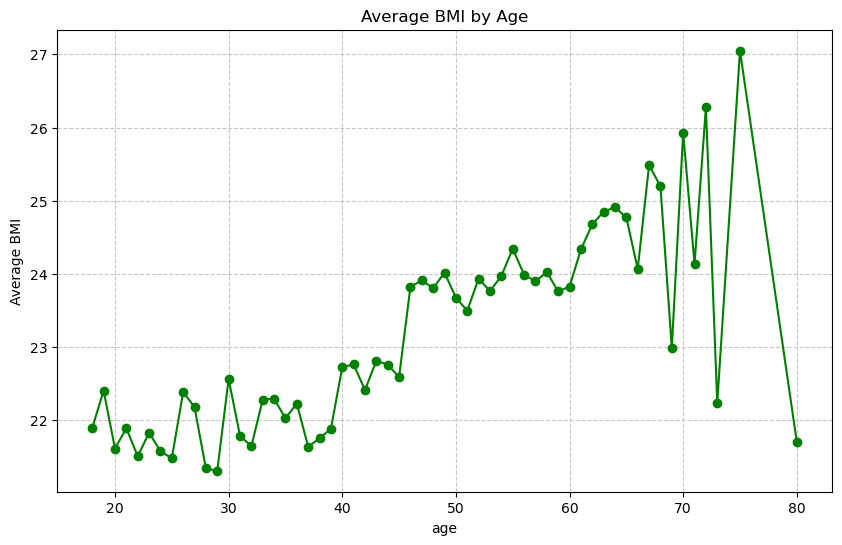

In [6]:
avg_bmi_by_age = df.groupby('age')['bmi'].mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_bmi_by_age.index, avg_bmi_by_age.values, marker='o', linestyle='-', color='green')
plt.title('Average BMI by Age')
plt.xlabel('age')
plt.ylabel('Average BMI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

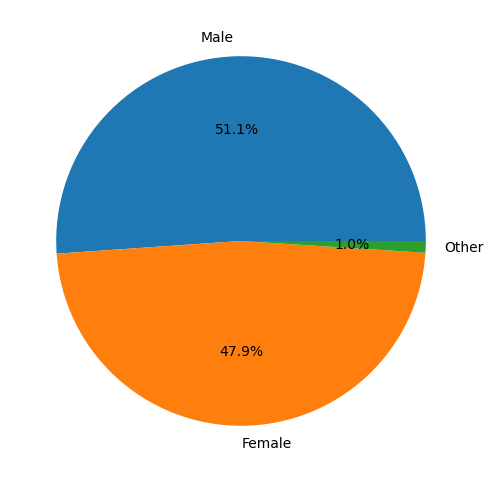

In [27]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(12, 6)) 
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.show()

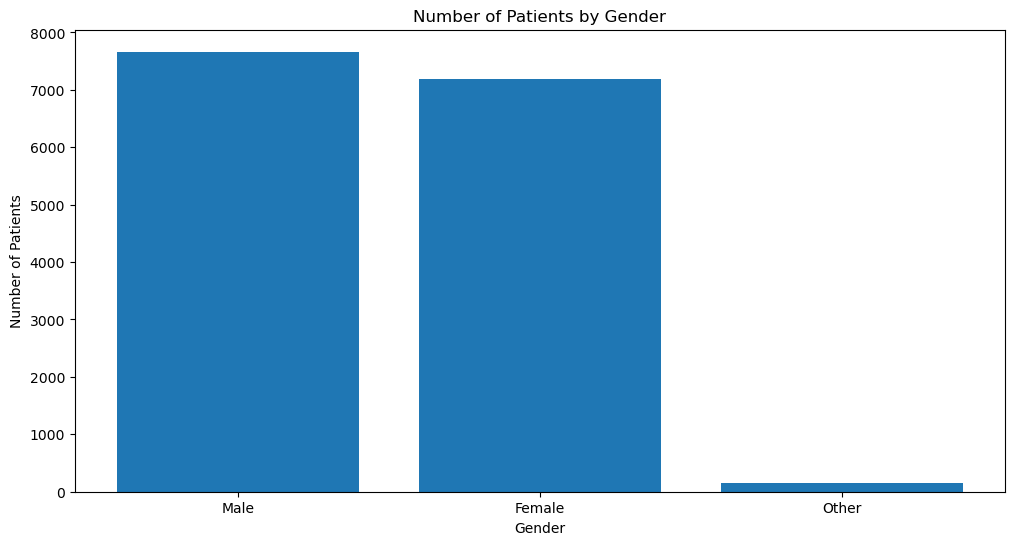

In [29]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Number of Patients by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

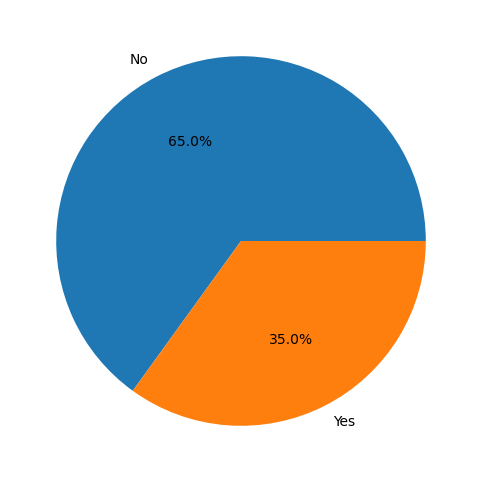

In [25]:
family_history_diabetes_counts = df["family_history_diabetes"].value_counts()

plt.figure(figsize=(12, 6)) 
plt.pie(family_history_diabetes_counts, labels=family_history_diabetes_counts.index, autopct='%1.1f%%')
plt.show()

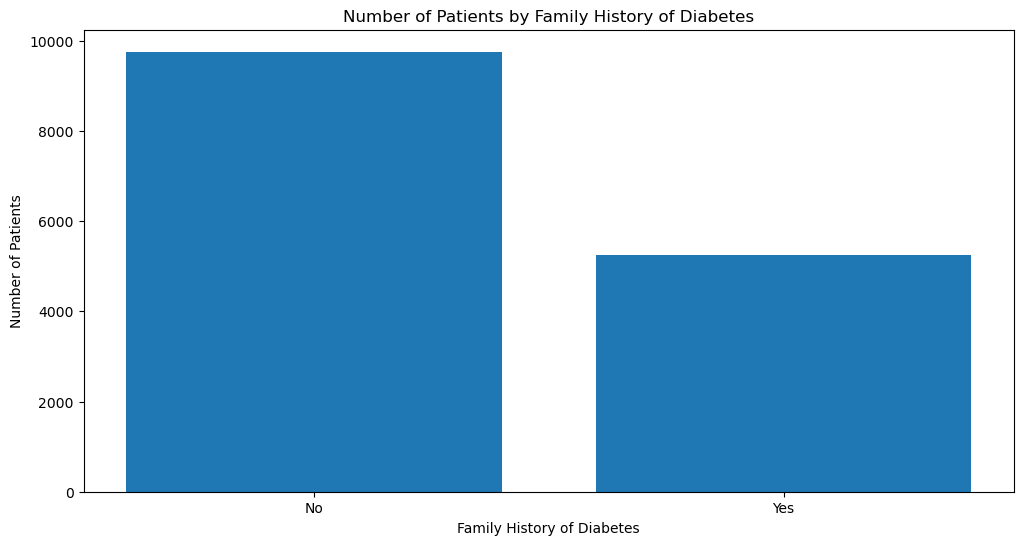

In [30]:
family_history_diabetes_counts = df["family_history_diabetes"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(family_history_diabetes_counts.index, family_history_diabetes_counts.values)
plt.title("Number of Patients by Family History of Diabetes")
plt.xlabel("Family History of Diabetes")
plt.ylabel("Number of Patients")
plt.show()

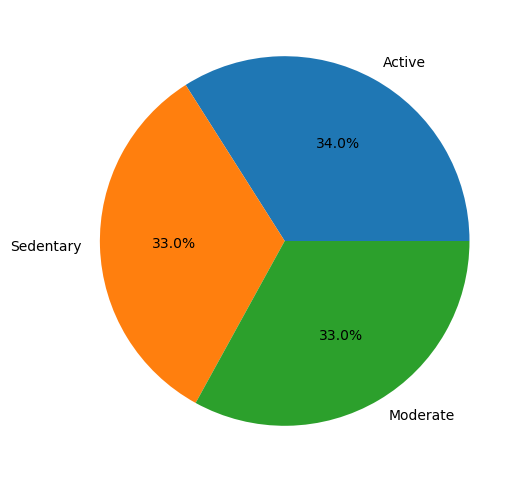

In [24]:
physical_activity_level_counts = df["physical_activity_level"].value_counts()

plt.figure(figsize=(12, 6)) 
plt.pie(physical_activity_level_counts, labels=physical_activity_level_counts.index, autopct='%1.1f%%')
plt.show()

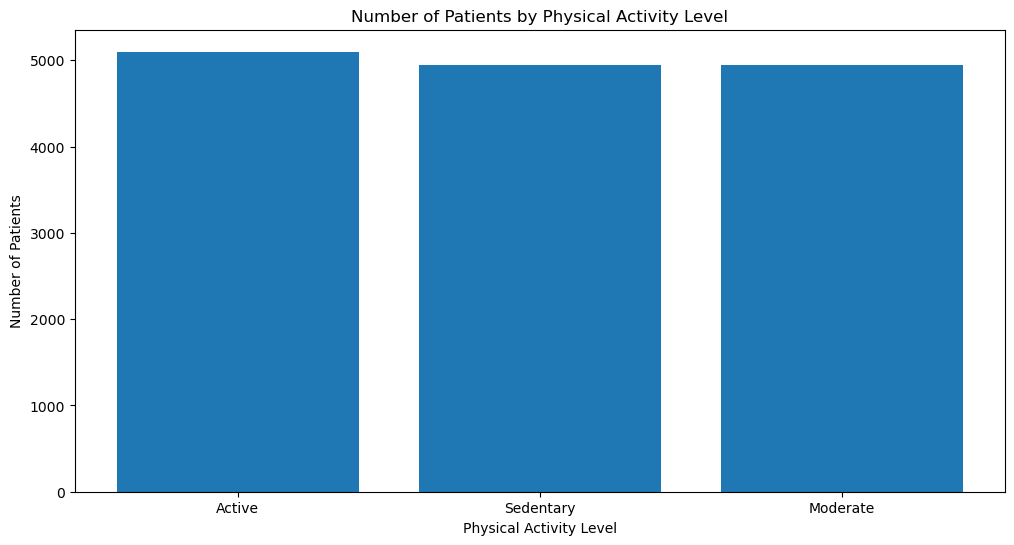

In [31]:
physical_activity_level_counts = df["physical_activity_level"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(physical_activity_level_counts.index, physical_activity_level_counts.values)
plt.title("Number of Patients by Physical Activity Level")
plt.xlabel("Physical Activity Level")
plt.ylabel("Number of Patients")
plt.show()

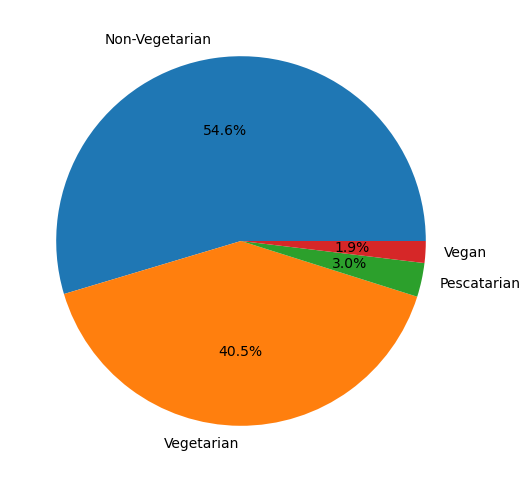

In [23]:
diet_type_counts = df["diet_type"].value_counts()

plt.figure(figsize=(12, 6)) 
plt.pie(diet_type_counts, labels=diet_type_counts.index, autopct='%1.1f%%')
plt.show()

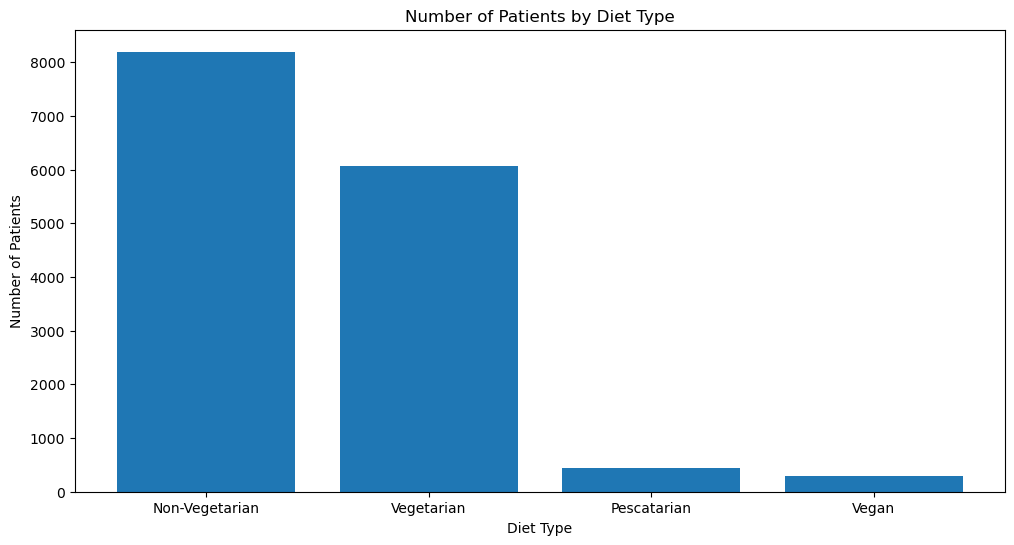

In [32]:
diet_type_counts = df["diet_type"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(diet_type_counts.index, diet_type_counts.values)
plt.title("Number of Patients by Diet Type")
plt.xlabel("Diet Type")
plt.ylabel("Number of Patients")
plt.show()

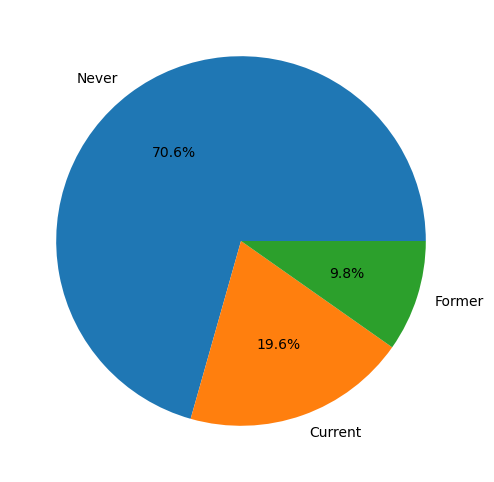

In [22]:
smoking_status_counts = df["smoking_status"].value_counts()

plt.figure(figsize=(12, 6)) 
plt.pie(smoking_status_counts, labels=smoking_status_counts.index, autopct='%1.1f%%')
plt.show()

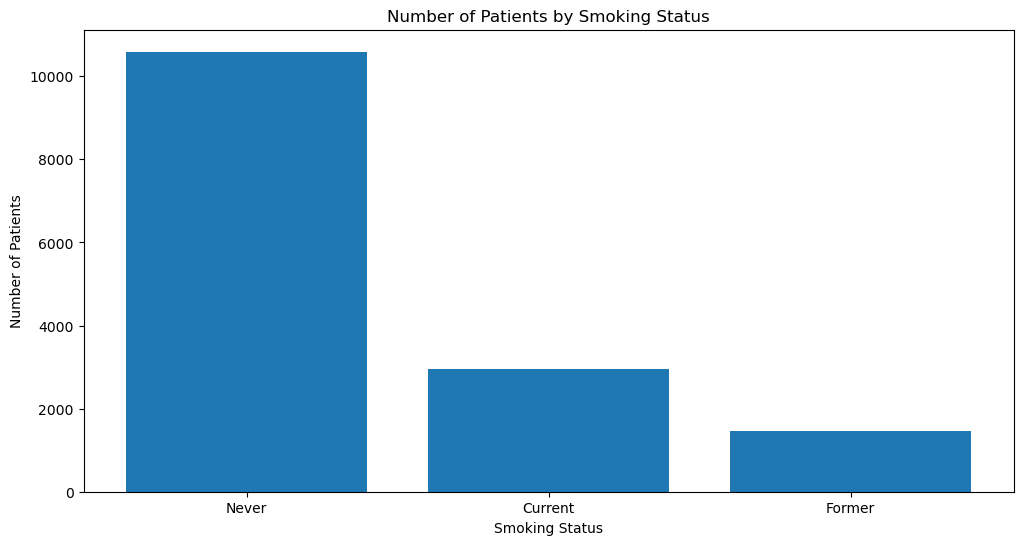

In [33]:
smoking_status_counts = df["smoking_status"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(smoking_status_counts.index, smoking_status_counts.values)
plt.title("Number of Patients by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")
plt.show()

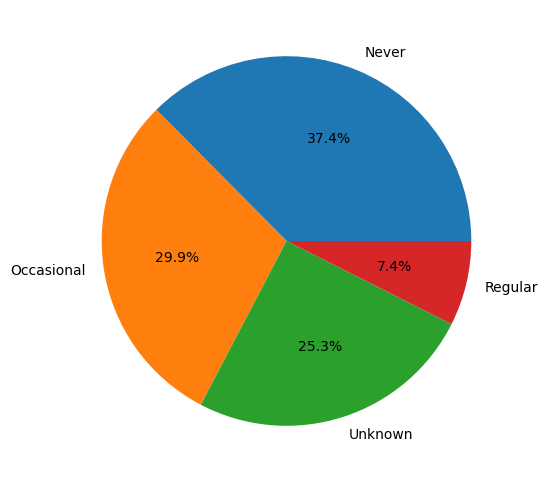

In [21]:
alcohol_consumption_counts = df["alcohol_consumption"].value_counts()

plt.figure(figsize=(12, 6)) 
plt.pie(alcohol_consumption_counts, labels=alcohol_consumption_counts.index, autopct='%1.1f%%')
plt.show()

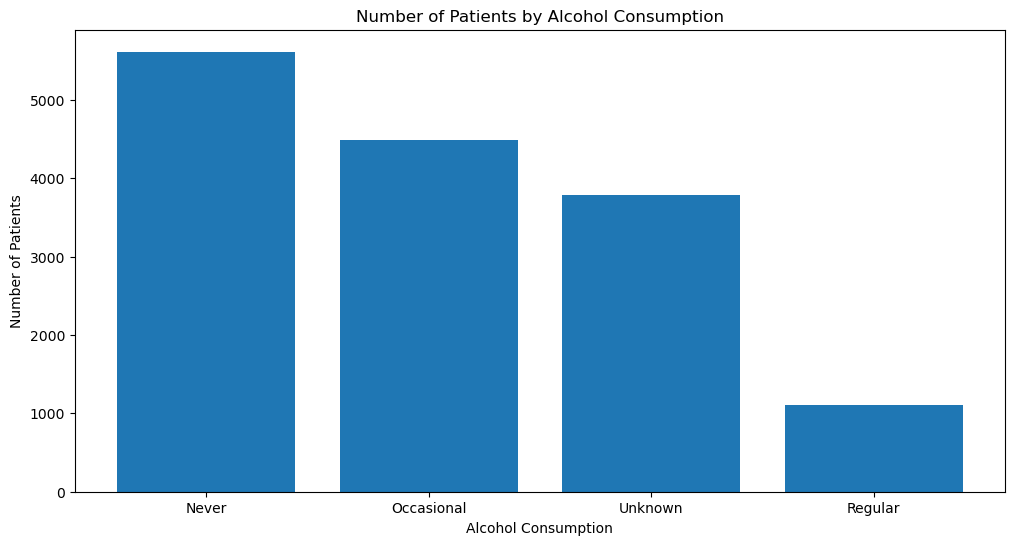

In [34]:
alcohol_consumption_counts = df["alcohol_consumption"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(alcohol_consumption_counts.index, alcohol_consumption_counts.values)
plt.title("Number of Patients by Alcohol Consumption")
plt.xlabel("Alcohol Consumption")
plt.ylabel("Number of Patients")
plt.show()

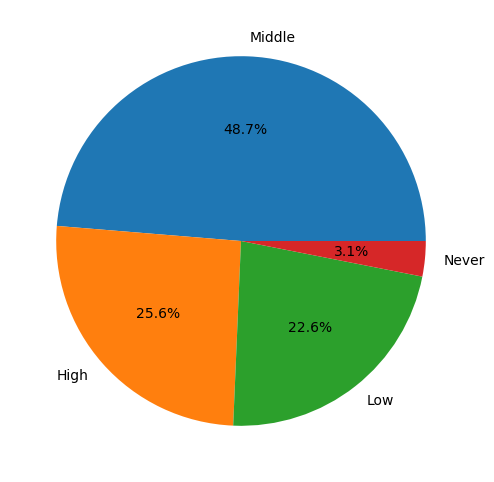

In [16]:
income_bracket_counts = df["income_bracket"].value_counts()

plt.figure(figsize=(12, 6)) 
plt.pie(income_bracket_counts, labels=income_bracket_counts.index, autopct='%1.1f%%')
plt.show()

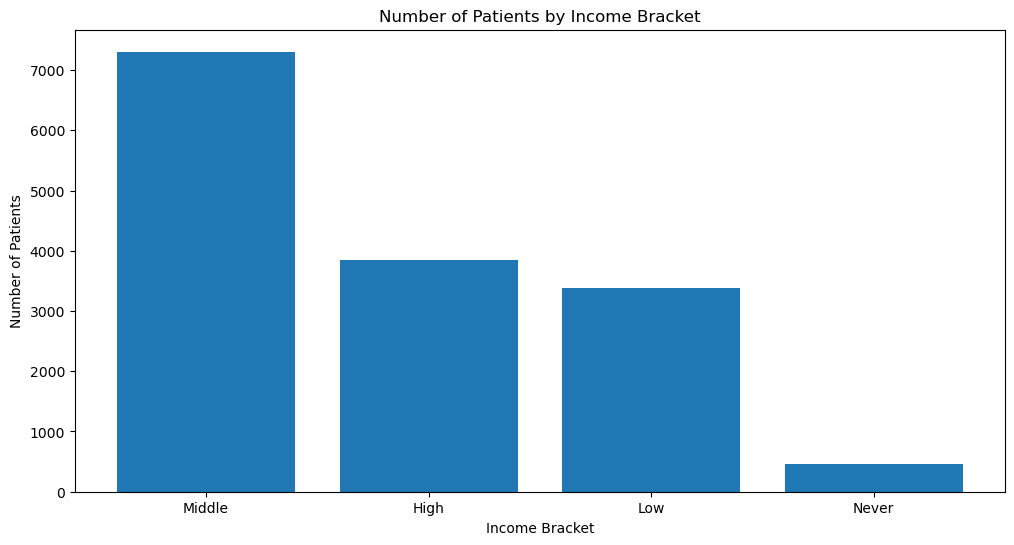

In [35]:
income_bracket_counts = df["income_bracket"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(income_bracket_counts.index, income_bracket_counts.values)
plt.title("Number of Patients by Income Bracket")
plt.xlabel("Income Bracket")
plt.ylabel("Number of Patients")
plt.show()

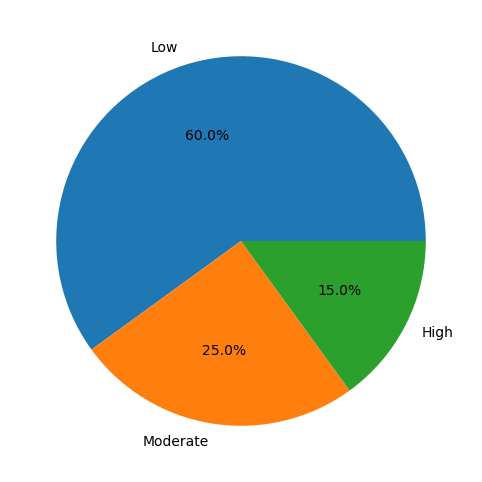

In [15]:
diabetes_risk_counts = df["diabetes_risk"].value_counts()

plt.figure(figsize=(12, 6)) 
plt.pie(diabetes_risk_counts, labels=diabetes_risk_counts.index, autopct='%1.1f%%')
plt.show()

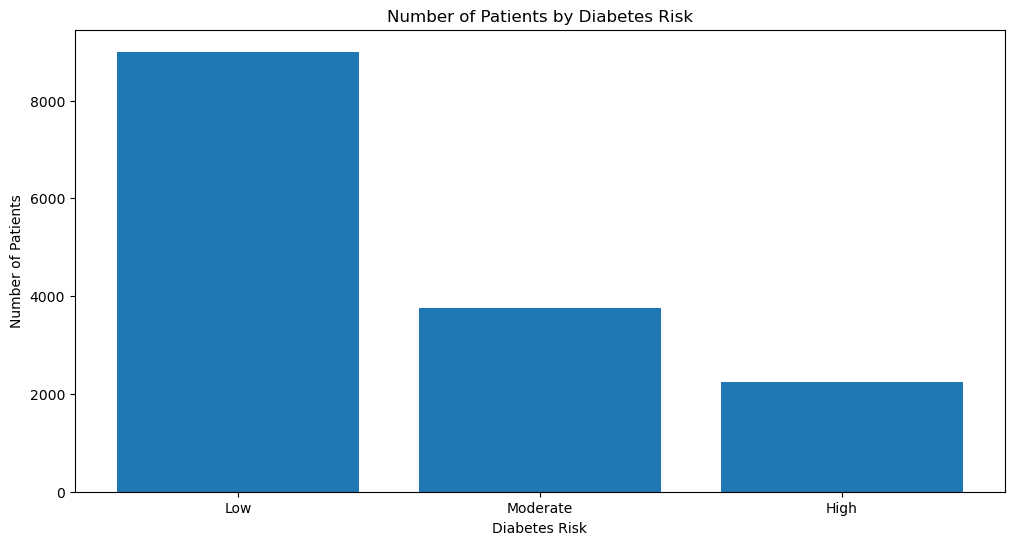

In [36]:
diabetes_risk_counts = df["diabetes_risk"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(diabetes_risk_counts.index, diabetes_risk_counts.values)
plt.title("Number of Patients by Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Number of Patients")
plt.show()

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

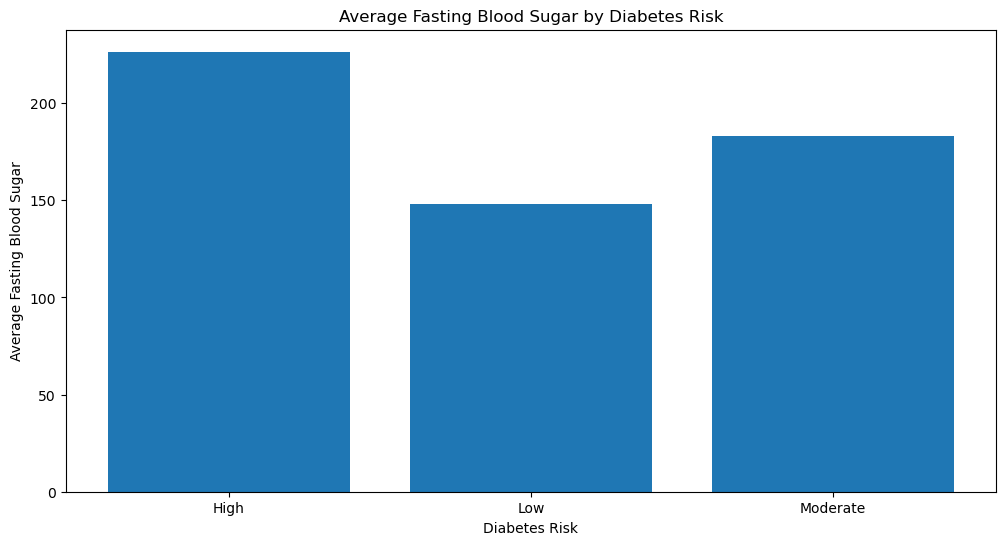

In [37]:
risk_fbs = df.groupby("diabetes_risk")["fasting_blood_sugar"].mean()

plt.figure(figsize=(12, 6))
plt.bar(risk_fbs.index, risk_fbs.values)
plt.title("Average Fasting Blood Sugar by Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Average Fasting Blood Sugar")
plt.show()

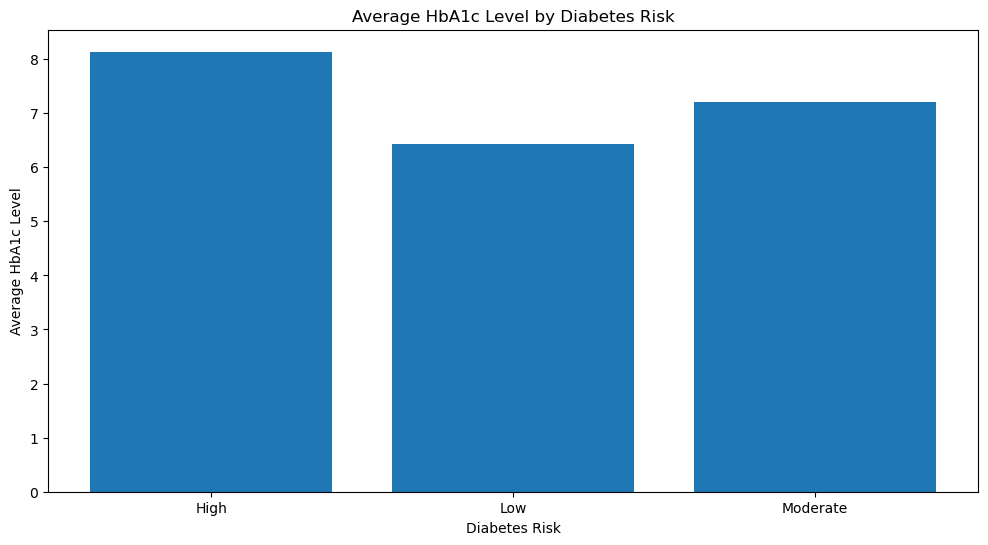

In [38]:
risk_hba1c = df.groupby("diabetes_risk")["hba1c_level"].mean()

plt.figure(figsize=(12, 6))
plt.bar(risk_hba1c.index, risk_hba1c.values)
plt.title("Average HbA1c Level by Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Average HbA1c Level")
plt.show()

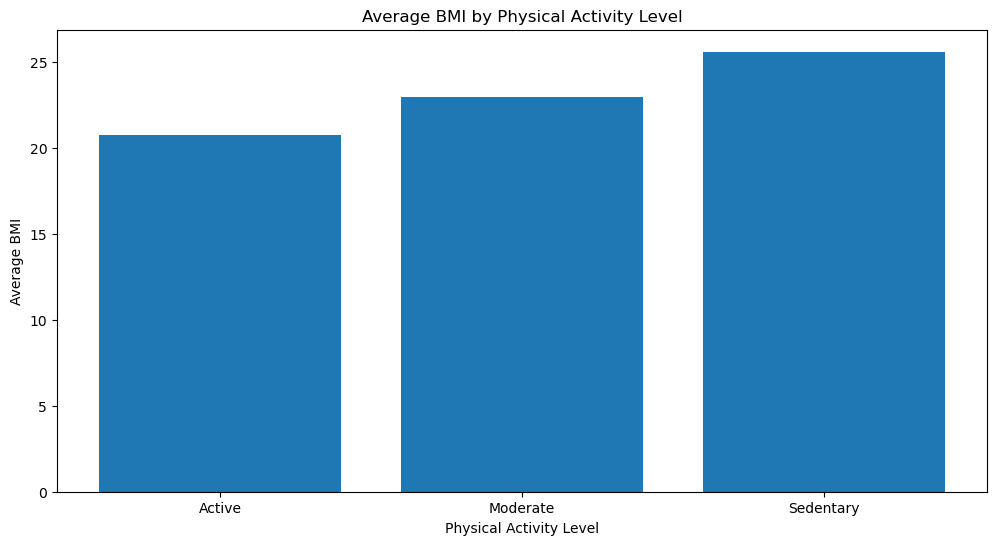

In [39]:
activity_bmi = df.groupby("physical_activity_level")["bmi"].mean()

plt.figure(figsize=(12, 6))
plt.bar(activity_bmi.index, activity_bmi.values)
plt.title("Average BMI by Physical Activity Level")
plt.xlabel("Physical Activity Level")
plt.ylabel("Average BMI")
plt.show()

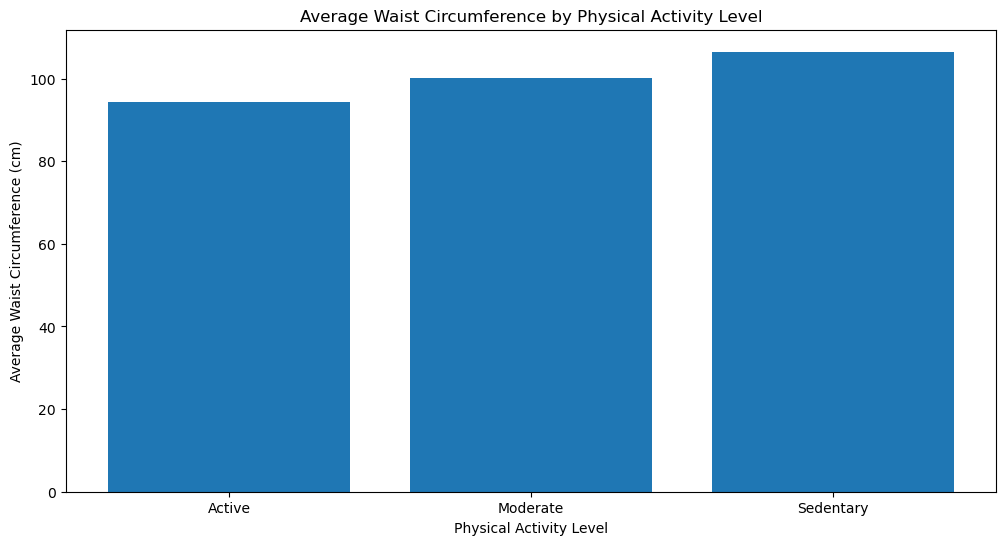

In [41]:
activity_waist = df.groupby("physical_activity_level")["waist_circumference_cm"].mean()

plt.figure(figsize=(12, 6))
plt.bar(activity_waist.index, activity_waist.values)
plt.title("Average Waist Circumference by Physical Activity Level")
plt.xlabel("Physical Activity Level")
plt.ylabel("Average Waist Circumference (cm)")
plt.show()

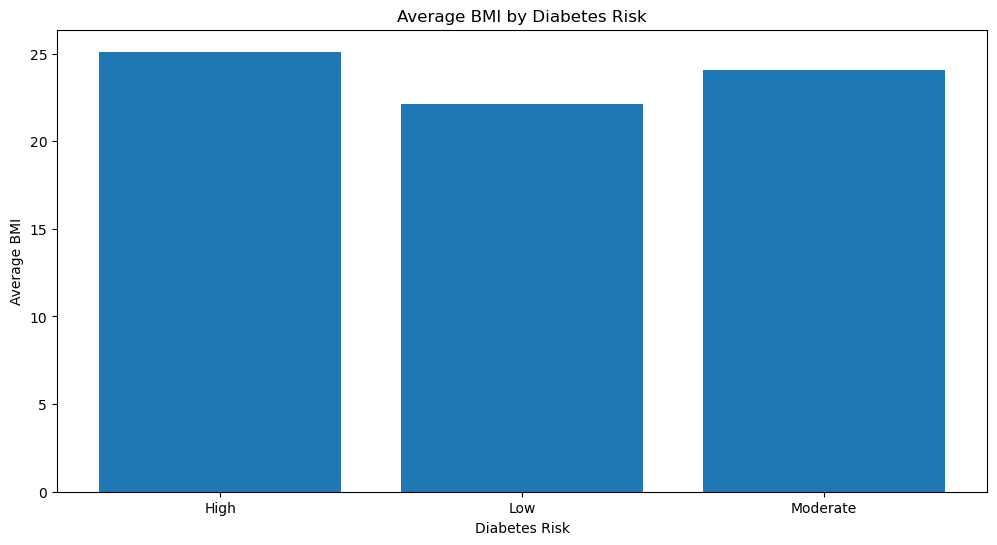

In [42]:
risk_bmi = df.groupby("diabetes_risk")["bmi"].mean()

plt.figure(figsize=(12, 6))
plt.bar(risk_bmi.index, risk_bmi.values)
plt.title("Average BMI by Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Average BMI")
plt.show()

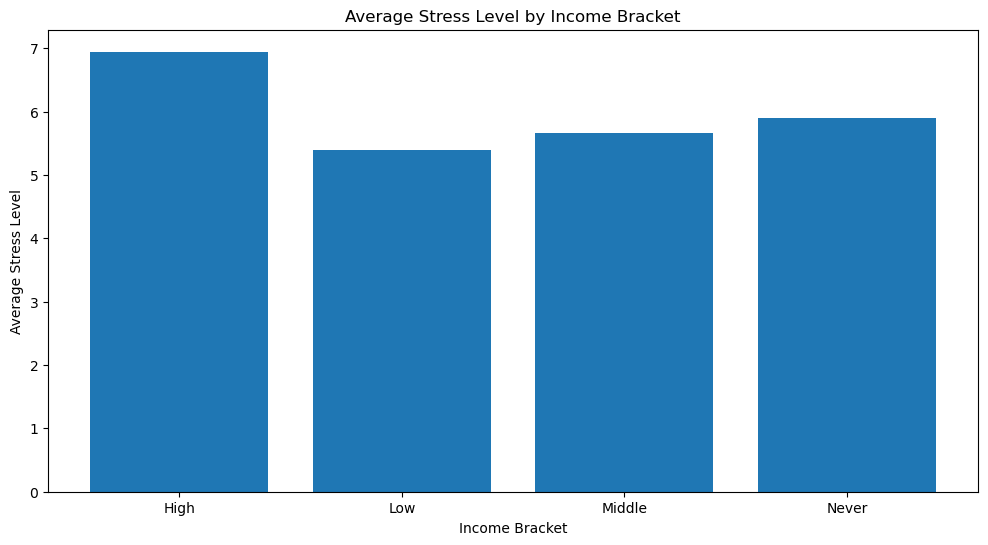

In [43]:
income_stress = df.groupby("income_bracket")["stress_level"].mean()

plt.figure(figsize=(12, 6))
plt.bar(income_stress.index, income_stress.values)
plt.title("Average Stress Level by Income Bracket")
plt.xlabel("Income Bracket")
plt.ylabel("Average Stress Level")
plt.show()

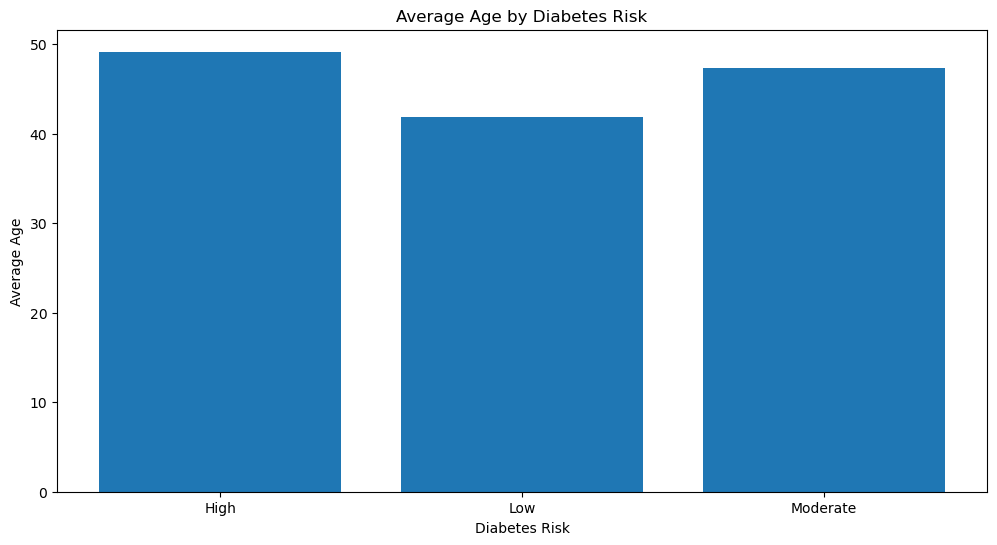

In [44]:
risk_age = df.groupby("diabetes_risk")["age"].mean()

plt.figure(figsize=(12, 6))
plt.bar(risk_age.index, risk_age.values)
plt.title("Average Age by Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Average Age")
plt.show()

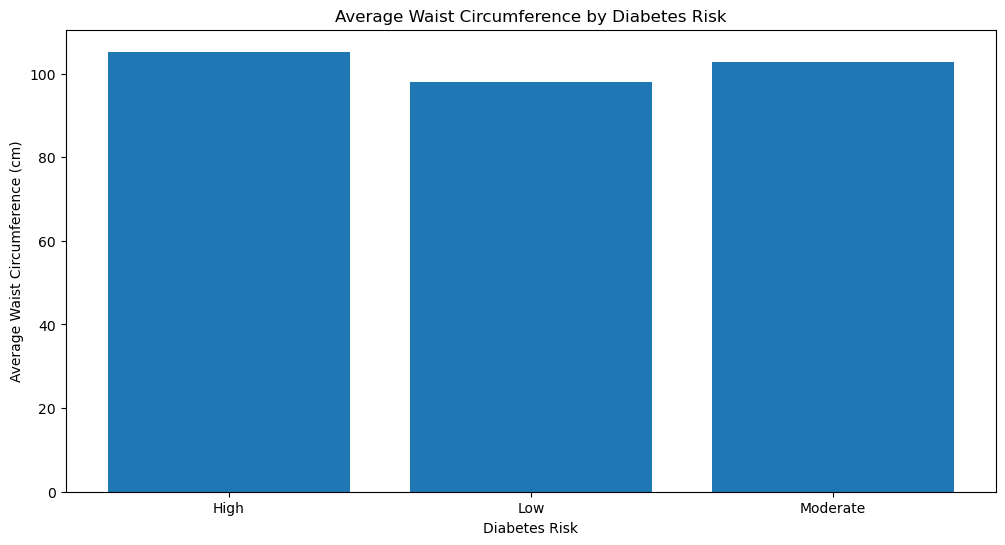

In [45]:
risk_waist = df.groupby("diabetes_risk")["waist_circumference_cm"].mean()

plt.figure(figsize=(12, 6))
plt.bar(risk_waist.index, risk_waist.values)
plt.title("Average Waist Circumference by Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Average Waist Circumference (cm)")
plt.show()

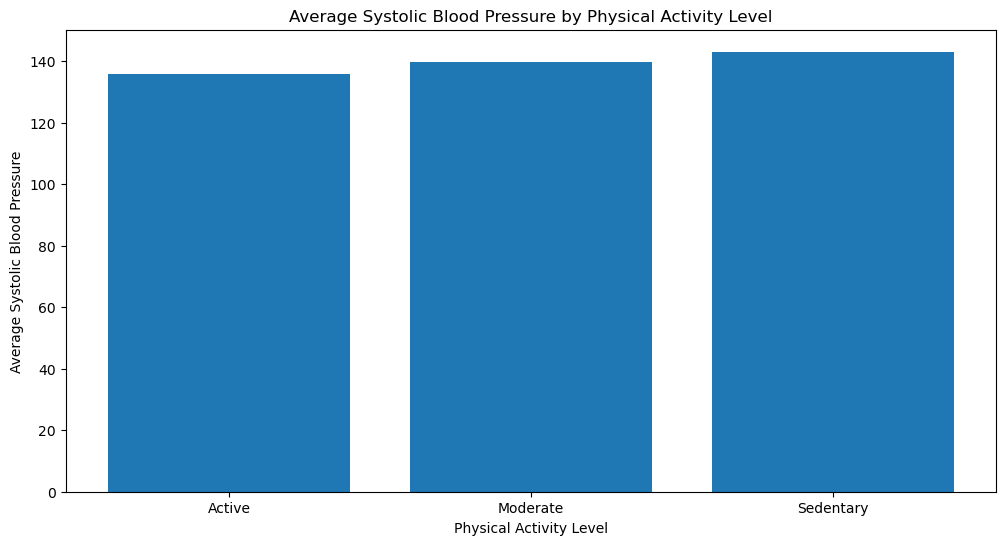

In [46]:
activity_bp = df.groupby("physical_activity_level")["blood_pressure_systolic"].mean()

plt.figure(figsize=(12, 6))
plt.bar(activity_bp.index, activity_bp.values)
plt.title("Average Systolic Blood Pressure by Physical Activity Level")
plt.xlabel("Physical Activity Level")
plt.ylabel("Average Systolic Blood Pressure")
plt.show()

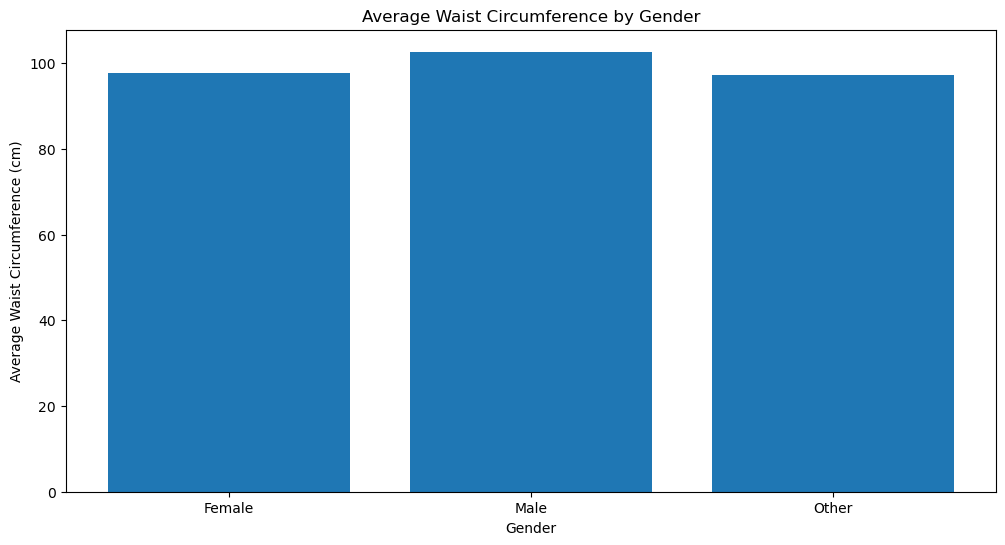

In [47]:
gender_waist = df.groupby("gender")["waist_circumference_cm"].mean()

plt.figure(figsize=(12, 6))
plt.bar(gender_waist.index, gender_waist.values)
plt.title("Average Waist Circumference by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Waist Circumference (cm)")
plt.show()

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

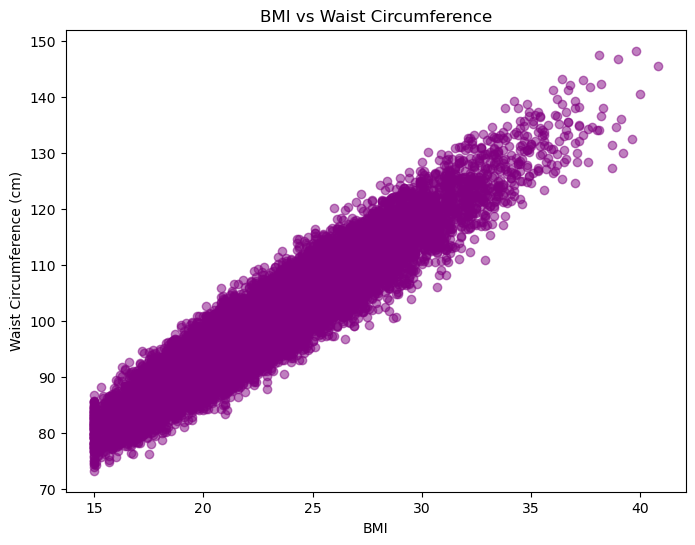

In [49]:
plt.figure(figsize=(8, 6))
plt.scatter(df["bmi"], df["waist_circumference_cm"], alpha=0.5, color="purple")
plt.title("BMI vs Waist Circumference")
plt.xlabel("BMI")
plt.ylabel("Waist Circumference (cm)")
plt.show()

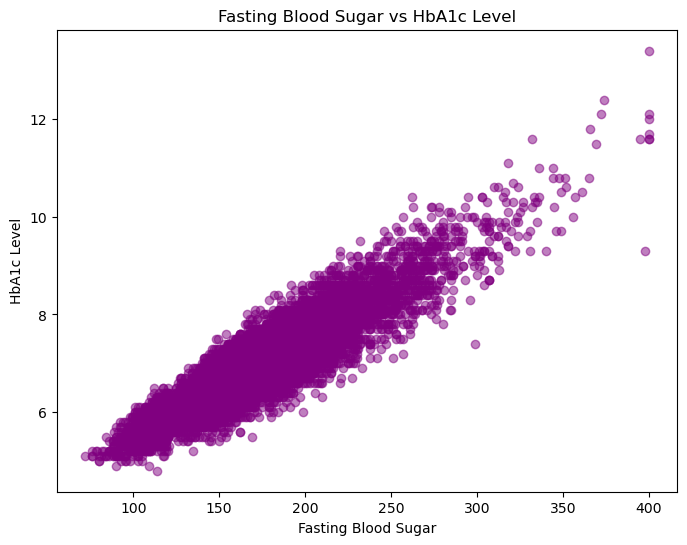

In [50]:
plt.figure(figsize=(8, 6))
plt.scatter(df["fasting_blood_sugar"], df["hba1c_level"], alpha=0.5, color="purple")
plt.title("Fasting Blood Sugar vs HbA1c Level")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("HbA1c Level")
plt.show()

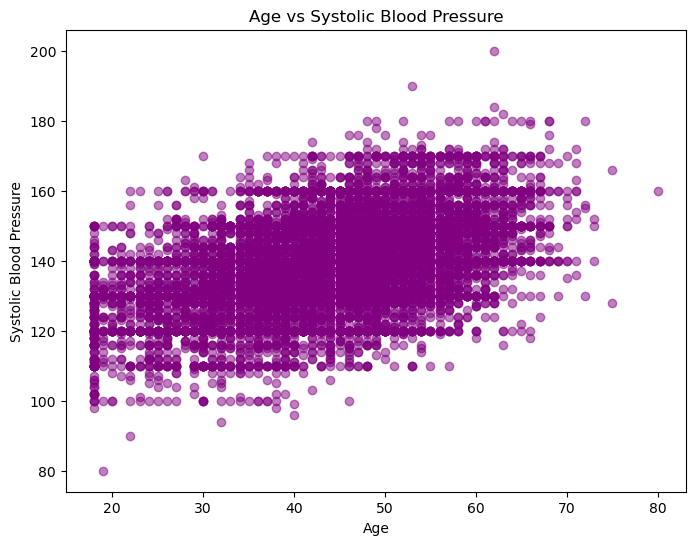

In [51]:
plt.figure(figsize=(8, 6))
plt.scatter(df["age"], df["blood_pressure_systolic"], alpha=0.5, color="purple")
plt.title("Age vs Systolic Blood Pressure")
plt.xlabel("Age")
plt.ylabel("Systolic Blood Pressure")
plt.show()

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

<Figure size 1000x600 with 0 Axes>

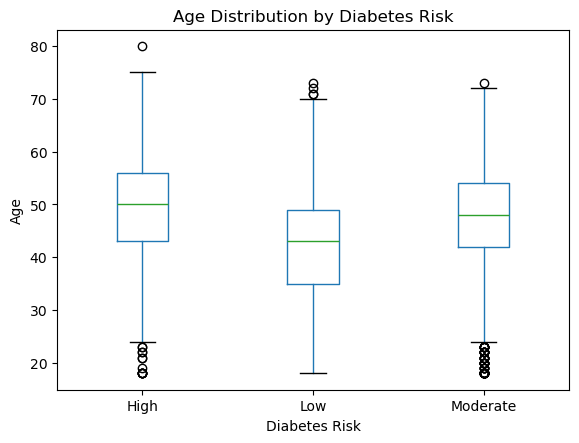

In [61]:
plt.figure(figsize=(10, 6))
df.boxplot(column="age", by="diabetes_risk", grid=False)
plt.title("Age Distribution by Diabetes Risk")
plt.suptitle("")
plt.xlabel("Diabetes Risk")
plt.ylabel("Age")
plt.show()

<Figure size 1000x600 with 0 Axes>

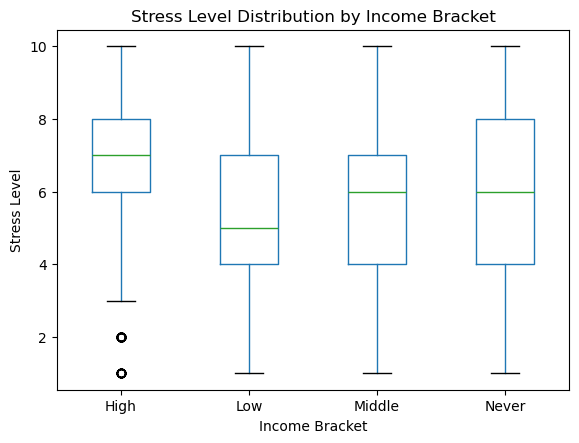

In [ ]:
plt.figure(figsize=(10, 6))
df.boxplot(column="stress_level", by="income_bracket", grid=False)
plt.title("Stress Level Distribution by Income Bracket")
plt.suptitle("")
plt.xlabel("Income Bracket")
plt.ylabel("Stress Level")
plt.show()

<Figure size 1000x600 with 0 Axes>

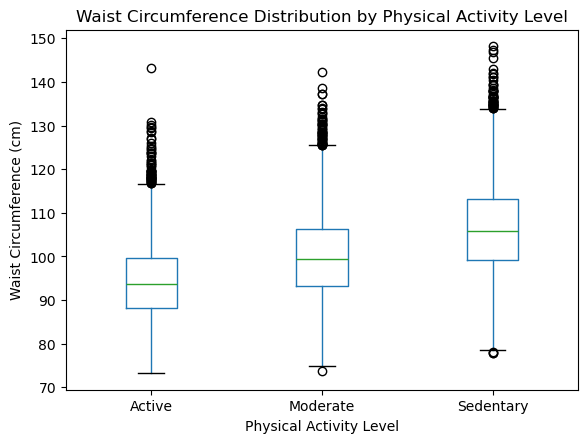

In [59]:
plt.figure(figsize=(10, 6))
df.boxplot(column="waist_circumference_cm", by="physical_activity_level", grid=False)
plt.title("Waist Circumference Distribution by Physical Activity Level")
plt.suptitle("")
plt.xlabel("Physical Activity Level")
plt.ylabel("Waist Circumference (cm)")
plt.show()

<Figure size 1000x600 with 0 Axes>

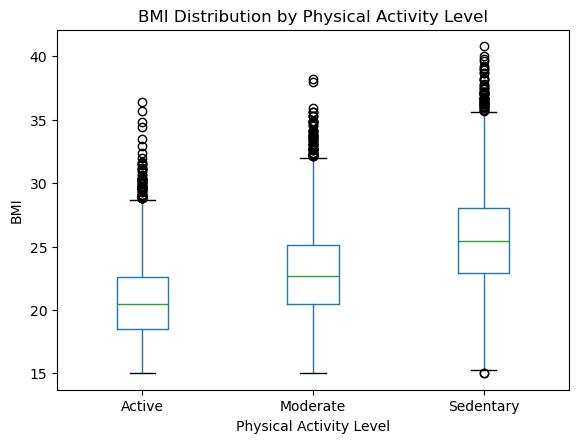

In [58]:
plt.figure(figsize=(10, 6))
df.boxplot(column="bmi", by="physical_activity_level", grid=False)
plt.title("BMI Distribution by Physical Activity Level")
plt.suptitle("")
plt.xlabel("Physical Activity Level")
plt.ylabel("BMI")
plt.show()

<Figure size 1000x600 with 0 Axes>

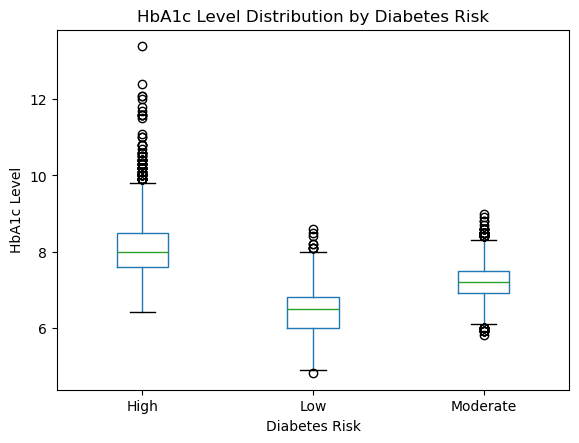

In [57]:
plt.figure(figsize=(10, 6))
df.boxplot(column="hba1c_level", by="diabetes_risk", grid=False)
plt.title("HbA1c Level Distribution by Diabetes Risk")
plt.suptitle("")
plt.xlabel("Diabetes Risk")
plt.ylabel("HbA1c Level")
plt.show()

<Figure size 1000x600 with 0 Axes>

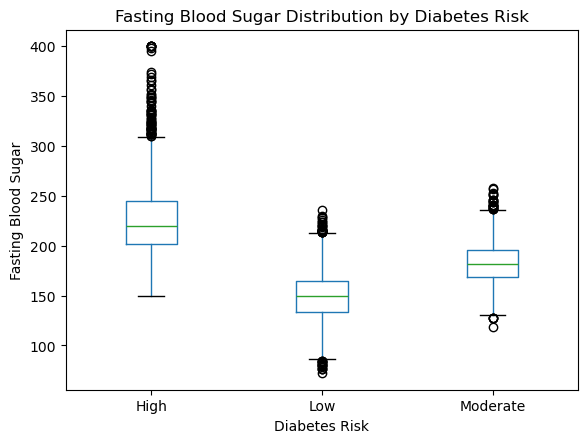

In [54]:
plt.figure(figsize=(10, 6))
df.boxplot(column="fasting_blood_sugar", by="diabetes_risk", grid=False)
plt.title("Fasting Blood Sugar Distribution by Diabetes Risk")
plt.suptitle("")
plt.xlabel("Diabetes Risk")
plt.ylabel("Fasting Blood Sugar")
plt.show()

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

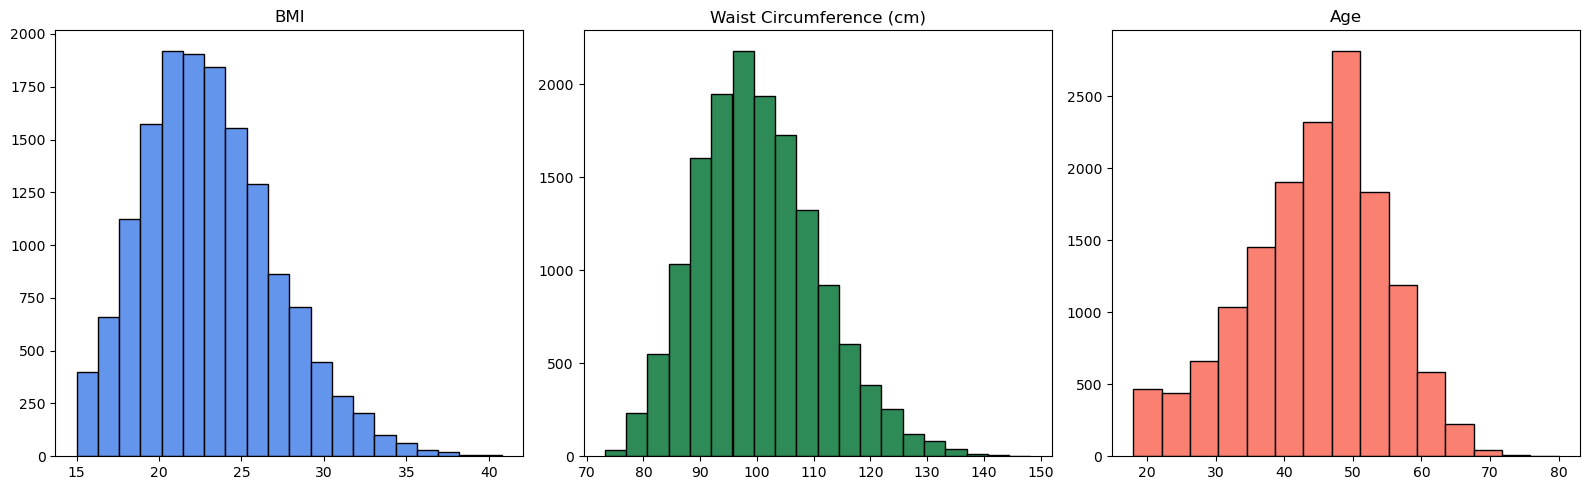

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df["bmi"], bins=20, color="cornflowerblue", edgecolor="black")
axes[0].set_title("BMI")

axes[1].hist(df["waist_circumference_cm"], bins=20, color="seagreen", edgecolor="black")
axes[1].set_title("Waist Circumference (cm)")

axes[2].hist(df["age"], bins=15, color="salmon", edgecolor="black")
axes[2].set_title("Age")

plt.tight_layout()
plt.show()

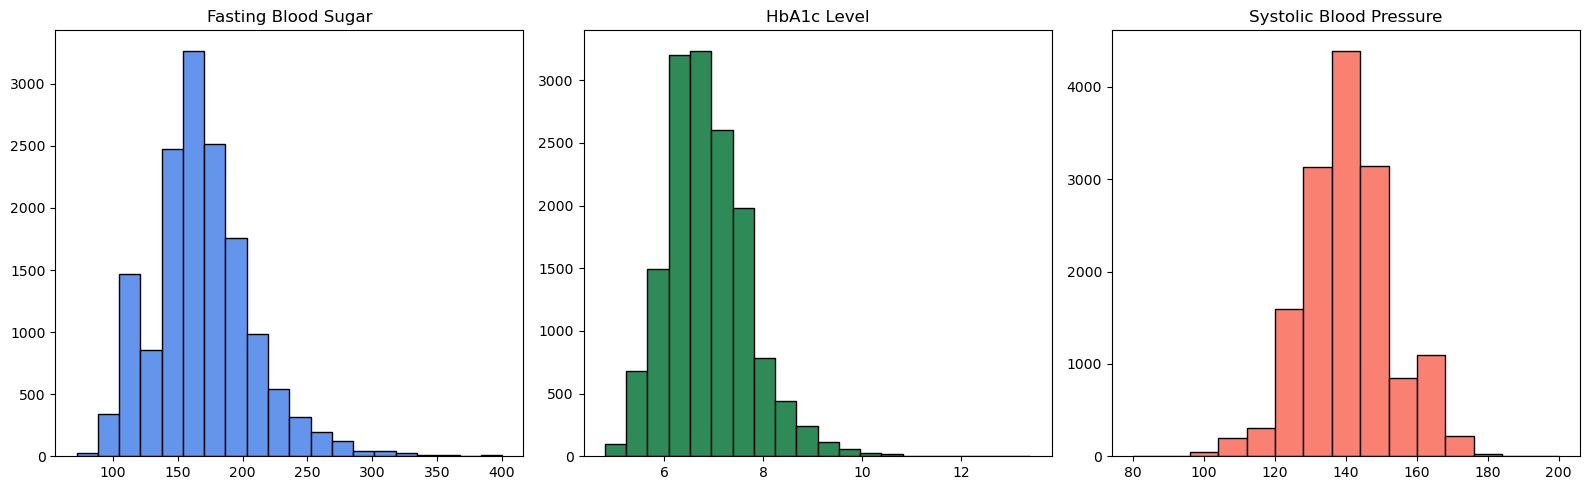

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df["fasting_blood_sugar"], bins=20, color="cornflowerblue", edgecolor="black")
axes[0].set_title("Fasting Blood Sugar")

axes[1].hist(df["hba1c_level"], bins=20, color="seagreen", edgecolor="black")
axes[1].set_title("HbA1c Level")

axes[2].hist(df["blood_pressure_systolic"], bins=15, color="salmon", edgecolor="black")
axes[2].set_title("Systolic Blood Pressure")

plt.tight_layout()
plt.show()

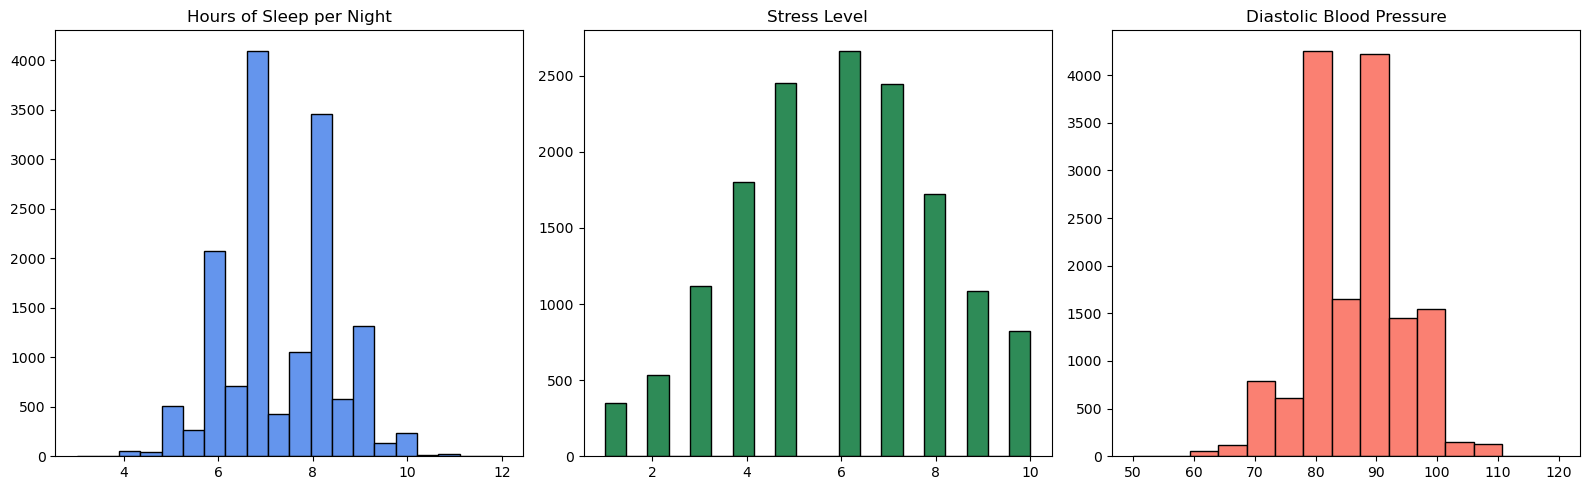

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df["hours_sleep_per_night"], bins=20, color="cornflowerblue", edgecolor="black")
axes[0].set_title("Hours of Sleep per Night")

axes[1].hist(df["stress_level"], bins=20, color="seagreen", edgecolor="black")
axes[1].set_title("Stress Level")

axes[2].hist(df["blood_pressure_diastolic"], bins=15, color="salmon", edgecolor="black")
axes[2].set_title("Diastolic Blood Pressure")

plt.tight_layout()
plt.show()

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

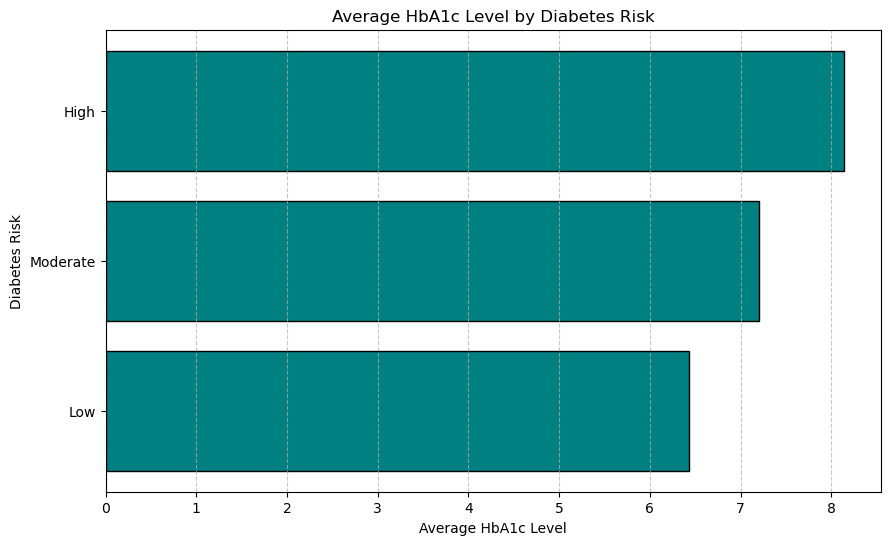

In [67]:
risk_hba1c = df.groupby("diabetes_risk")["hba1c_level"].mean().sort_values()

plt.figure(figsize=(10, 6))
plt.barh(risk_hba1c.index, risk_hba1c.values, color="teal", edgecolor="black")
plt.title("Average HbA1c Level by Diabetes Risk")
plt.xlabel("Average HbA1c Level")
plt.ylabel("Diabetes Risk")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

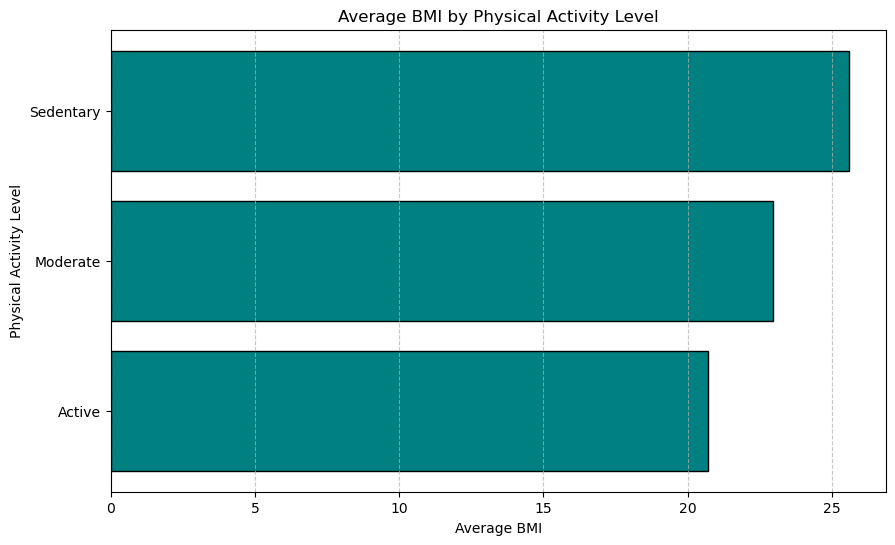

In [68]:
activity_bmi = df.groupby("physical_activity_level")["bmi"].mean().sort_values()

plt.figure(figsize=(10, 6))
plt.barh(activity_bmi.index, activity_bmi.values, color="teal", edgecolor="black")
plt.title("Average BMI by Physical Activity Level")
plt.xlabel("Average BMI")
plt.ylabel("Physical Activity Level")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

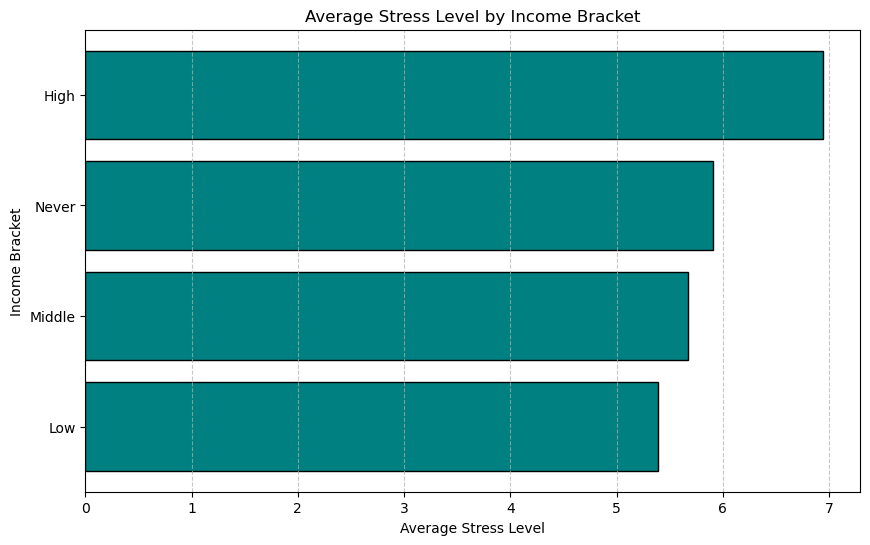

In [69]:
income_stress = df.groupby("income_bracket")["stress_level"].mean().sort_values()

plt.figure(figsize=(10, 6))
plt.barh(income_stress.index, income_stress.values, color="teal", edgecolor="black")
plt.title("Average Stress Level by Income Bracket")
plt.xlabel("Average Stress Level")
plt.ylabel("Income Bracket")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

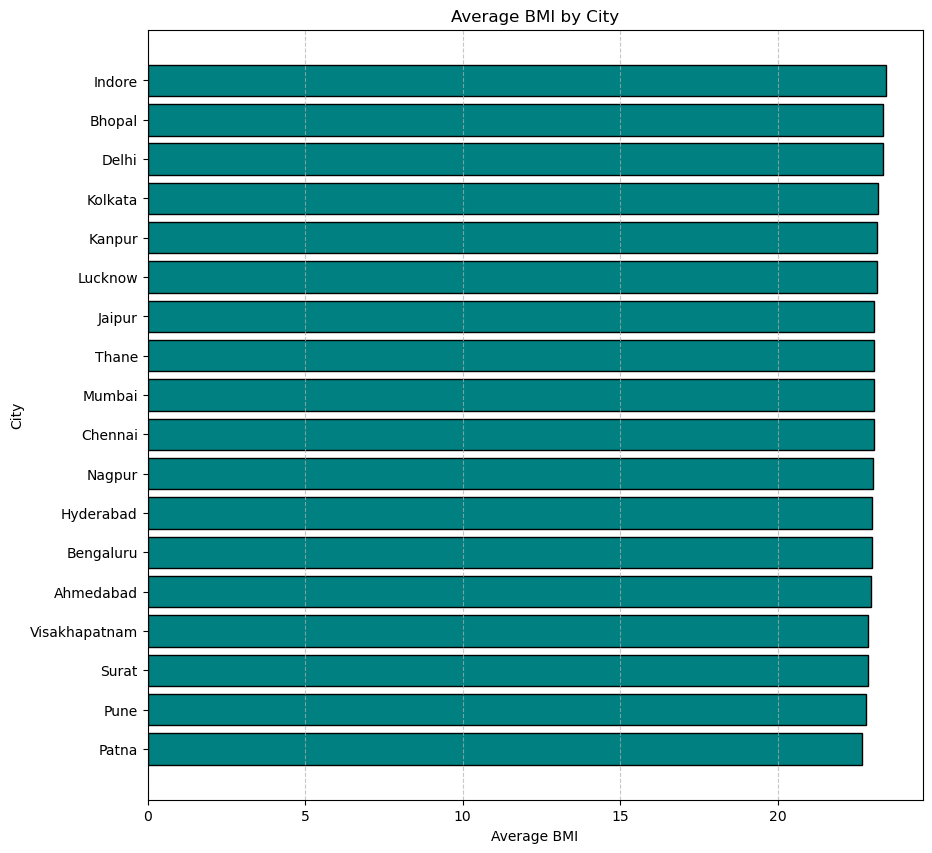

In [70]:
city_bmi = df.groupby("city")["bmi"].mean().sort_values()

plt.figure(figsize=(10, 10))
plt.barh(city_bmi.index, city_bmi.values, color="teal", edgecolor="black")
plt.title("Average BMI by City")
plt.xlabel("Average BMI")
plt.ylabel("City")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

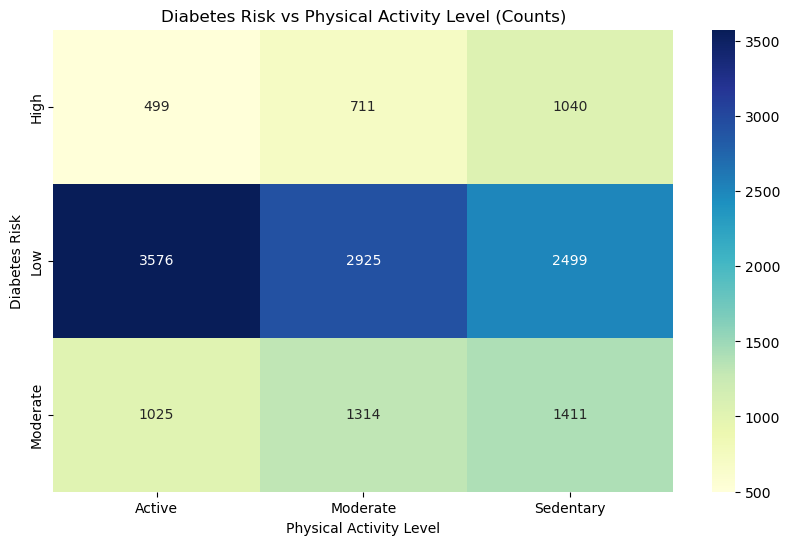

In [72]:
ct_risk_activity = pd.crosstab(df["diabetes_risk"], df["physical_activity_level"])

plt.figure(figsize=(10, 6))
sns.heatmap(ct_risk_activity, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Diabetes Risk vs Physical Activity Level (Counts)")
plt.ylabel("Diabetes Risk")
plt.xlabel("Physical Activity Level")
plt.show()

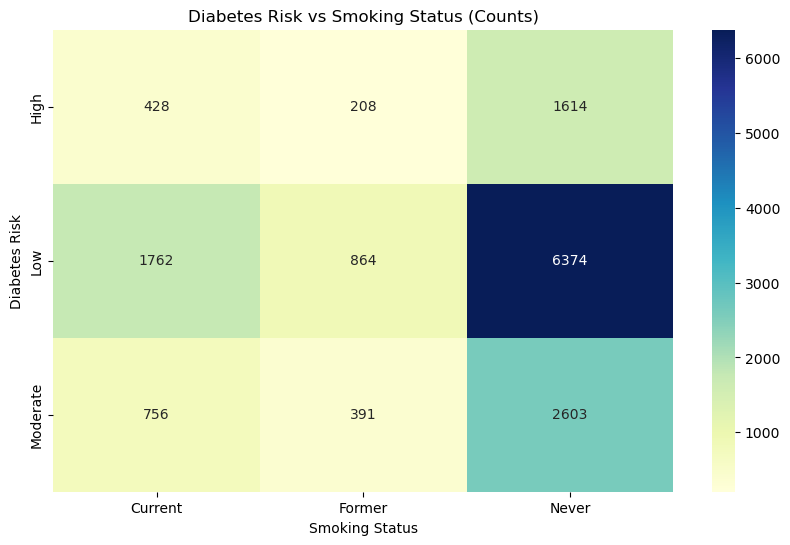

In [73]:
ct_risk_smoking = pd.crosstab(df["diabetes_risk"], df["smoking_status"])

plt.figure(figsize=(10, 6))
sns.heatmap(ct_risk_smoking, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Diabetes Risk vs Smoking Status (Counts)")
plt.ylabel("Diabetes Risk")
plt.xlabel("Smoking Status")
plt.show()

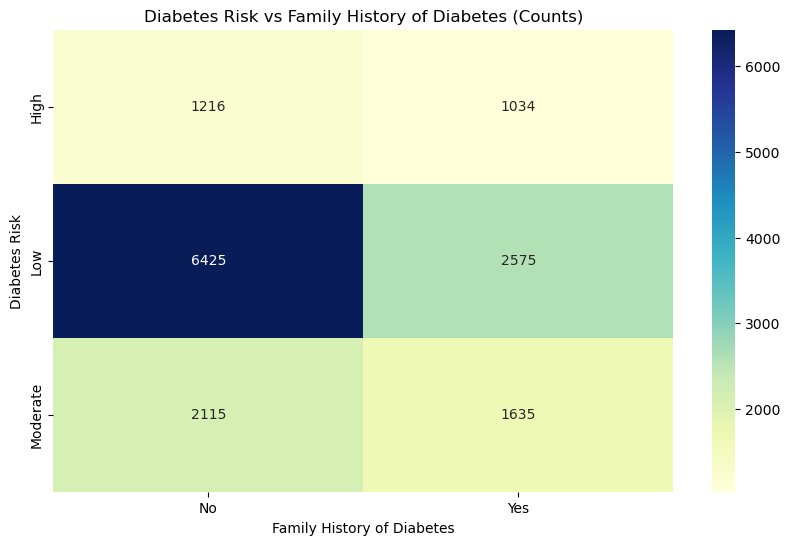

In [74]:
ct_risk_family = pd.crosstab(df["diabetes_risk"], df["family_history_diabetes"])

plt.figure(figsize=(10, 6))
sns.heatmap(ct_risk_family, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Diabetes Risk vs Family History of Diabetes (Counts)")
plt.ylabel("Diabetes Risk")
plt.xlabel("Family History of Diabetes")
plt.show()

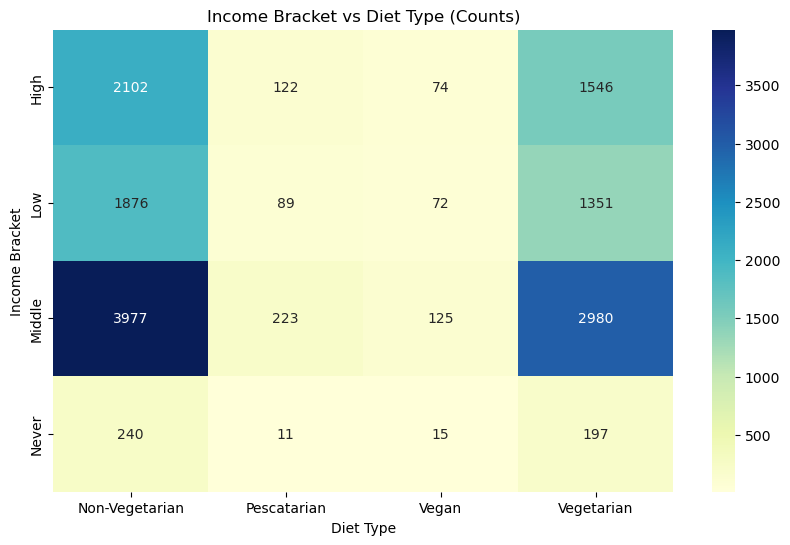

In [75]:
ct_income_diet = pd.crosstab(df["income_bracket"], df["diet_type"])

plt.figure(figsize=(10, 6))
sns.heatmap(ct_income_diet, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Income Bracket vs Diet Type (Counts)")
plt.ylabel("Income Bracket")
plt.xlabel("Diet Type")
plt.show()

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

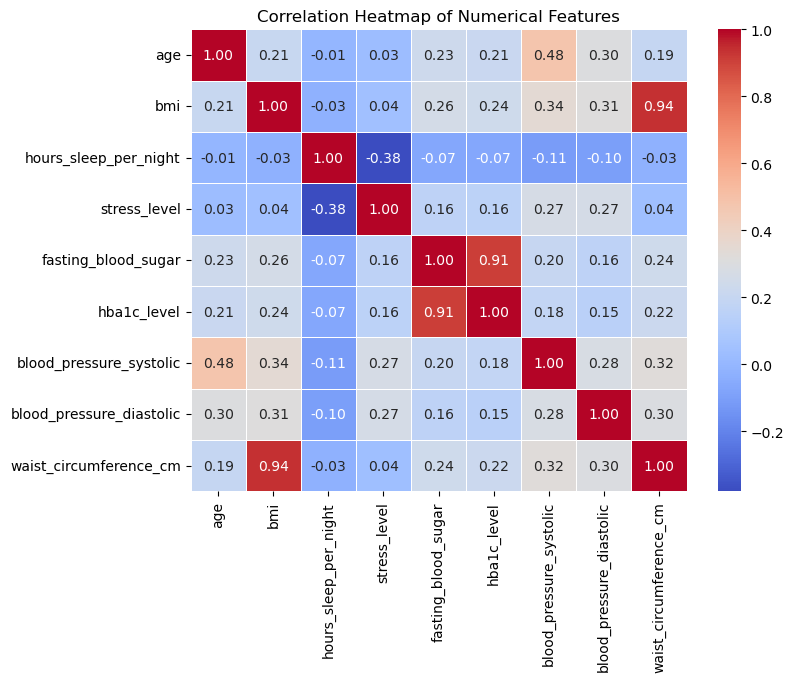

In [77]:
num_cols = ["age", "bmi", "hours_sleep_per_night", "stress_level",
            "fasting_blood_sugar", "hba1c_level","blood_pressure_systolic","blood_pressure_diastolic","waist_circumference_cm"]
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

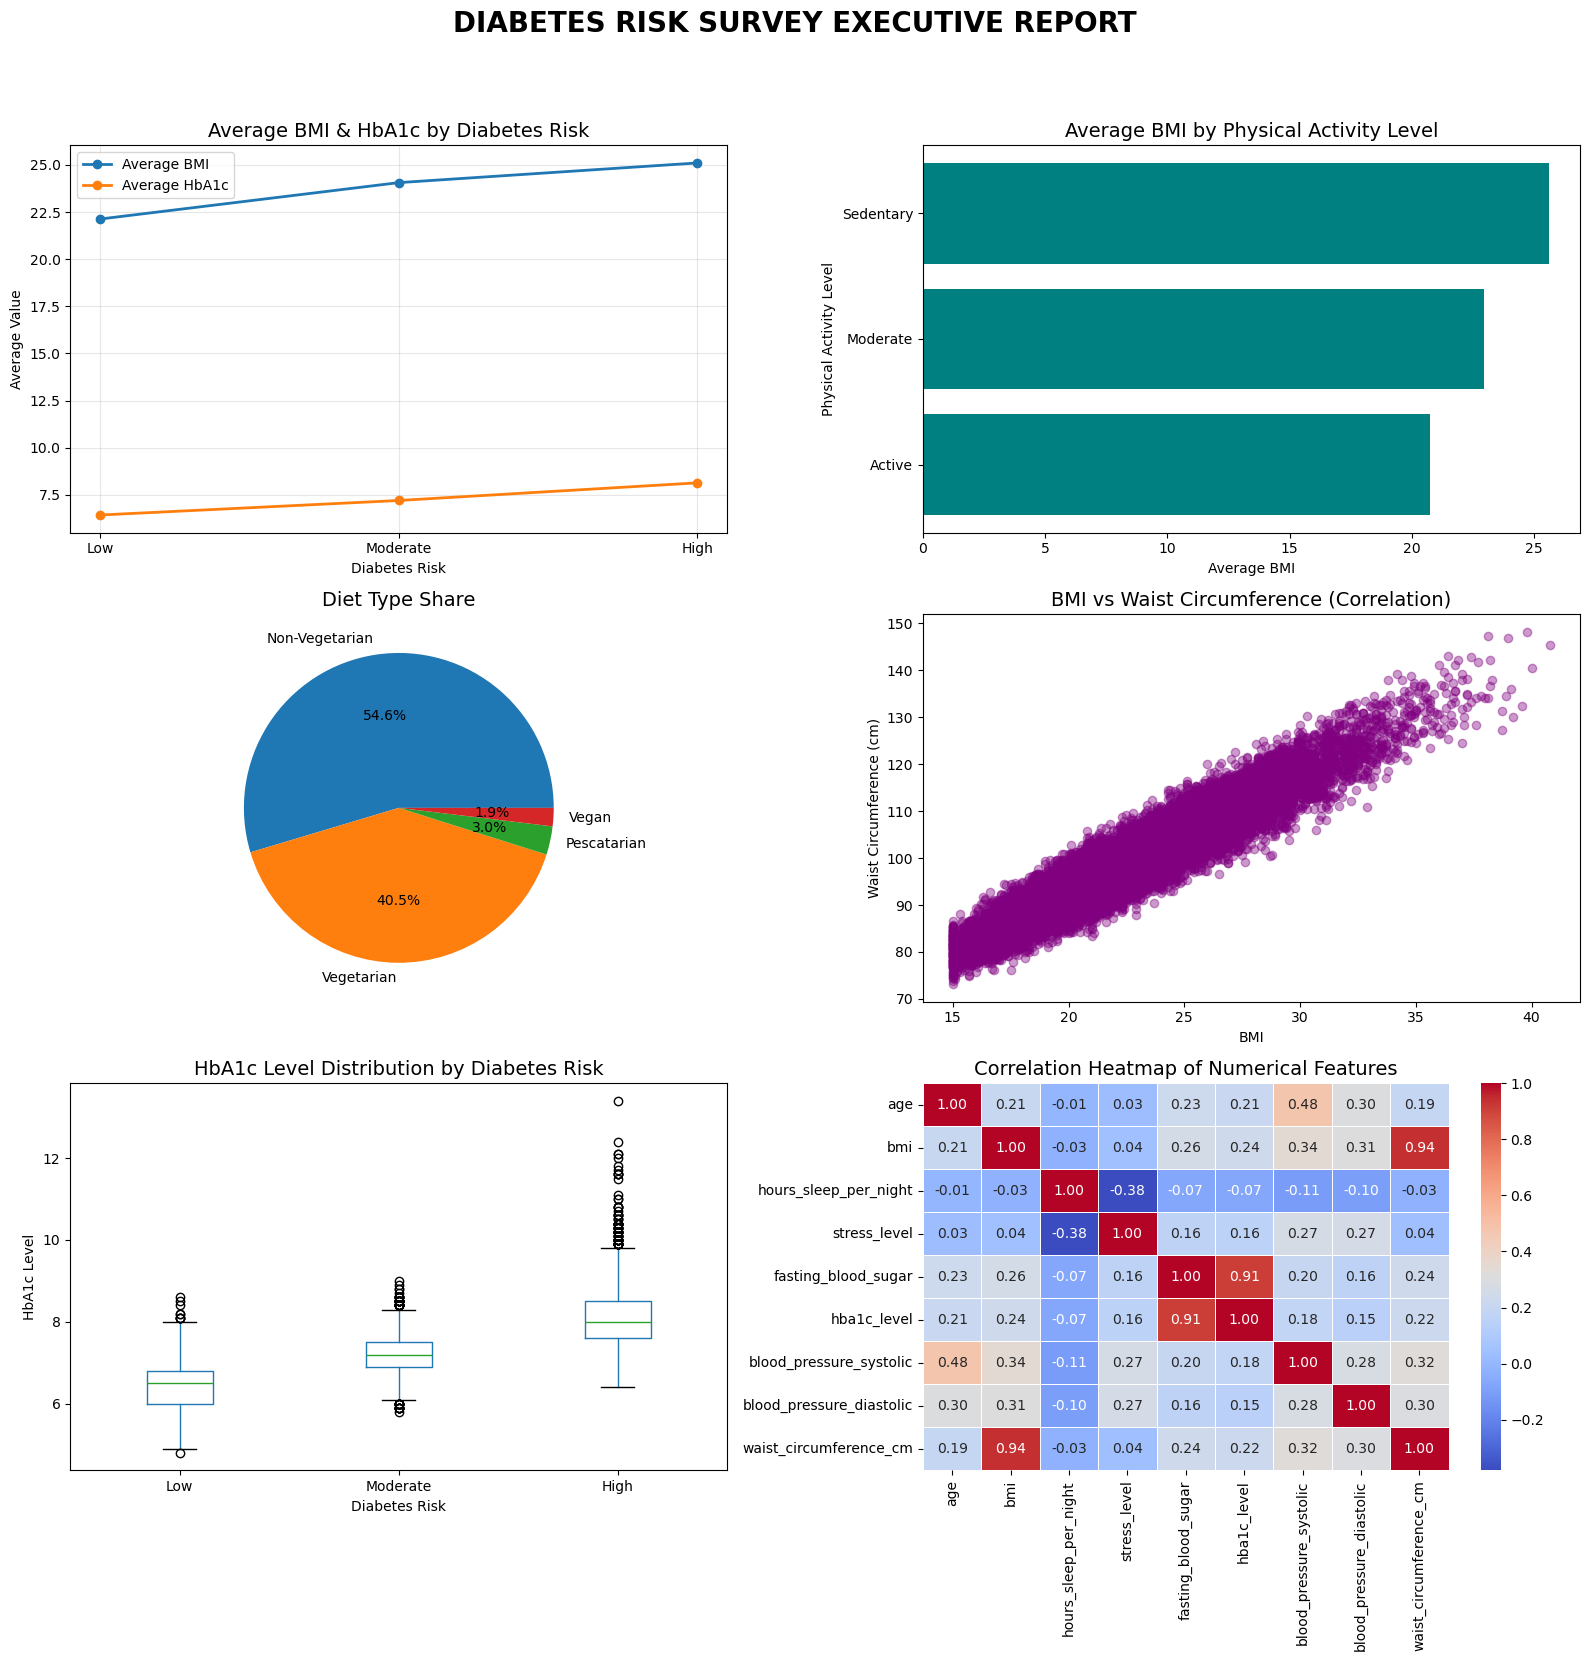

          DIABETES RISK ANALYSIS REPORT
REPORT SCOPE:       Patient Health Survey
TOTAL RECORDS:      15,000 Patients Analyzed
------------------------------------------------------------
1. DEMOGRAPHICS:    Average patient age is 44.3 years, with an
                    average BMI of 23.1.
2. HBA1C:           Average HbA1c level across all patients is 6.88.
3. WAIST:           Average waist circumference is 100.2 cm.
4. HIGHEST RISK:    'High' risk patients have the highest average
                    HbA1c level, at 8.14.
5. ACTIVITY:        'Active' patients have the lowest average BMI;
                    'Sedentary' patients have the highest.
6. RISK FACTORS:    35.0% have a family history of diabetes,
                    34.0% are physically active, and 70.6% have never smoked.
------------------------------------------------------------
DIET TYPE BREAKDOWN:
diet_type
Non-Vegetarian    8195
Vegetarian        6074
Pescatarian        445
Vegan              286
Name: count, dtype: i

In [81]:
# Order risk levels logically instead of alphabetically
risk_order = ["Low", "Moderate", "High"]
df["diabetes_risk"] = pd.Categorical(df["diabetes_risk"], categories=risk_order, ordered=True)
 
# ---------------------------------------------------------
# 1. DATA ANALYSIS CALCULATIONS
# ---------------------------------------------------------
total_patients = len(df)
avg_age = df["age"].mean()
avg_bmi = df["bmi"].mean()
avg_hba1c = df["hba1c_level"].mean()
avg_waist = df["waist_circumference_cm"].mean()
 
risk_avg = df.groupby("diabetes_risk", observed=True)[["bmi", "hba1c_level", "fasting_blood_sugar"]].mean()
highest_risk_group = risk_avg["hba1c_level"].idxmax()
highest_risk_hba1c = risk_avg["hba1c_level"].max()
 
activity_bmi = df.groupby("physical_activity_level")["bmi"].mean()
most_active_group = activity_bmi.idxmin()
least_active_group = activity_bmi.idxmax()
 
diet_counts = df["diet_type"].value_counts()
 
family_history_pct = (df["family_history_diabetes"] == "Yes").mean() * 100
active_pct = (df["physical_activity_level"] == "Active").mean() * 100
never_smoked_pct = (df["smoking_status"] == "Never").mean() * 100
 
num_cols = ["age", "bmi", "hours_sleep_per_night", "stress_level",
            "fasting_blood_sugar", "hba1c_level",
            "blood_pressure_systolic", "blood_pressure_diastolic",
            "waist_circumference_cm"]
corr_matrix = df[num_cols].corr()
bmi_waist_corr = df["bmi"].corr(df["waist_circumference_cm"])
 
# ---------------------------------------------------------
# 2. THE VISUAL REPORT (6-Chart Dashboard)
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
 
# --- CHART 1: Average BMI & HbA1c by Diabetes Risk ---
axes[0, 0].plot(risk_avg.index, risk_avg["bmi"], marker="o", linewidth=2, label="Average BMI")
axes[0, 0].plot(risk_avg.index, risk_avg["hba1c_level"], marker="o", linewidth=2, label="Average HbA1c")
axes[0, 0].set_title("Average BMI & HbA1c by Diabetes Risk", fontsize=14)
axes[0, 0].set_xlabel("Diabetes Risk")
axes[0, 0].set_ylabel("Average Value")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
 
# --- CHART 2: Average BMI by Physical Activity Level ---
activity_sorted = activity_bmi.sort_values()
axes[0, 1].barh(activity_sorted.index, activity_sorted.values, color="teal")
axes[0, 1].set_title("Average BMI by Physical Activity Level", fontsize=14)
axes[0, 1].set_xlabel("Average BMI")
axes[0, 1].set_ylabel("Physical Activity Level")
 
# --- CHART 3: Diet Type Distribution ---
axes[1, 0].pie(diet_counts, labels=diet_counts.index, autopct="%1.1f%%")
axes[1, 0].set_title("Diet Type Share", fontsize=14)
 
# --- CHART 4: BMI vs Waist Circumference (Correlation) ---
axes[1, 1].scatter(df["bmi"], df["waist_circumference_cm"], alpha=0.4, color="purple")
axes[1, 1].set_title("BMI vs Waist Circumference (Correlation)", fontsize=14)
axes[1, 1].set_xlabel("BMI")
axes[1, 1].set_ylabel("Waist Circumference (cm)")
 
# --- CHART 5: Boxplot of HbA1c Level by Diabetes Risk ---
df.boxplot(column="hba1c_level", by="diabetes_risk", grid=False, ax=axes[2, 0])
axes[2, 0].set_title("HbA1c Level Distribution by Diabetes Risk", fontsize=14)
axes[2, 0].set_ylabel("HbA1c Level")
axes[2, 0].set_xlabel("Diabetes Risk")
plt.suptitle("")  # clears pandas' auto "Boxplot grouped by..." title
 
# --- CHART 6: Correlation Heatmap ---
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, ax=axes[2, 1])
axes[2, 1].set_title("Correlation Heatmap of Numerical Features", fontsize=14)
 
# Set the report title LAST, after all plotting, so it's not overwritten
fig.suptitle("DIABETES RISK SURVEY EXECUTIVE REPORT", fontsize=20, fontweight="bold", y=0.95)
 
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()
 
# ---------------------------------------------------------
# 3. TEXT-BASED EXECUTIVE SUMMARY
# ---------------------------------------------------------
print("="*60)
print("          DIABETES RISK ANALYSIS REPORT")
print("="*60)
print(f"REPORT SCOPE:       Patient Health Survey")
print(f"TOTAL RECORDS:      {total_patients:,} Patients Analyzed")
print("-" * 60)
print(f"1. DEMOGRAPHICS:    Average patient age is {avg_age:.1f} years, with an")
print(f"                    average BMI of {avg_bmi:.1f}.")
print(f"2. HBA1C:           Average HbA1c level across all patients is {avg_hba1c:.2f}.")
print(f"3. WAIST:           Average waist circumference is {avg_waist:.1f} cm.")
print(f"4. HIGHEST RISK:    '{highest_risk_group}' risk patients have the highest average")
print(f"                    HbA1c level, at {highest_risk_hba1c:.2f}.")
print(f"5. ACTIVITY:        '{most_active_group}' patients have the lowest average BMI;")
print(f"                    '{least_active_group}' patients have the highest.")
print(f"6. RISK FACTORS:    {family_history_pct:.1f}% have a family history of diabetes,")
print(f"                    {active_pct:.1f}% are physically active, and {never_smoked_pct:.1f}% have never smoked.")
print("-" * 60)
print("DIET TYPE BREAKDOWN:")
print(diet_counts)
print("-" * 60)
print("CRITICAL INSIGHTS:")
print(f"- BMI and waist circumference have a correlation of {bmi_waist_corr:.2f}, confirming")
print(f"  these two body-size measures move together very closely, as expected.")
print(f"- HbA1c and fasting blood sugar rise sharply and consistently across risk groups,")
print(f"  which is expected since diabetes risk was very likely derived directly from")
print(f"  these two lab values rather than learned independently.")
print(f"- Physical activity level shows a real, substantial link to BMI, making it one")
print(f"  of the more genuinely informative lifestyle factors in this dataset.")
print(f"- Access to healthy lifestyle indicators (activity, non-smoking) does not fully")
print(f"  offset risk on its own, suggesting clinical markers remain the dominant signal.")
print("="*60)
 

## Machine Learning

In [3]:
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation metrics for Regression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Evaluation metrics for Classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("All tools are ready to use")

All tools are ready to use


In [4]:
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [64]:
df_encoded = df.copy()

encoder = LabelEncoder()

df_encoded["gender"] = encoder.fit_transform(df_encoded["gender"])
df_encoded["family_history_diabetes"] = encoder.fit_transform(df_encoded["family_history_diabetes"])
df_encoded["physical_activity_level"] = encoder.fit_transform(df_encoded["physical_activity_level"])
df_encoded["diet_type"] = encoder.fit_transform(df_encoded["diet_type"])
df_encoded["smoking_status"] = encoder.fit_transform(df_encoded["smoking_status"])
df_encoded["alcohol_consumption"] = encoder.fit_transform(df_encoded["alcohol_consumption"])
df_encoded["income_bracket"] = encoder.fit_transform(df_encoded["income_bracket"])
df_encoded["diabetes_risk"] = encoder.fit_transform(df_encoded["diabetes_risk"])


df_encoded.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,0,Mumbai,26.5,1,2,3,2,0,9.0,8,178,7.3,146,90,107.1,0,1
1,2,53,0,Mumbai,20.5,1,1,3,2,0,7.0,6,152,6.9,156,100,93.8,1,1
2,3,47,1,Thane,31.3,0,1,0,0,2,7.0,7,168,6.6,150,102,113.5,1,0
3,4,41,1,Bengaluru,22.8,0,2,0,2,0,9.0,5,155,6.7,126,92,109.6,2,1
4,5,57,0,Bengaluru,16.7,0,2,0,0,1,6.5,10,188,6.7,130,90,80.8,0,1


In [70]:

feature_columns = ["age", "gender", "bmi", "family_history_diabetes","physical_activity_level","diet_type",
                    "smoking_status", "alcohol_consumption", "hours_sleep_per_night",
                    "blood_pressure_systolic","blood_pressure_diastolic","waist_circumference_cm",
                    "income_bracket","stress_level"]

X = df_encoded[feature_columns]
y_risk = df_encoded["diabetes_risk"]    #Classification target

print("Shape of X:", X.shape)
print("Shape of y_risk:", y_risk.shape)

Shape of X: (15000, 14)
Shape of y_risk: (15000,)


In [71]:

X_train, X_test, y_risk_train, y_risk_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 12000
Testing rows: 3000


In [72]:
print(X.columns.tolist())
print(X.shape)

['age', 'gender', 'bmi', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'hours_sleep_per_night', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket', 'stress_level']
(15000, 14)


In [73]:
log_model = LogisticRegression(max_iter=500, random_state=42)
log_model.fit(X_train, y_risk_train)
log_pred = log_model.predict(X_test)
 
log_acc = accuracy_score(y_risk_test, log_pred)
log_precision = precision_score(y_risk_test, log_pred, average="weighted")
log_recall = recall_score(y_risk_test, log_pred, average="weighted")
log_f1 = f1_score(y_risk_test, log_pred, average="weighted")
 
print("\nLogistic Regression Results")
print("Accuracy:", round(log_acc, 3))
print("Precision:", round(log_precision, 3))
print("Recall:", round(log_recall, 3))
print("F1 Score:", round(log_f1, 3))


Logistic Regression Results
Accuracy: 0.621
Precision: 0.565
Recall: 0.621
F1 Score: 0.546


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


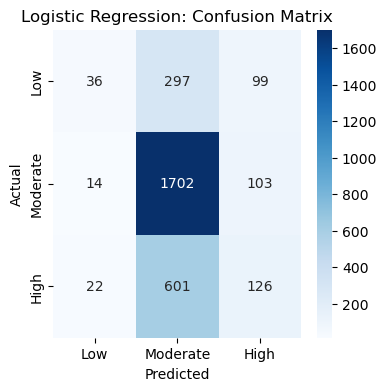

In [74]:
log_cm = confusion_matrix(y_risk_test, log_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(log_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Moderate", "High"], yticklabels=["Low","Moderate", "High"])
plt.title("Logistic Regression: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [76]:
# DECISION TREE CLASSIFIER

tree_clf_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf_model.fit(X_train, y_risk_train)
tree_clf_pred = tree_clf_model.predict(X_test)
 
tree_clf_acc = accuracy_score(y_risk_test, tree_clf_pred)
tree_clf_precision = precision_score(y_risk_test, tree_clf_pred, average="weighted")
tree_clf_recall = recall_score(y_risk_test, tree_clf_pred, average="weighted")
tree_clf_f1 = f1_score(y_risk_test, tree_clf_pred, average="weighted")
 
print("\nDecision Tree Classifier Results")
print("Accuracy:", round(tree_clf_acc, 3))
print("Precision:", round(tree_clf_precision, 3))
print("Recall:", round(tree_clf_recall, 3))
print("F1 Score:", round(tree_clf_f1, 3))


Decision Tree Classifier Results
Accuracy: 0.613
Precision: 0.532
Recall: 0.613
F1 Score: 0.525


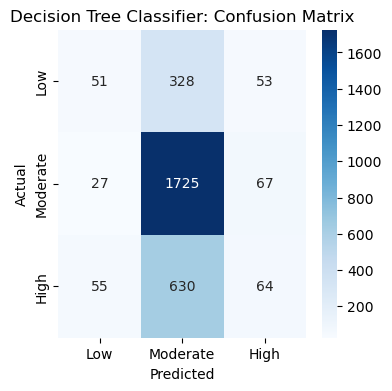

In [78]:
tree_clf_cm = confusion_matrix(y_risk_test, tree_clf_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(tree_clf_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Moderate", "High"], yticklabels=["Low","Moderate", "High"])
plt.title("Decision Tree Classifier: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



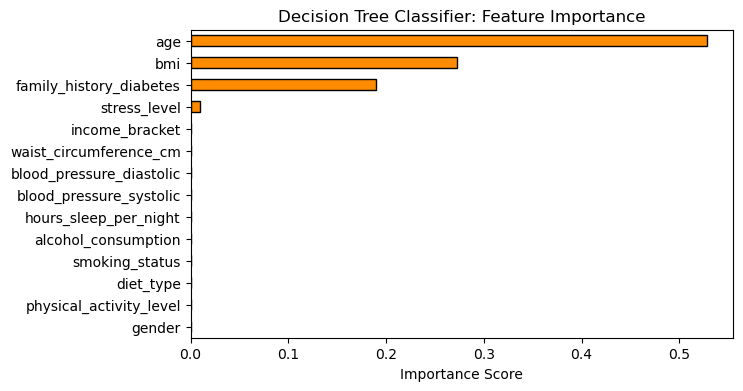

In [79]:
tree_clf_importance = pd.Series(tree_clf_model.feature_importances_, index=feature_columns)
tree_clf_importance = tree_clf_importance.sort_values(ascending=True)

plt.figure(figsize=(7, 4))
tree_clf_importance.plot(kind="barh", color="darkorange", edgecolor="black")
plt.title("Decision Tree Classifier: Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [82]:
# RANDOM FOREST CLASSIFIER

forest_clf_model = RandomForestClassifier(random_state=42)
forest_clf_model.fit(X_train, y_risk_train)
forest_clf_pred = forest_clf_model.predict(X_test)
 
forest_clf_acc = accuracy_score(y_risk_test, forest_clf_pred)
forest_clf_precision = precision_score(y_risk_test, forest_clf_pred, average="weighted")
forest_clf_recall = recall_score(y_risk_test, forest_clf_pred, average="weighted")
forest_clf_f1 = f1_score(y_risk_test, forest_clf_pred, average="weighted")
 
print("\nRandom Forest Classifier Results")
print("Accuracy:", round(forest_clf_acc, 3))
print("Precision:", round(forest_clf_precision, 3))
print("Recall:", round(forest_clf_recall, 3))
print("F1 Score:", round(forest_clf_f1, 3))



Random Forest Classifier Results
Accuracy: 0.623
Precision: 0.562
Recall: 0.623
F1 Score: 0.557


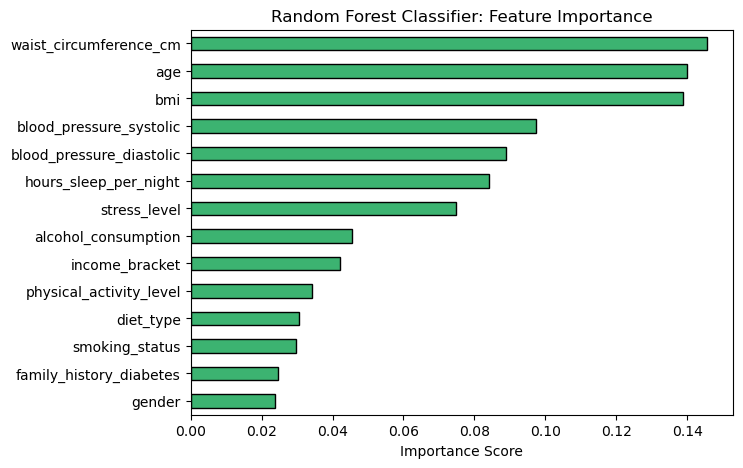

In [83]:
forest_clf_importance = pd.Series(forest_clf_model.feature_importances_, index=feature_columns)
forest_clf_importance = forest_clf_importance.sort_values(ascending=True)
 
plt.figure(figsize=(7, 5))
forest_clf_importance.plot(kind="barh", color="mediumseagreen", edgecolor="black")
plt.title("Random Forest Classifier: Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [85]:
# KNN CLASSIFIER
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_risk_train)
knn_pred = knn_model.predict(X_test)
 
knn_acc = accuracy_score(y_risk_test, knn_pred)
knn_precision = precision_score(y_risk_test, knn_pred, average="weighted")
knn_recall = recall_score(y_risk_test, knn_pred, average="weighted")
knn_f1 = f1_score(y_risk_test, knn_pred, average="weighted")
 
print("\nKNN Results")
print("Accuracy:", round(knn_acc, 3))
print("Precision:", round(knn_precision, 3))
print("Recall:", round(knn_recall, 3))
print("F1 Score:", round(knn_f1, 3))



KNN Results
Accuracy: 0.568
Precision: 0.52
Recall: 0.568
F1 Score: 0.532


In [86]:
# SVM CLASSIFIER
svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train, y_risk_train)
svm_pred = svm_model.predict(X_test)
 
svm_acc = accuracy_score(y_risk_test, svm_pred)
svm_precision = precision_score(y_risk_test, svm_pred, average="weighted")
svm_recall = recall_score(y_risk_test, svm_pred, average="weighted")
svm_f1 = f1_score(y_risk_test, svm_pred, average="weighted")
 
print("\nSVM Results")
print("Accuracy:", round(svm_acc, 3))
print("Precision:", round(svm_precision, 3))
print("Recall:", round(svm_recall, 3))
print("F1 Score:", round(svm_f1, 3))



SVM Results
Accuracy: 0.606
Precision: 0.368
Recall: 0.606
F1 Score: 0.458


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [87]:
# XGBOOST CLASSIFIER

xgb_clf_model = XGBClassifier(n_estimators=100, random_state=42, verbosity=0, eval_metric="mlogloss")
xgb_clf_model.fit(X_train, y_risk_train)
xgb_clf_pred = xgb_clf_model.predict(X_test)
 
xgb_clf_acc = accuracy_score(y_risk_test, xgb_clf_pred)
xgb_clf_precision = precision_score(y_risk_test, xgb_clf_pred, average="weighted")
xgb_clf_recall = recall_score(y_risk_test, xgb_clf_pred, average="weighted")
xgb_clf_f1 = f1_score(y_risk_test, xgb_clf_pred, average="weighted")
 
print("\nXGBoost Classifier Results")
print("Accuracy:", round(xgb_clf_acc, 3))
print("Precision:", round(xgb_clf_precision, 3))
print("Recall:", round(xgb_clf_recall, 3))
print("F1 Score:", round(xgb_clf_f1, 3))


XGBoost Classifier Results
Accuracy: 0.6
Precision: 0.535
Recall: 0.6
F1 Score: 0.548


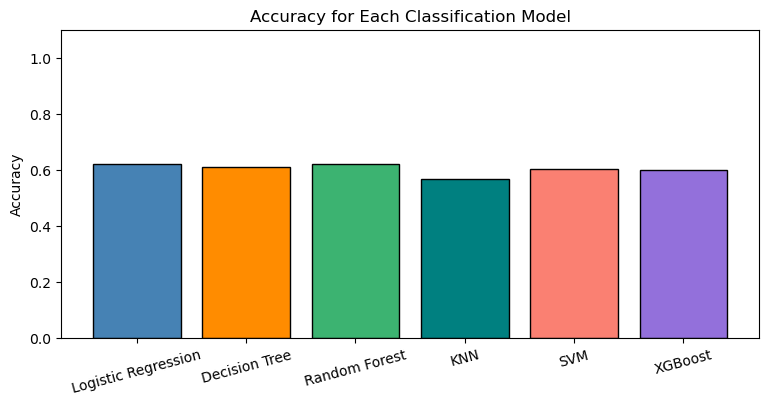


Accuracy Scores:
Logistic Regression: 0.621
Decision Tree: 0.613
Random Forest: 0.623
KNN: 0.568
SVM: 0.606
XGBoost: 0.6

All models ran successfully.


In [88]:
# COMPARE ALL MODELS

clf_model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "KNN", "SVM", "XGBoost"]
clf_accuracies = [log_acc, tree_clf_acc, forest_clf_acc, knn_acc, svm_acc, xgb_clf_acc]
clf_colors = ["steelblue", "darkorange", "mediumseagreen", "teal", "salmon", "mediumpurple"]
 
plt.figure(figsize=(9, 4))
plt.bar(clf_model_names, clf_accuracies, color=clf_colors, edgecolor="black")
plt.title("Accuracy for Each Classification Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.show()
 
print("\nAccuracy Scores:")
print("Logistic Regression:", round(log_acc, 3))
print("Decision Tree:", round(tree_clf_acc, 3))
print("Random Forest:", round(forest_clf_acc, 3))
print("KNN:", round(knn_acc, 3))
print("SVM:", round(svm_acc, 3))
print("XGBoost:", round(xgb_clf_acc, 3))
 
print("\nAll models ran successfully.")